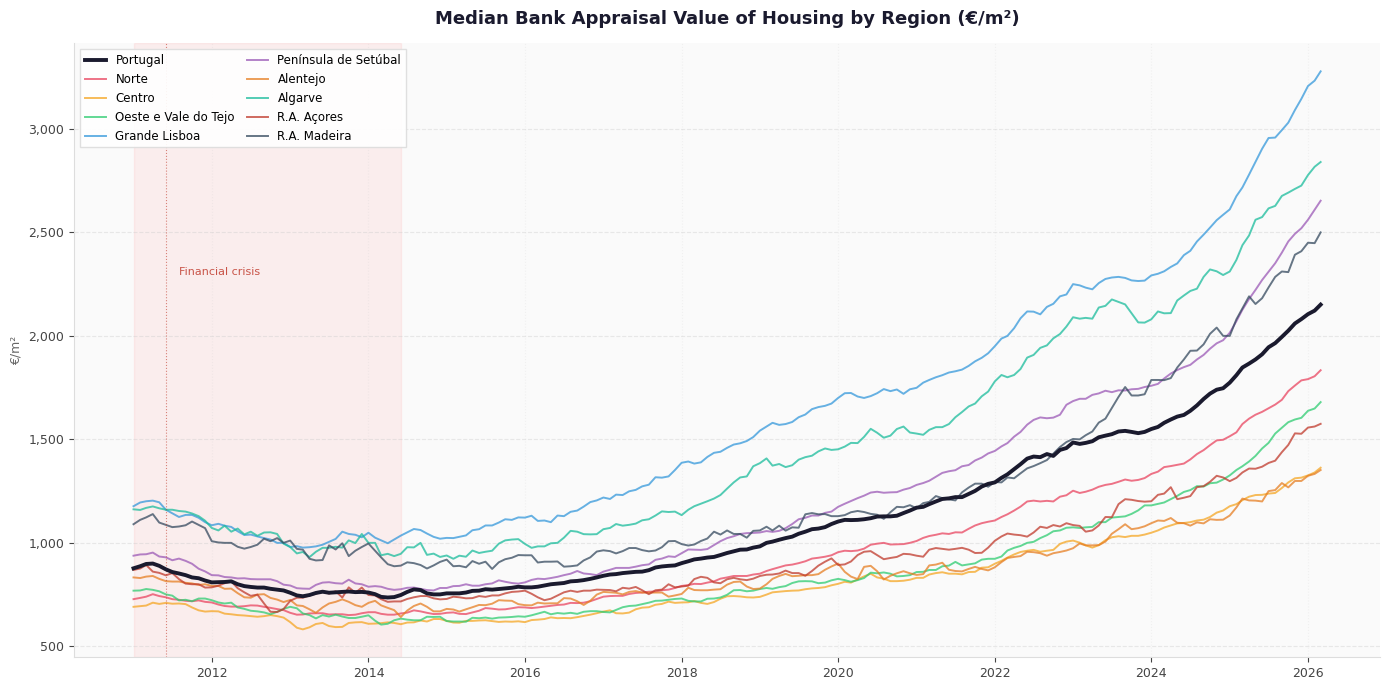

Chart 1 saved


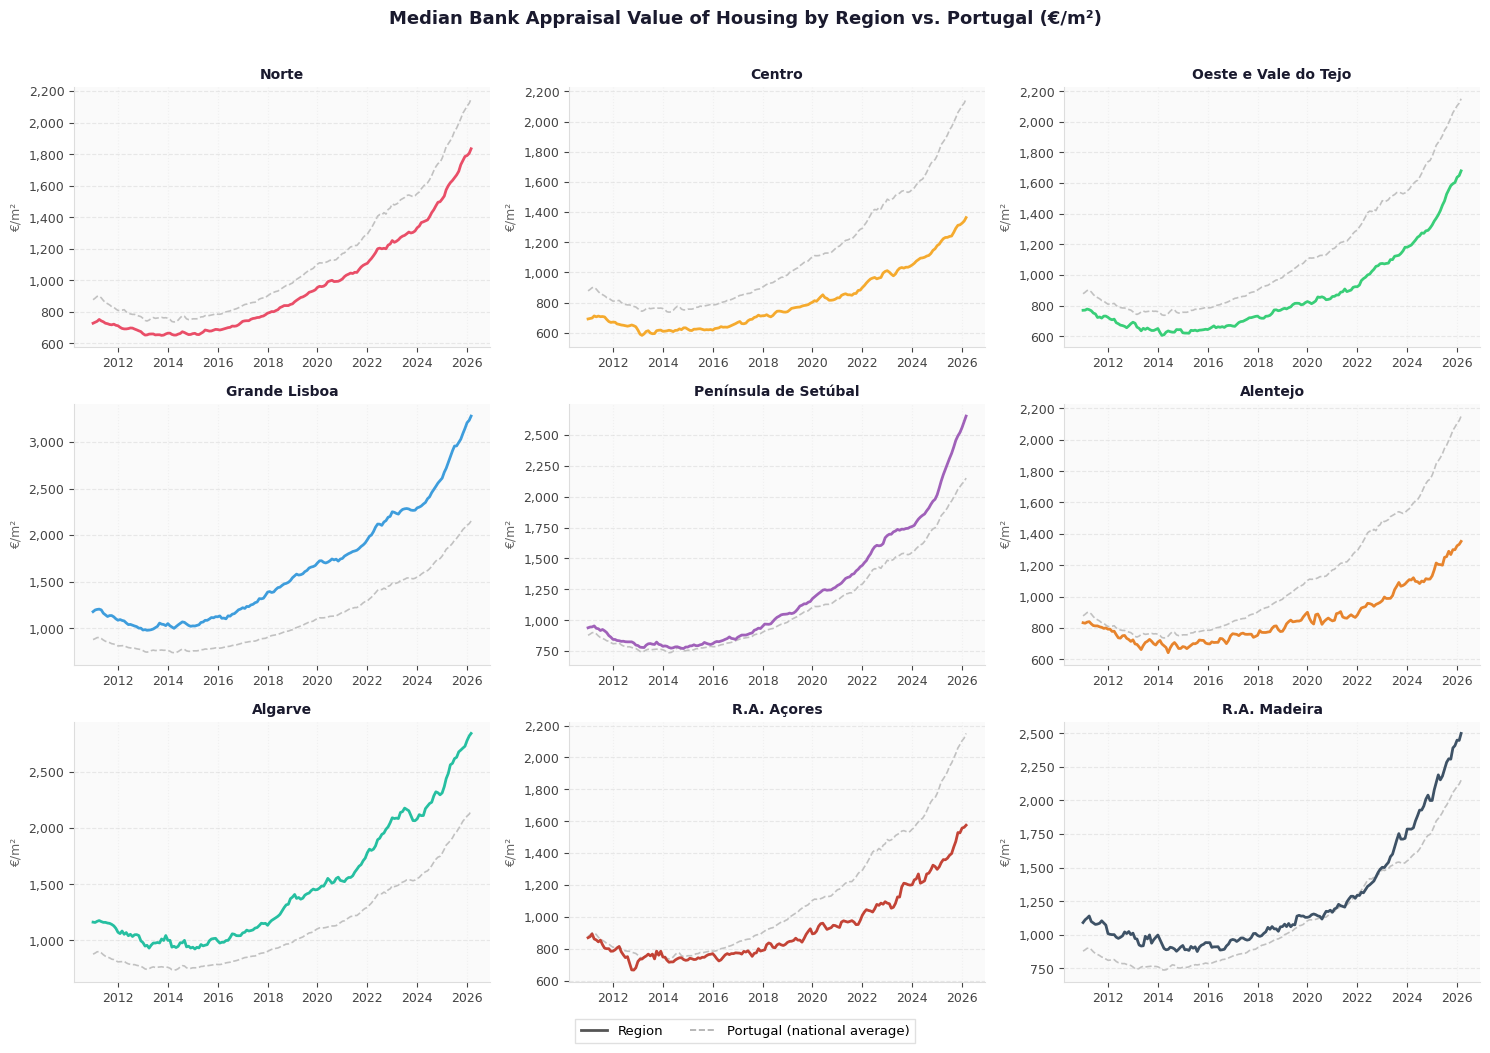

Chart 2 saved


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

df = pd.read_csv('avaliacao_bancaria_total.csv', index_col='date', parse_dates=True, encoding='latin-1')

colors = {
    'Portugal':                     '#1a1a2e',
    'Norte':                        '#e94560',
    'Centro':                       '#f5a623',
    'Oeste e Vale do Tejo':         '#2ecc71',
    'Grande Lisboa':                '#3498db',
    'Península de Setúbal':         '#9b59b6',
    'Alentejo':                     '#e67e22',
    'Algarve':                      '#1abc9c',
    'Região Autónoma dos Açores':   '#c0392b',
    'Região Autónoma da Madeira':   '#34495e',
}

short_names = {
    'Portugal':                     'Portugal',
    'Norte':                        'Norte',
    'Centro':                       'Centro',
    'Oeste e Vale do Tejo':         'Oeste e Vale do Tejo',
    'Grande Lisboa':                'Grande Lisboa',
    'Península de Setúbal':         'Península de Setúbal',
    'Alentejo':                     'Alentejo',
    'Algarve':                      'Algarve',
    'Região Autónoma dos Açores':   'R.A. Açores',
    'Região Autónoma da Madeira':   'R.A. Madeira',
}

def style_ax(ax):
    ax.set_facecolor('#fafafa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#ddd')
    ax.spines['bottom'].set_color('#ddd')
    ax.grid(axis='y', linestyle='--', alpha=0.4, color='#ccc')
    ax.grid(axis='x', linestyle=':', alpha=0.2, color='#ccc')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(labelsize=9, colors='#444')
    ax.set_ylabel('€/m²', fontsize=9, color='#666')

# ─────────────────────────────────────────────
# CHART 1 — All regions on one plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')
style_ax(ax)

for col in df.columns:
    lw = 2.8 if col == 'Portugal' else 1.4
    alpha = 1.0 if col == 'Portugal' else 0.75
    zorder = 5 if col == 'Portugal' else 2
    ax.plot(df.index, df[col],
            color=colors[col],
            linewidth=lw,
            alpha=alpha,
            label=short_names[col],
            zorder=zorder)

# Shaded periods
ax.axvspan(pd.Timestamp('2011-01-01'), pd.Timestamp('2014-06-01'),
           alpha=0.05, color='red')

# Annotation lines
ax.axvline(pd.Timestamp('2011-06-01'), color='#c0392b', linewidth=0.8,
           linestyle=':', alpha=0.6)

ymax = df.max().max()
ax.text(pd.Timestamp('2011-08-01'), ymax * 0.70,
        'Financial crisis', fontsize=8, color='#c0392b', alpha=0.85)

ax.set_title('Median Bank Appraisal Value of Housing by Region (€/m²)',
             fontsize=13, fontweight='bold', pad=14, color='#1a1a2e')

ax.legend(loc='upper left', fontsize=8.5, framealpha=0.92,
          ncol=2, columnspacing=1, handlelength=1.8,
          edgecolor='#ddd', fancybox=False)

plt.tight_layout()
plt.savefig('chart1_all_regions.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Chart 1 saved")

# ─────────────────────────────────────────────
# CHART 2 — Small multiples, each region vs Portugal dashed
# ─────────────────────────────────────────────
nuts_regions = [c for c in df.columns if c not in ['Portugal']]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.patch.set_facecolor('white')

for i, region in enumerate(nuts_regions):
    ax = axes.flatten()[i]
    style_ax(ax)

    # Portugal dashed reference
    ax.plot(df.index, df['Portugal'],
            color='#aaaaaa', linewidth=1.2,
            linestyle='--', alpha=0.7, zorder=1)

    # Region line
    ax.plot(df.index, df[region],
            color=colors[region], linewidth=2.0,
            alpha=0.95, zorder=2)

    ax.set_title(short_names[region], fontsize=10,
                 fontweight='bold', color='#1a1a2e', pad=6)

fig.suptitle('Median Bank Appraisal Value of Housing by Region vs. Portugal (€/m²)',
             fontsize=13, fontweight='bold', color='#1a1a2e', y=1.01)

# Shared legend at bottom
legend_elements = [
    Line2D([0], [0], color='#555', linewidth=2.0, label='Region'),
    Line2D([0], [0], color='#aaa', linewidth=1.2,
           linestyle='--', label='Portugal (national average)'),
]
fig.legend(handles=legend_elements, loc='lower center',
           fontsize=9.5, framealpha=0.9, edgecolor='#ddd',
           fancybox=False, ncol=2, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('chart2_small_multiples.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Chart 2 saved")

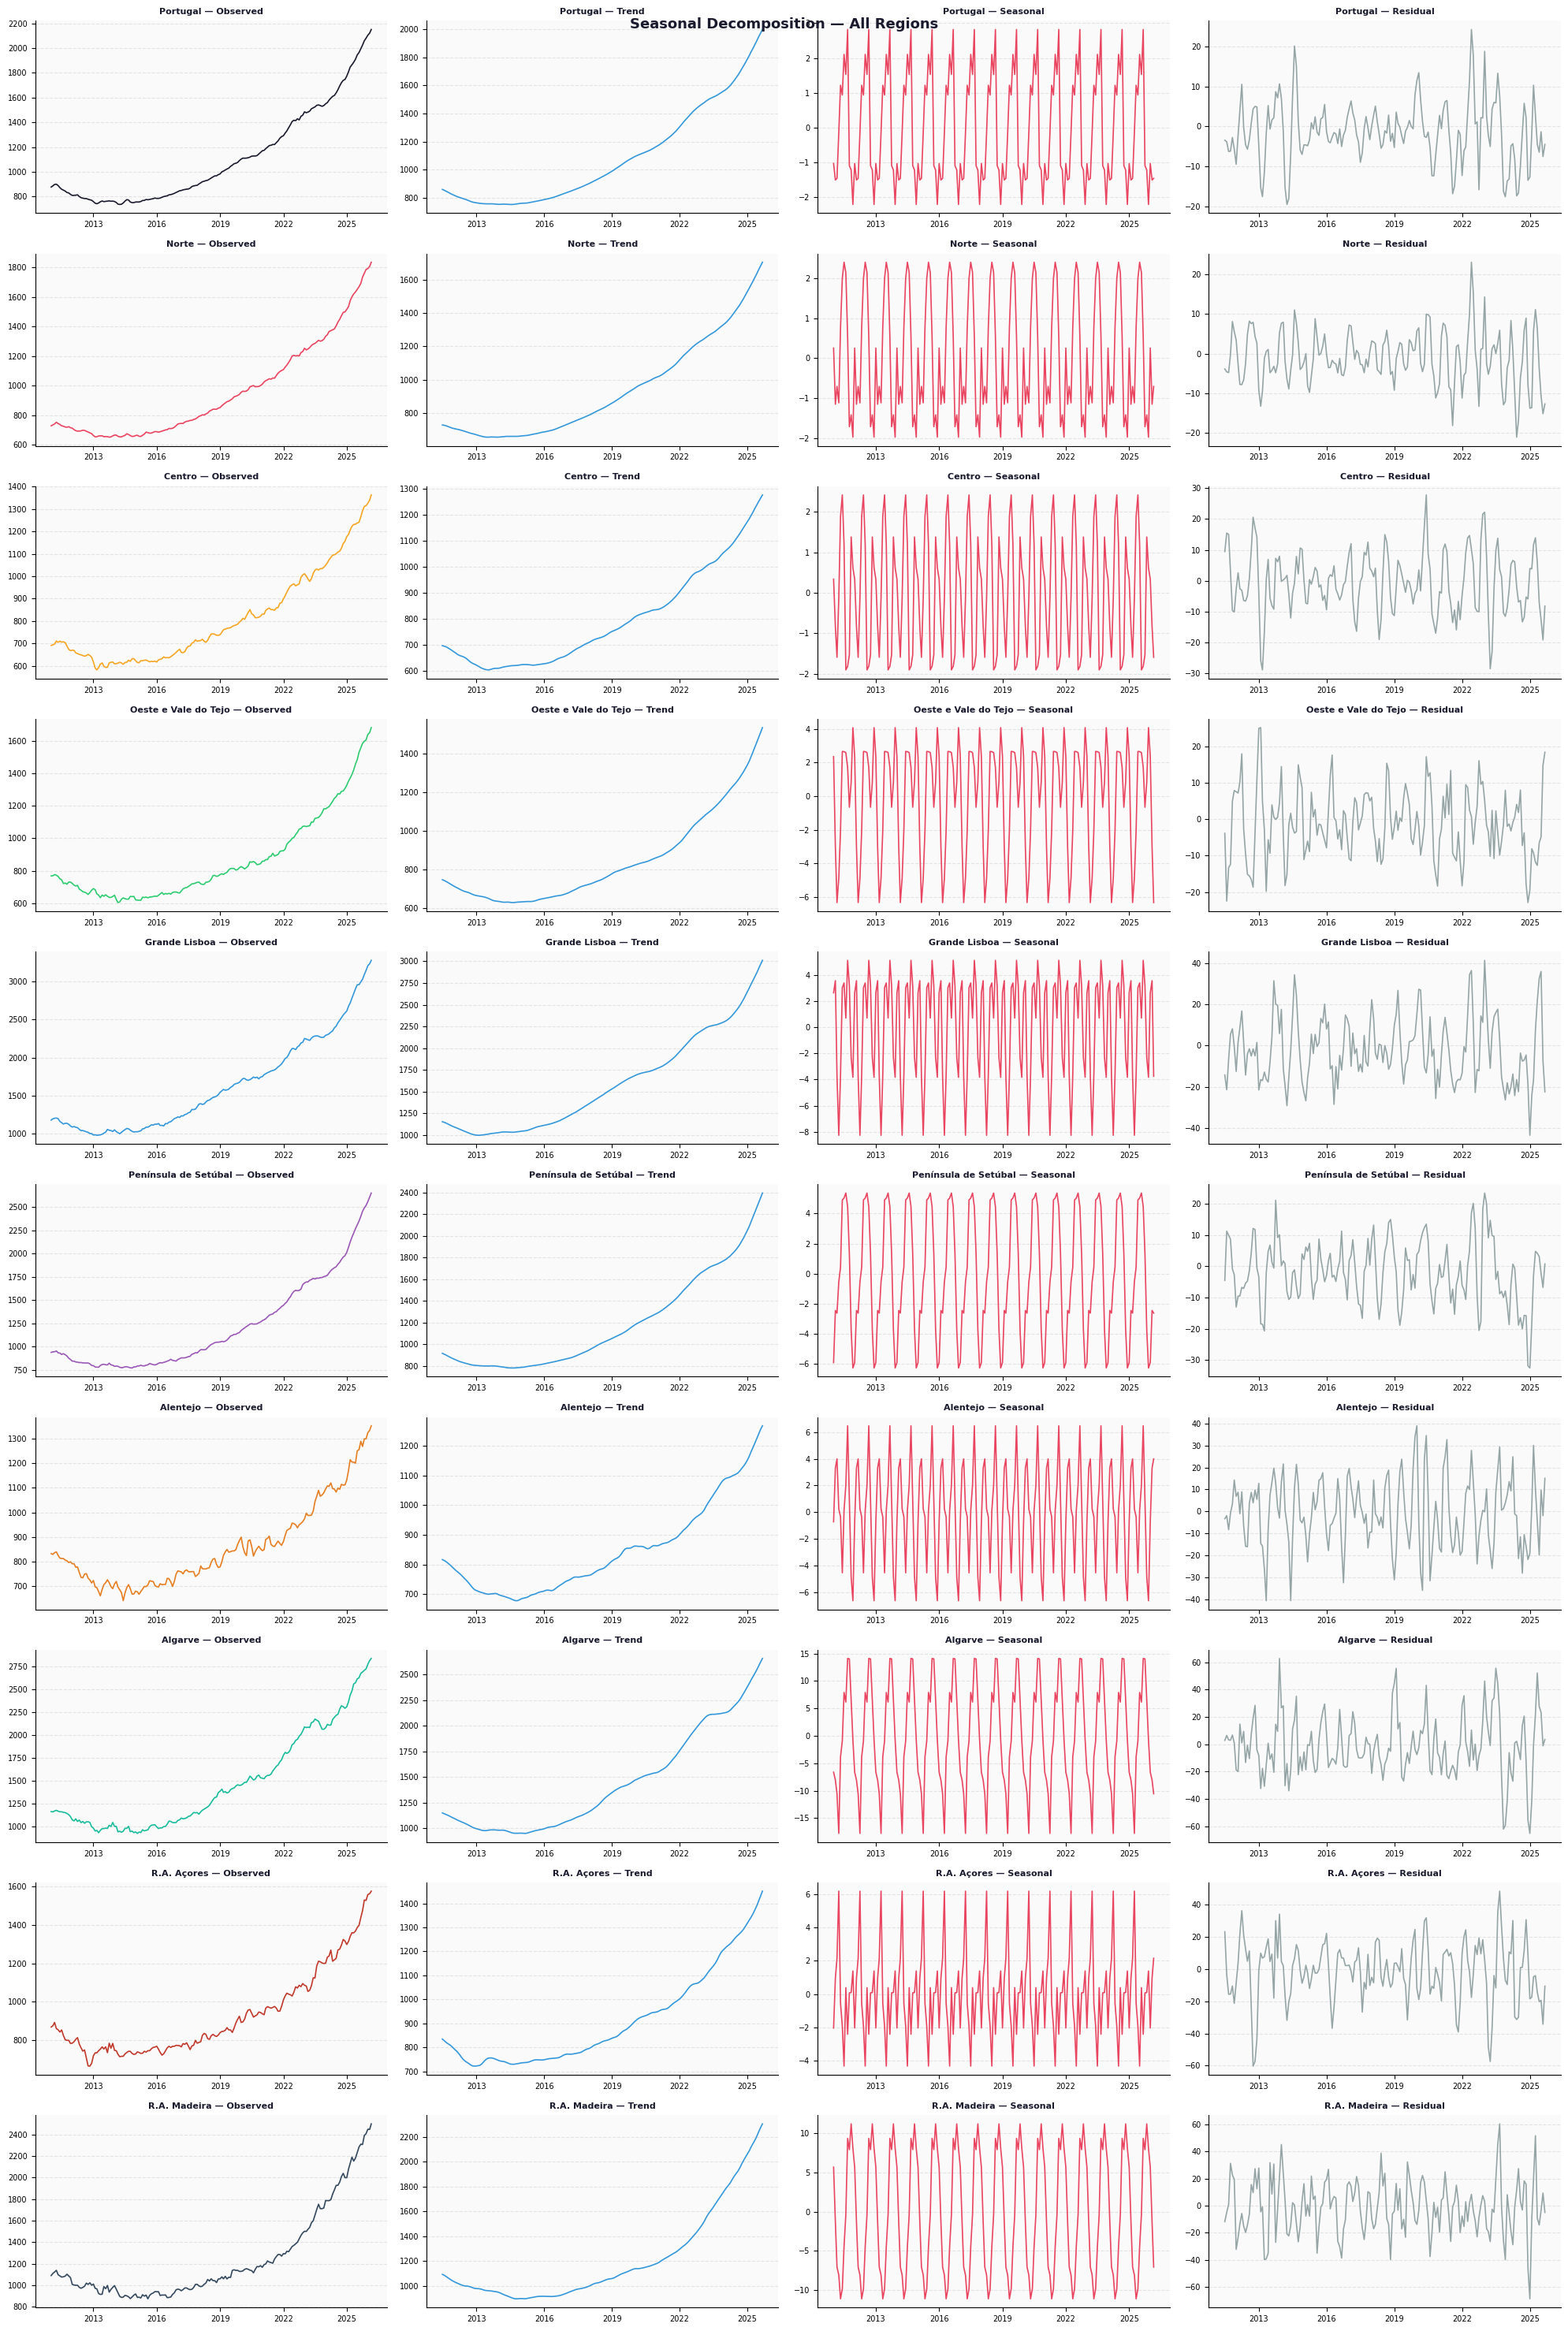


SEASONAL STRENGTH (seasonal std / observed std)
Region                         Strength     Verdict
-------------------------------------------------------
Portugal                       0.0042       → ARIMA is fine
Norte                          0.0047       → ARIMA is fine
Centro                         0.0072       → ARIMA is fine
Oeste e Vale do Tejo           0.0123       → ARIMA is fine
Grande Lisboa                  0.0066       → ARIMA is fine
Península de Setúbal           0.0085       → ARIMA is fine
Alentejo                       0.0218       → ARIMA is fine
Algarve                        0.0180       → ARIMA is fine
R.A. Açores                    0.0117       → ARIMA is fine
R.A. Madeira                   0.0188       → ARIMA is fine


In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(df.columns), 4, figsize=(20, len(df.columns) * 3))
fig.patch.set_facecolor('white')

seasonal_strength = {}

for i, col in enumerate(df.columns):
    decomp = seasonal_decompose(df[col].dropna(), model='additive', period=12)

    components = [
        (decomp.observed,  'Observed',  colors[col]),
        (decomp.trend,     'Trend',     '#3498db'),
        (decomp.seasonal,  'Seasonal',  '#e94560'),
        (decomp.resid,     'Residual',  '#95a5a6'),
    ]

    for j, (data, title, color) in enumerate(components):
        ax = axes[i, j]
        ax.plot(data.index, data, color=color, linewidth=1.2)
        ax.set_title(f'{short_names[col]} — {title}', fontsize=8,
                     fontweight='bold', color='#1a1a2e')
        ax.set_facecolor('#fafafa')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=7)
        ax.xaxis.set_major_locator(mdates.YearLocator(3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # Seasonal strength metric
    strength = decomp.seasonal.std() / decomp.observed.std()
    seasonal_strength[col] = strength

fig.suptitle('Seasonal Decomposition — All Regions',
             fontsize=13, fontweight='bold', color='#1a1a2e')
plt.tight_layout()
plt.savefig('seasonal_decomposition.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

# Print seasonal strength
print(f"\n{'='*55}")
print("SEASONAL STRENGTH (seasonal std / observed std)")
print(f"{'='*55}")
print(f"{'Region':<30} {'Strength':<12} {'Verdict'}")
print("-" * 55)
for col, strength in seasonal_strength.items():
    verdict = "→ SARIMA recommended" if strength > 0.1 else "→ ARIMA is fine"
    print(f"{short_names[col]:<30} {strength:.4f}       {verdict}")

ADF TEST (H0: series has unit root = non-stationary)
Portugal                       p=0.9989
Norte                          p=0.9987
Centro                         p=1.0000
Oeste e Vale do Tejo           p=1.0000
Grande Lisboa                  p=0.9988
Península de Setúbal           p=1.0000
Alentejo                       p=1.0000
Algarve                        p=0.9990
R.A. Açores                    p=1.0000
R.A. Madeira                   p=1.0000


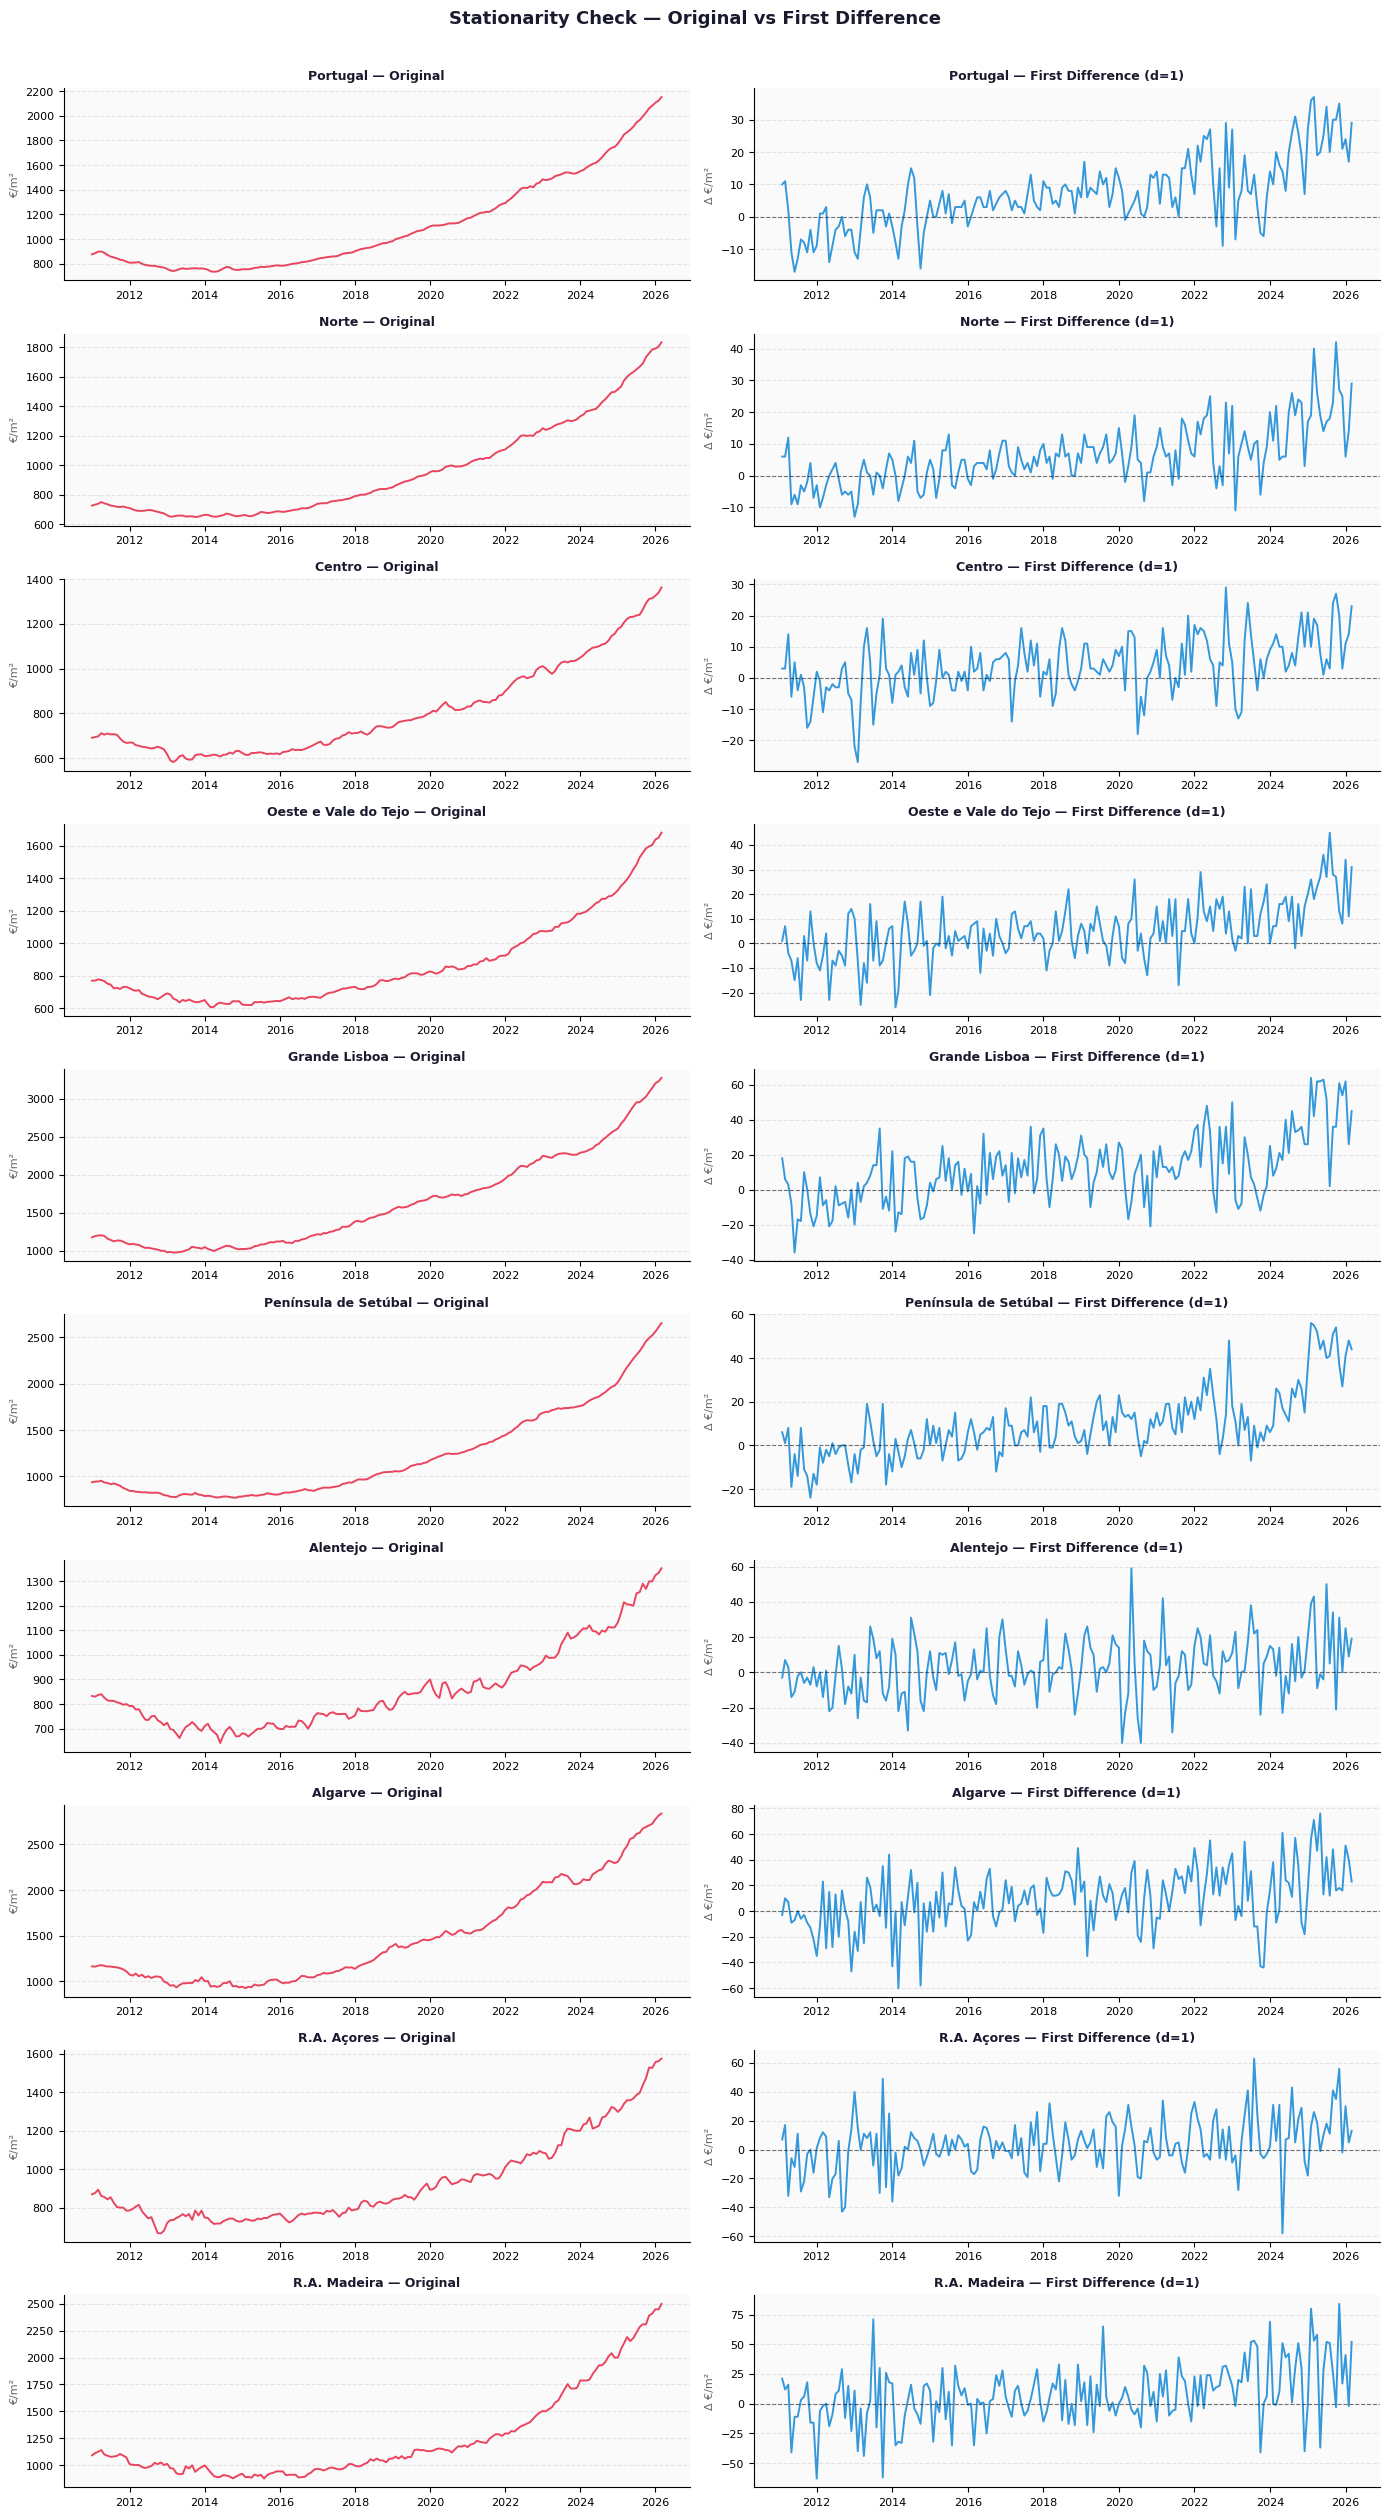

ADF visual saved


In [3]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

short_names = {
    'Portugal': 'Portugal',
    'Norte': 'Norte',
    'Centro': 'Centro',
    'Oeste e Vale do Tejo': 'Oeste e Vale do Tejo',
    'Grande Lisboa': 'Grande Lisboa',
    'Península de Setúbal': 'Península de Setúbal',
    'Alentejo': 'Alentejo',
    'Algarve': 'Algarve',
    'Região Autónoma dos Açores': 'R.A. Açores',
    'Região Autónoma da Madeira': 'R.A. Madeira'
}

# ─────────────────────────────────────────────
# STEP 1 — ADF TEST (stationarity)
# ─────────────────────────────────────────────
print("=" * 60)
print("ADF TEST (H0: series has unit root = non-stationary)")
print("=" * 60)

adf_results = {}
for col in df.columns:
    result = adfuller(df[col].dropna())
    adf_results[col] = result[1]
    print(f"{short_names[col]:<30} p={result[1]:.4f}")

fig, axes = plt.subplots(len(df.columns), 2, figsize=(14, len(df.columns) * 2.5))
fig.patch.set_facecolor('white')

for i, col in enumerate(df.columns):
    # Raw series
    ax1 = axes[i, 0]
    ax1.plot(df.index, df[col], color='#e94560', linewidth=1.4)
    ax1.set_title(f'{short_names[col]} — Original', fontsize=9, fontweight='bold', color='#1a1a2e')
    ax1.set_ylabel('€/m²', fontsize=8, color='#666')
    ax1.set_facecolor('#fafafa')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    ax1.tick_params(labelsize=8)

    # First difference
    ax2 = axes[i, 1]
    ax2.plot(df.index, df[col].diff(), color='#3498db', linewidth=1.4)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax2.set_title(f'{short_names[col]} — First Difference (d=1)', fontsize=9, fontweight='bold', color='#1a1a2e')
    ax2.set_ylabel('Δ €/m²', fontsize=8, color='#666')
    ax2.set_facecolor('#fafafa')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(axis='y', linestyle='--', alpha=0.3)
    ax2.tick_params(labelsize=8)

    # ADF p-value as annotation
    p = adf_results[col]
    
    

fig.suptitle('Stationarity Check — Original vs First Difference',
             fontsize=13, fontweight='bold', color='#1a1a2e', y=1.005)
plt.tight_layout()
plt.savefig('adf_visual.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("ADF visual saved")

ADF TEST — RAW SERIES (H0: unit root = non-stationary)
Region                         ADF Stat     p-value    Lags     CV 1%      CV 5%      CV 10%     Result
-----------------------------------------------------------------------------------------------
Portugal                       2.2690       0.9989     7        -3.4683    -2.8782    -2.5757    Non-stationary
Norte                          2.0508       0.9987     14       -3.4699    -2.8789    -2.5760    Non-stationary
Centro                         4.5297       1.0000     4        -3.4676    -2.8779    -2.5755    Non-stationary
Oeste e Vale do Tejo           4.2878       1.0000     6        -3.4681    -2.8781    -2.5756    Non-stationary
Grande Lisboa                  2.1595       0.9988     7        -3.4683    -2.8782    -2.5757    Non-stationary
Península de Setúbal           3.0640       1.0000     4        -3.4676    -2.8779    -2.5755    Non-stationary
Alentejo                       3.3790       1.0000     4        -3.4676  

C:\Users\ccruz\AppData\Local\Temp\ipykernel_18920\1939045764.py:69: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_r = kpss(series, regression='c', nlags='auto')
C:\Users\ccruz\AppData\Local\Temp\ipykernel_18920\1939045764.py:69: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_r = kpss(series, regression='c', nlags='auto')
C:\Users\ccruz\AppData\Local\Temp\ipykernel_18920\1939045764.py:69: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_r = kpss(series, regression='c', nlags='auto')
C:\Users\ccruz\AppData\Local\Temp\ipykernel_18920\1939045764.py:69: InterpolationWarning: The test statistic is outside of the range 

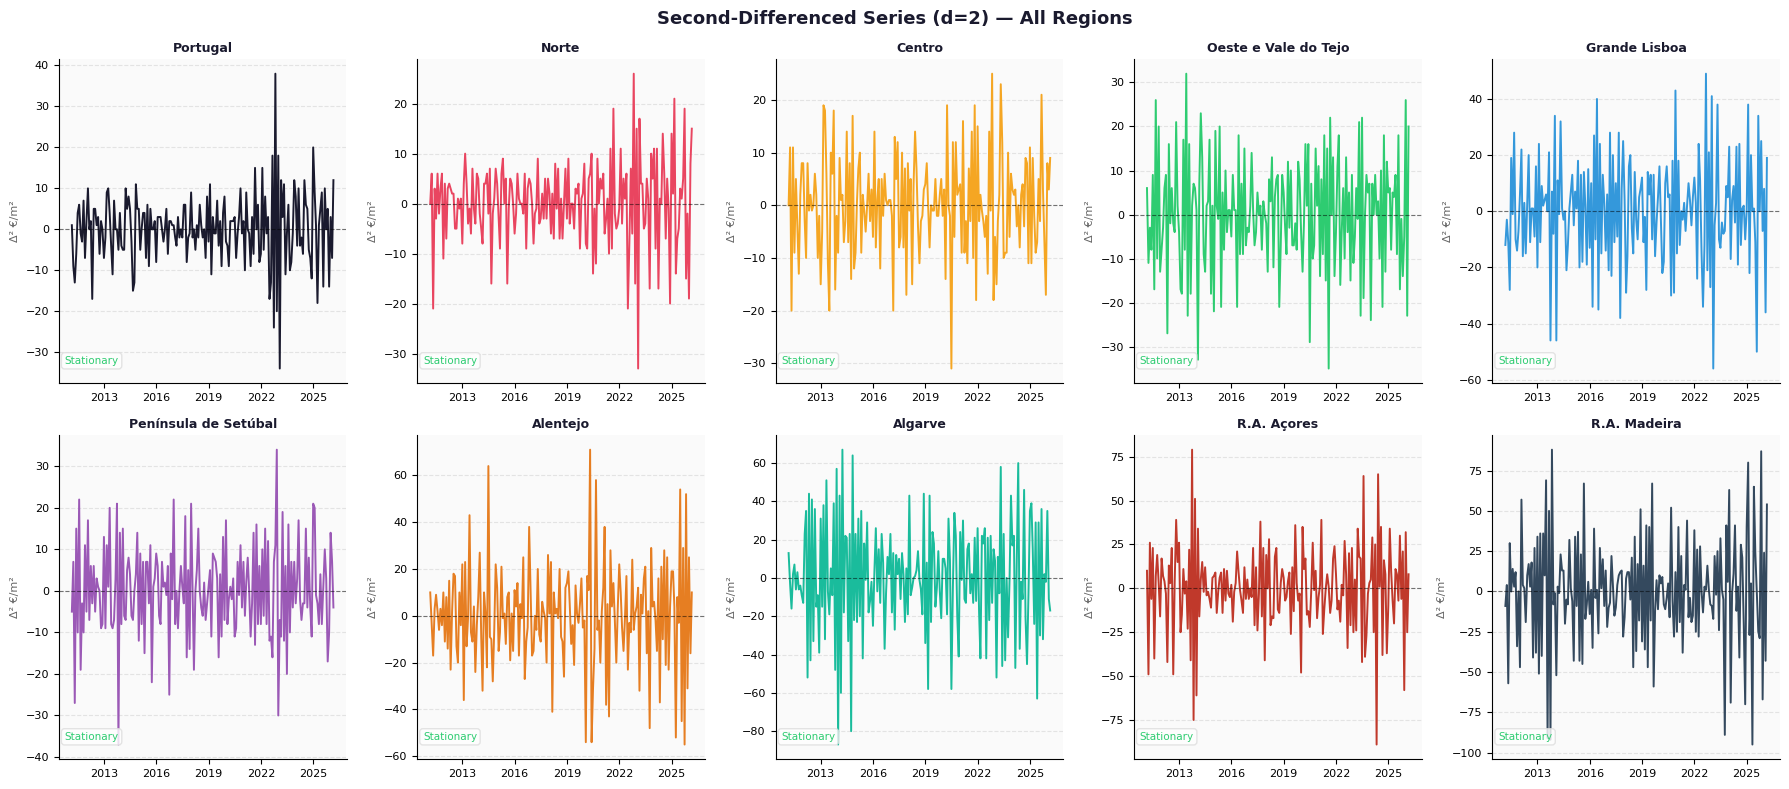

Plot saved as second_diff_all_regions.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller, kpss

short_names = {
    'Portugal': 'Portugal',
    'Norte': 'Norte',
    'Centro': 'Centro',
    'Oeste e Vale do Tejo': 'Oeste e Vale do Tejo',
    'Grande Lisboa': 'Grande Lisboa',
    'Península de Setúbal': 'Península de Setúbal',
    'Alentejo': 'Alentejo',
    'Algarve': 'Algarve',
    'Região Autónoma dos Açores': 'R.A. Açores',
    'Região Autónoma da Madeira': 'R.A. Madeira'
}

colors = {
    'Portugal': '#1a1a2e', 'Norte': '#e94560',
    'Centro': '#f5a623', 'Oeste e Vale do Tejo': '#2ecc71',
    'Grande Lisboa': '#3498db', 'Península de Setúbal': '#9b59b6',
    'Alentejo': '#e67e22', 'Algarve': '#1abc9c',
    'Região Autónoma dos Açores': '#c0392b', 'Região Autónoma da Madeira': '#34495e',
}

def get_conclusion(adf_p, kpss_p):
    adf_stat = adf_p < 0.05    # True = stationary
    kpss_stat = kpss_p > 0.05  # True = stationary
    if adf_stat and kpss_stat:
        return "Stationary"
    elif not adf_stat and not kpss_stat:
        return "Non-stationary"
    else:
        return "Conflicting"

# ─────────────────────────────────────────────
# TABLE 1 — ADF ON RAW SERIES
# ─────────────────────────────────────────────
print("=" * 95)
print("ADF TEST — RAW SERIES (H0: unit root = non-stationary)")
print("=" * 95)
print(f"{'Region':<30} {'ADF Stat':<12} {'p-value':<10} {'Lags':<8} {'CV 1%':<10} {'CV 5%':<10} {'CV 10%':<10} {'Result'}")
print("-" * 95)

adf_raw = {}
for col in df.columns:
    r = adfuller(df[col].dropna())
    adf_raw[col] = {'stat': r[0], 'p': r[1], 'lags': r[2],
                    'cv1': r[4]['1%'], 'cv5': r[4]['5%'], 'cv10': r[4]['10%']}
    status = "Stationary" if r[1] < 0.05 else "Non-stationary"
    print(f"{short_names[col]:<30} {r[0]:<12.4f} {r[1]:<10.4f} {r[2]:<8} {r[4]['1%']:<10.4f} {r[4]['5%']:<10.4f} {r[4]['10%']:<10.4f} {status}")

print("\nLag length selected using AIC. Critical values from MacKinnon (1996).")

# ─────────────────────────────────────────────
# TABLE 2 — ADF + KPSS ON FIRST DIFFERENCE
# ─────────────────────────────────────────────
print("\n" + "=" * 115)
print("ADF + KPSS — FIRST DIFFERENCE")
print("=" * 115)
print(f"{'Region':<30} {'ADF Stat':<12} {'ADF p':<10} {'CV 5%':<10} {'KPSS Stat':<12} {'KPSS p':<10} {'CV 5%':<10} {'Conclusion'}")
print("-" * 115)

diff1_results = {}
for col in df.columns:
    series = df[col].diff().dropna()
    adf_r = adfuller(series)
    kpss_r = kpss(series, regression='c', nlags='auto')
    adf_p = adf_r[1]
    kpss_p = kpss_r[1]
    conclusion = get_conclusion(adf_p, kpss_p)
    diff1_results[col] = {'adf_p': adf_p, 'kpss_p': kpss_p, 'conclusion': conclusion}
    print(f"{short_names[col]:<30} {adf_r[0]:<12.4f} {adf_p:<10.4f} {adf_r[4]['5%']:<10.4f} {kpss_r[0]:<12.4f} {kpss_p:<10.4f} {kpss_r[3]['5%']:<10.4f} {conclusion}")

print("\nADF H0: unit root (non-stationary). KPSS H0: stationary.")
print("Lag length selected using AIC. Critical values from MacKinnon (1996) and Kwiatkowski et al. (1992).")

# ─────────────────────────────────────────────
# TABLE 3 — ADF + KPSS ON SECOND DIFFERENCE
# ─────────────────────────────────────────────
print("\n" + "=" * 115)
print("ADF + KPSS — SECOND DIFFERENCE")
print("=" * 115)
print(f"{'Region':<30} {'ADF Stat':<12} {'ADF p':<10} {'CV 5%':<10} {'KPSS Stat':<12} {'KPSS p':<10} {'CV 5%':<10} {'Conclusion'}")
print("-" * 115)

diff2_results = {}
for col in df.columns:
    series = df[col].diff().diff().dropna()
    adf_r = adfuller(series)
    kpss_r = kpss(series, regression='c', nlags='auto')
    adf_p = adf_r[1]
    kpss_p = kpss_r[1]
    conclusion = get_conclusion(adf_p, kpss_p)
    diff2_results[col] = {'adf_p': adf_p, 'kpss_p': kpss_p, 'conclusion': conclusion}
    print(f"{short_names[col]:<30} {adf_r[0]:<12.4f} {adf_p:<10.4f} {adf_r[4]['5%']:<10.4f} {kpss_r[0]:<12.4f} {kpss_p:<10.4f} {kpss_r[3]['5%']:<10.4f} {conclusion}")

print("\nADF H0: unit root (non-stationary). KPSS H0: stationary.")
print("Lag length selected using AIC. Critical values from MacKinnon (1996) and Kwiatkowski et al. (1992).")

# ─────────────────────────────────────────────
# PLOT — SECOND DIFFERENCE ALL REGIONS
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.patch.set_facecolor('white')

for i, col in enumerate(df.columns):
    ax = axes.flatten()[i]
    series = df[col].diff().diff().dropna()

    ax.plot(series.index, series, color=colors[col], linewidth=1.4)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    p2 = diff2_results[col]['p'] if 'p' in diff2_results[col] else diff2_results[col]['adf_p']
    conclusion = diff2_results[col]['conclusion']

    ax.set_title(f'{short_names[col]}', fontsize=9,
                 fontweight='bold', color='#1a1a2e', pad=5)
    ax.set_ylabel('Δ² €/m²', fontsize=8, color='#666')
    ax.set_facecolor('#fafafa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    color_annot = '#2ecc71' if conclusion == 'Stationary' else '#e94560' if conclusion == 'Non-stationary' else '#f5a623'
    ax.annotate(f'{conclusion}',
                xy=(0.02, 0.06), xycoords='axes fraction', fontsize=7.5,
                color=color_annot,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='#ddd', alpha=0.8))

fig.suptitle('Second-Differenced Series (d=2) — All Regions',
             fontsize=13, fontweight='bold', color='#1a1a2e')
plt.tight_layout()
plt.savefig('second_diff_all_regions.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Plot saved as second_diff_all_regions.png")

In [5]:
# ─────────────────────────────────────────────
# STEP 2 — FIRST DIFFERENCE + RE-TEST ADF
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2 — ADF TEST ON FIRST DIFFERENCE")
print("=" * 60)

df_diff = df.diff().dropna()
d_values = {}
for col in df.columns:
    result = adfuller(df_diff[col].dropna())
    status = "✅ Stationary → d=1" if result[1] < 0.05 else "❌ Still non-stationary → try d=2"
    d_values[col] = 1 if result[1] < 0.05 else 2
    print(f"{short_names[col]:<30} p={result[1]:.4f}  {status}")


STEP 2 — ADF TEST ON FIRST DIFFERENCE
Portugal                       p=0.7489  ❌ Still non-stationary → try d=2
Norte                          p=0.9736  ❌ Still non-stationary → try d=2
Centro                         p=0.6454  ❌ Still non-stationary → try d=2
Oeste e Vale do Tejo           p=0.9818  ❌ Still non-stationary → try d=2
Grande Lisboa                  p=0.6260  ❌ Still non-stationary → try d=2
Península de Setúbal           p=0.6718  ❌ Still non-stationary → try d=2
Alentejo                       p=0.0000  ✅ Stationary → d=1
Algarve                        p=0.0588  ❌ Still non-stationary → try d=2
R.A. Açores                    p=0.0000  ✅ Stationary → d=1
R.A. Madeira                   p=0.9627  ❌ Still non-stationary → try d=2


In [6]:
from statsmodels.tsa.stattools import adfuller, kpss

print("=" * 75)
print("COMBINED ADF + KPSS ON STATIONARY SERIES")
print("=" * 75)
print(f"{'Region':<30} {'d':<5} {'ADF p':<12} {'KPSS p':<12} {'Conclusion'}")
print("-" * 75)

for col in df_.columns:
    d = d_values[col]
    if d == 1:
        series = df_[col].diff().dropna()
    else:
        series = df_[col].diff().diff().dropna()

    adf_p = adfuller(series.dropna())[1]
    kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression='c', nlags='auto')

    # Interpret combined result
    adf_stat = adf_p < 0.05   # True = stationary
    kpss_stat_ = kpss_p > 0.05  # True = stationary

    if adf_stat and kpss_stat_:
        conclusion = "✅ Confirmed stationary"
    elif adf_stat and not kpss_stat_:
        conclusion = "⚠️ Conflicting — check series"
    elif not adf_stat and kpss_stat_:
        conclusion = "⚠️ Conflicting — structural break?"
    else:
        conclusion = "❌ Non-stationary — difference more"

    print(f"{short_names[col]:<30} {d:<5} {adf_p:<12.4f} {kpss_p:<12.4f} {conclusion}")

COMBINED ADF + KPSS ON STATIONARY SERIES
Region                         d     ADF p        KPSS p       Conclusion
---------------------------------------------------------------------------


NameError: name 'df_' is not defined

In [7]:
from statsmodels.tsa.stattools import adfuller, kpss

print("=" * 75)
print("ALENTEJO AND R.A. AÇORES — TESTING d=2")
print("=" * 75)
print(f"{'Region':<30} {'ADF p':<12} {'KPSS p':<12} {'Conclusion'}")
print("-" * 75)

for col in ['Alentejo', 'Região Autónoma dos Açores']:
    series = df_[col].diff().diff().dropna()
    adf_p = adfuller(series.dropna())[1]
    kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression='c', nlags='auto')

    if adf_p < 0.05 and kpss_p > 0.05:
        conclusion = "✅ Confirmed stationary at d=2 → update to d=2"
    elif adf_p < 0.05 and kpss_p <= 0.05:
        conclusion = "⚠️ Still conflicting — keep d=1"
    else:
        conclusion = "❌ Non-stationary"

    print(f"{short_names[col]:<30} {adf_p:<12.4f} {kpss_p:<12.4f} {conclusion}")

ALENTEJO AND R.A. AÇORES — TESTING d=2
Region                         ADF p        KPSS p       Conclusion
---------------------------------------------------------------------------


NameError: name 'df_' is not defined

NameError: name 'df_' is not defined

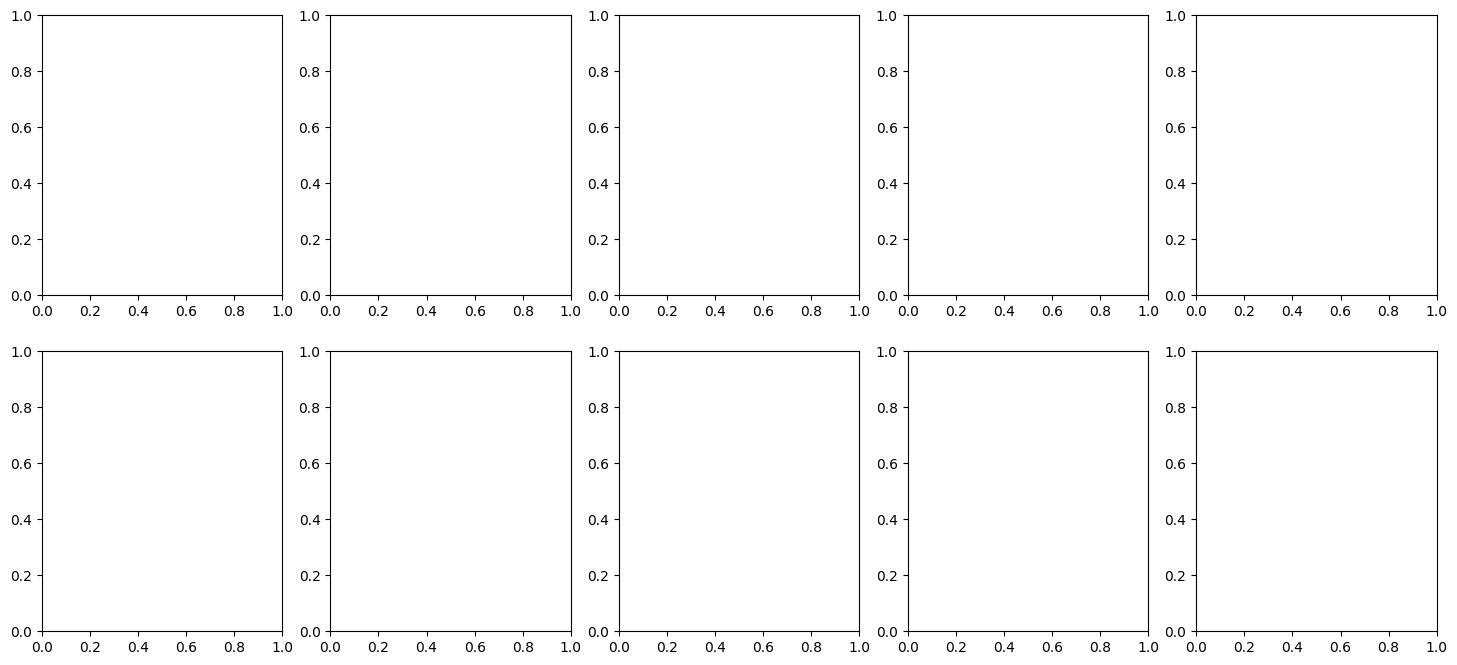

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller

colors = {
    'Portugal': '#1a1a2e', 'Norte': '#e94560',
    'Centro': '#f5a623', 'Oeste e Vale do Tejo': '#2ecc71',
    'Grande Lisboa': '#3498db', 'Península de Setúbal': '#9b59b6',
    'Alentejo': '#e67e22', 'Algarve': '#1abc9c',
    'Região Autónoma dos Açores': '#c0392b', 'Região Autónoma da Madeira': '#34495e',
}

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.patch.set_facecolor('white')

for i, col in enumerate(df_.columns):
    ax = axes.flatten()[i]

    series = df_[col].diff().diff().dropna()  # d=2 for all
    p_val = adfuller(series.dropna())[1]

    ax.plot(series.index, series, color=colors[col], linewidth=1.4)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(f'{short_names[col]}  (d=2)', fontsize=9,
                 fontweight='bold', color='#1a1a2e', pad=5)
    ax.set_ylabel('Δ² €/m²', fontsize=8, color='#666')
    ax.set_facecolor('#fafafa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.annotate(f'ADF p={p_val:.4f}', xy=(0.02, 0.06),
                xycoords='axes fraction', fontsize=7.5,
                color='#2ecc71' if p_val < 0.05 else '#e94560',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='#ddd', alpha=0.8))

fig.suptitle('Stationary Series After Second Differencing (d=2) — by Region',
             fontsize=13, fontweight='bold', color='#1a1a2e')
plt.tight_layout()
plt.savefig('stationary_series.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

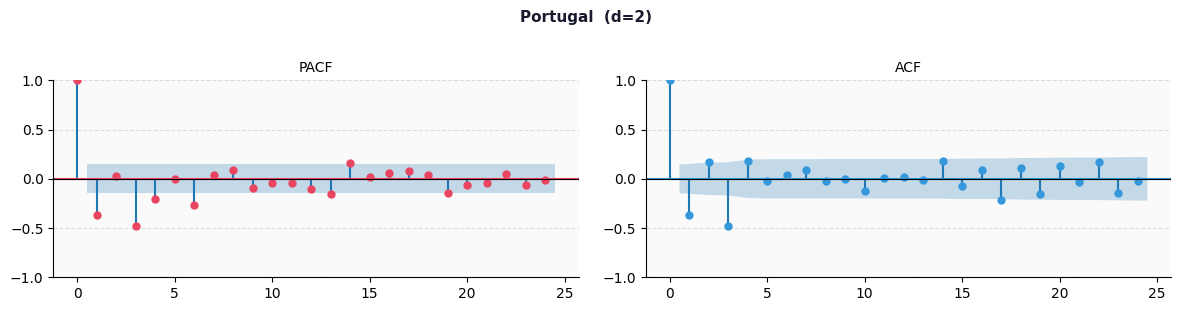

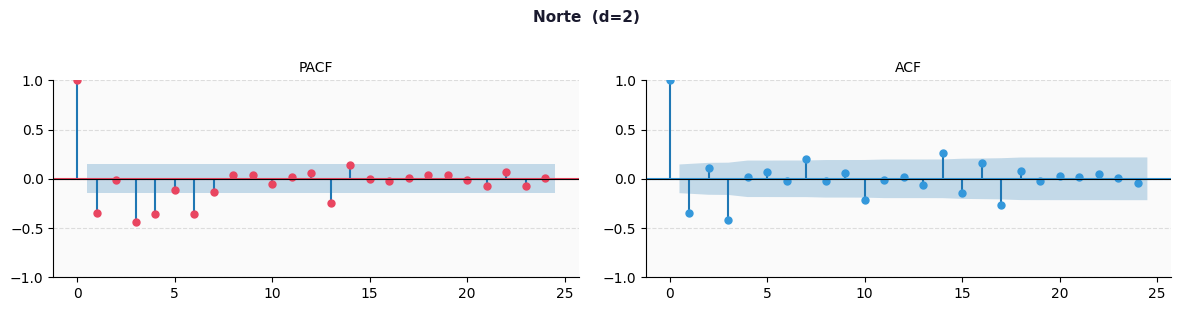

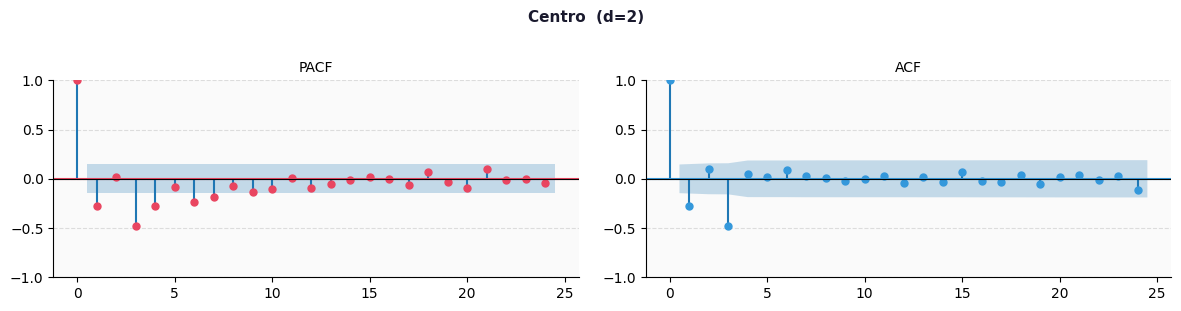

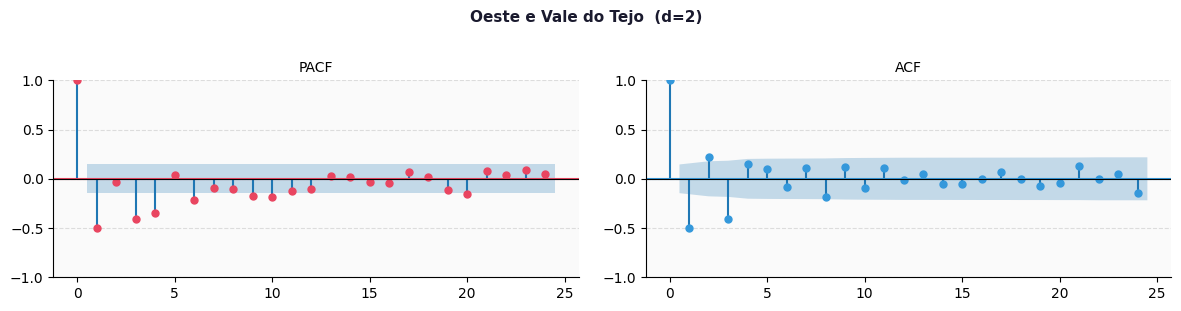

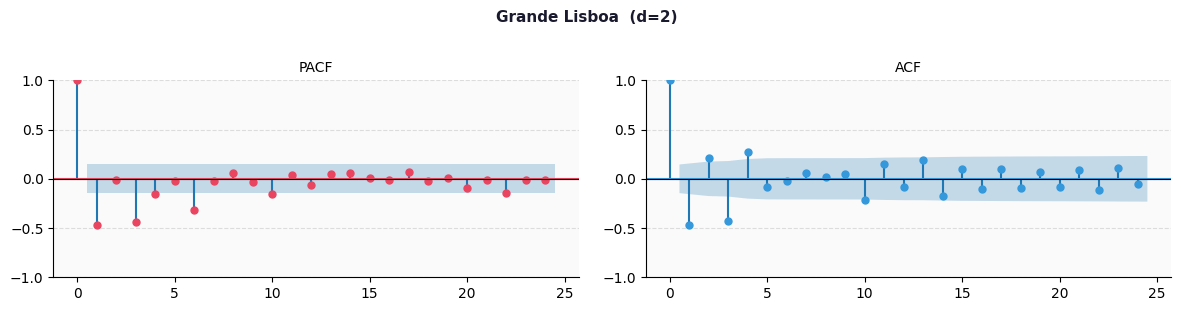

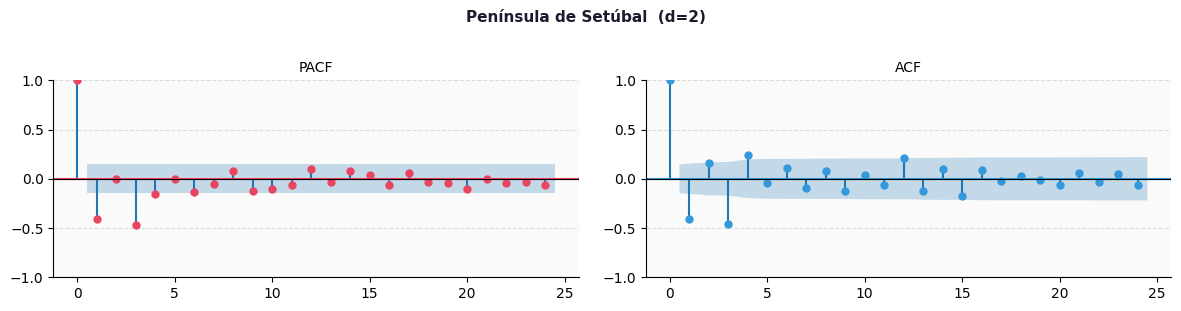

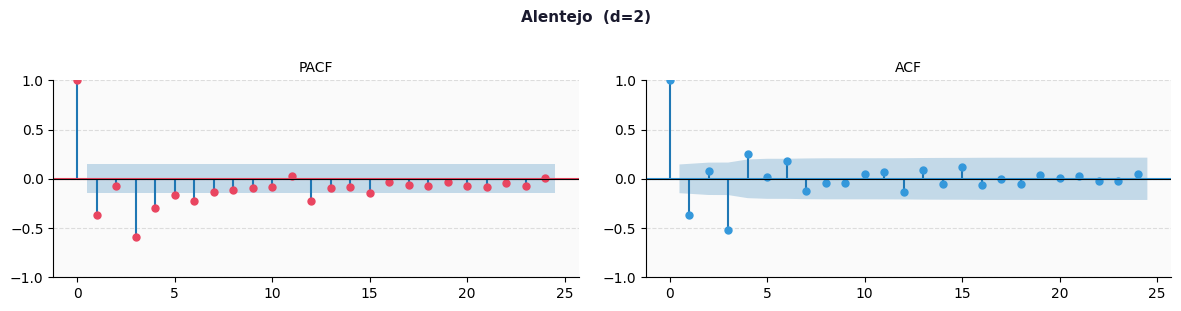

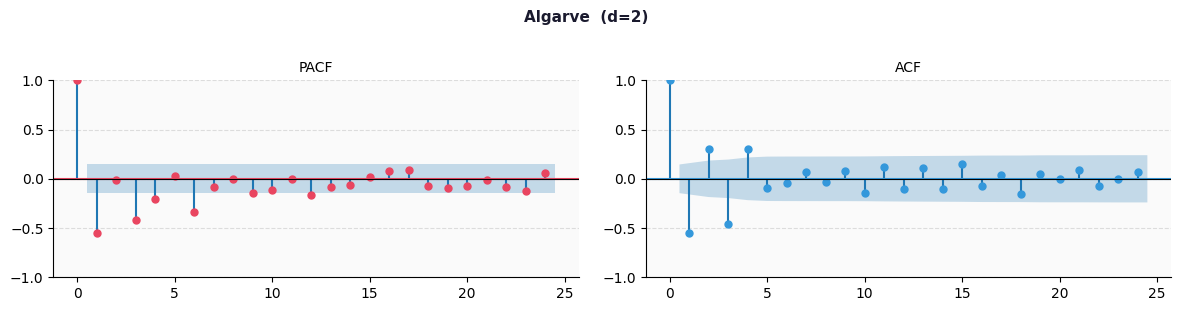

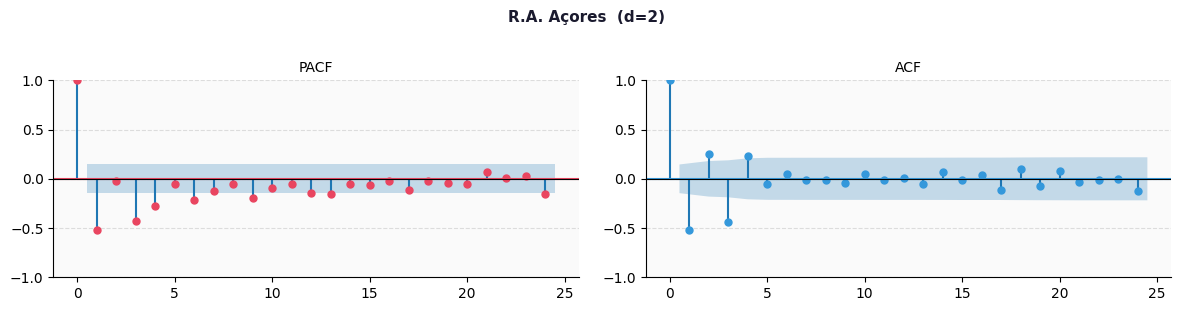

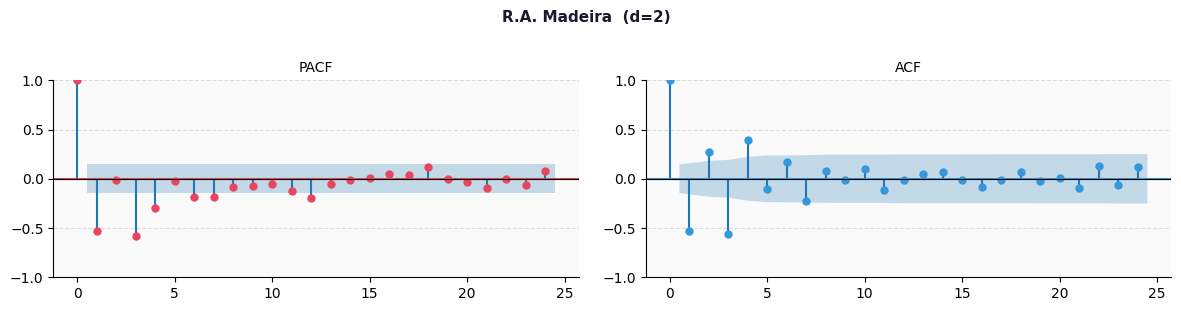

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for col in df.columns:
    series = df[col].diff().diff().dropna()  # d=2 for all

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    fig.patch.set_facecolor('white')

    plot_pacf(series, ax=axes[0], lags=24, color='#e94560')
    plot_acf(series, ax=axes[1], lags=24, color='#3498db')

    axes[0].set_title(f'PACF', fontsize=10)
    axes[1].set_title(f'ACF', fontsize=10)

    for ax in axes:
        ax.set_facecolor('#fafafa')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.axhline(y=0, color='black', linewidth=0.8)

    plt.suptitle(f'{short_names[col]}  (d=2)', fontsize=11,
                 fontweight='bold', color='#1a1a2e', y=1.02)
    plt.tight_layout()
    plt.savefig(f'acf_pacf_{col.replace(" ", "_").replace("/", "")}.png',
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()

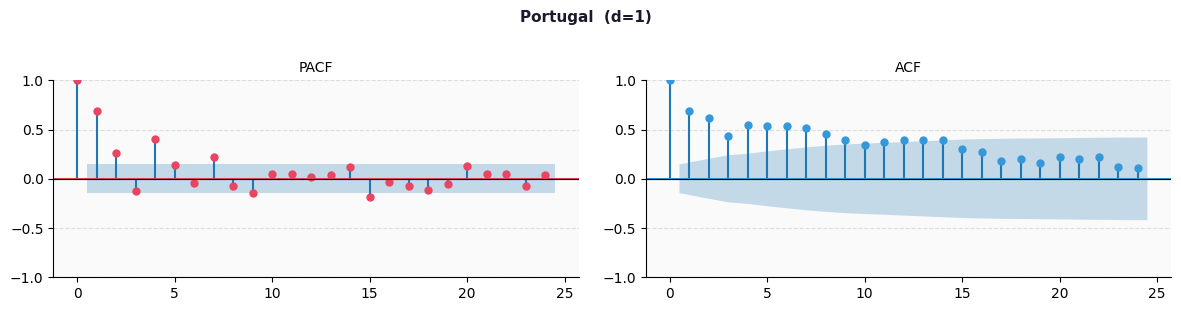

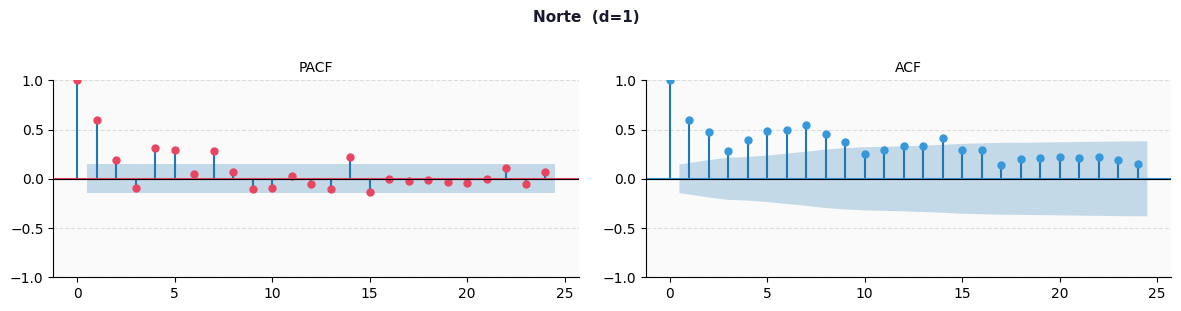

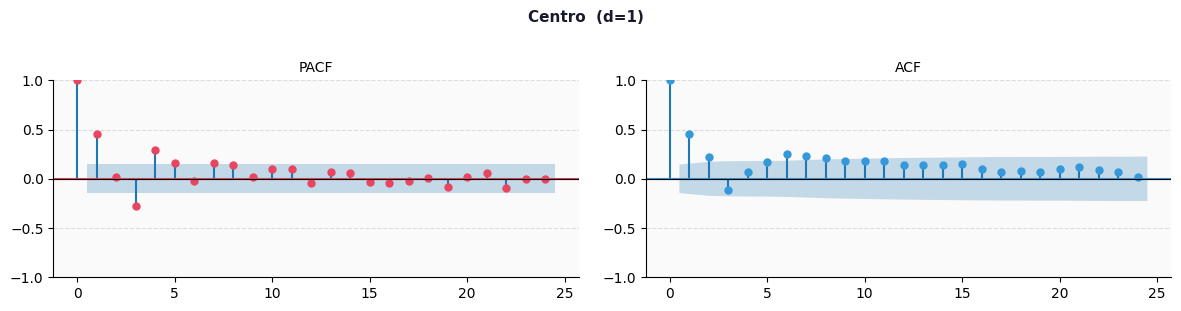

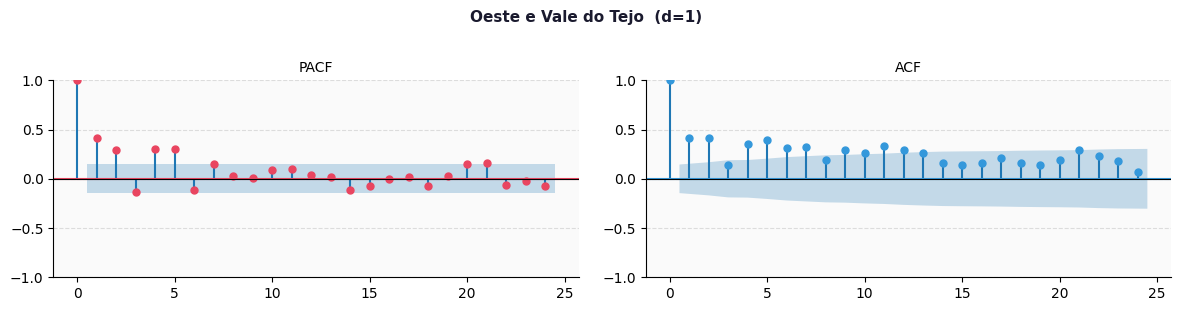

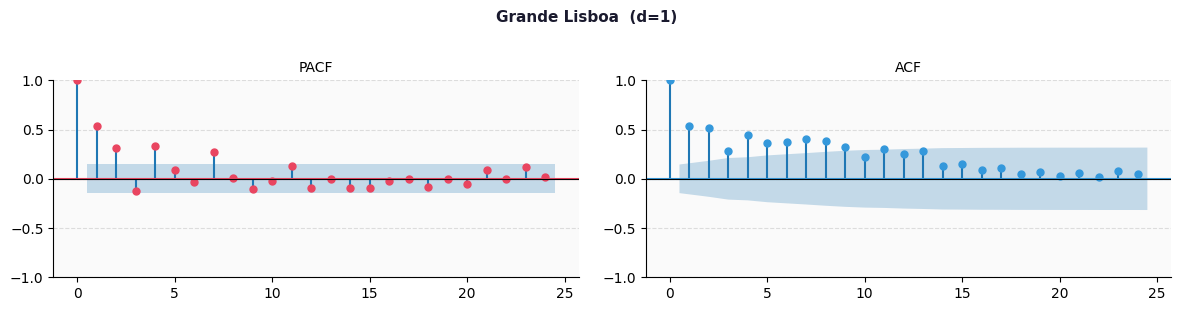

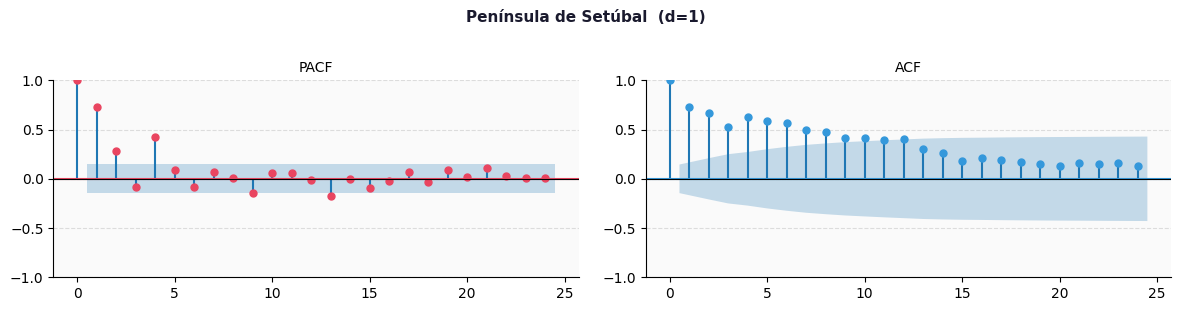

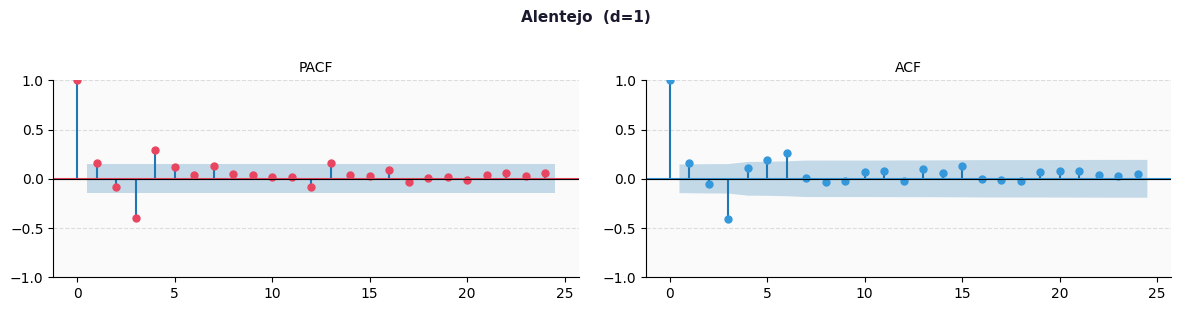

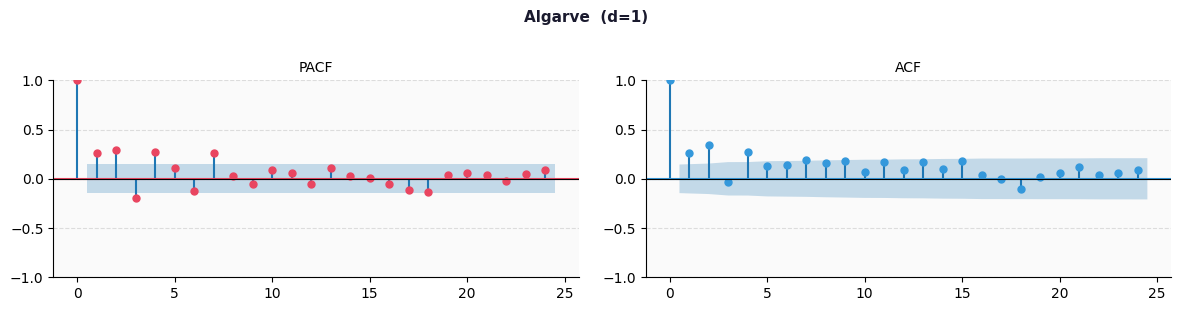

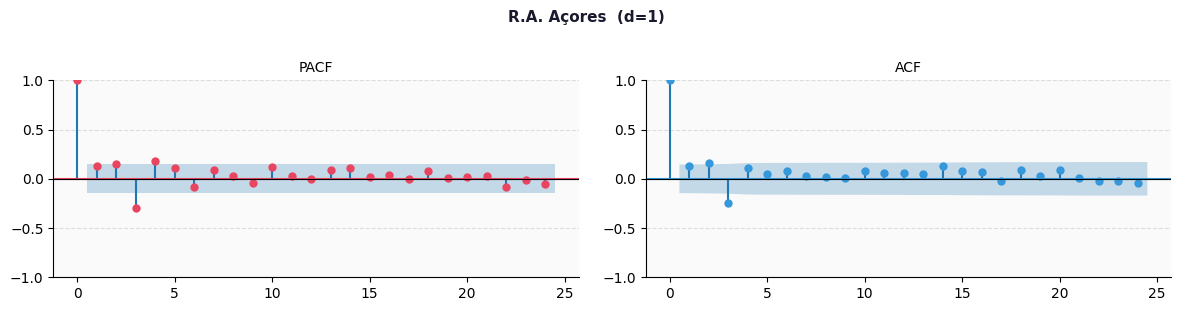

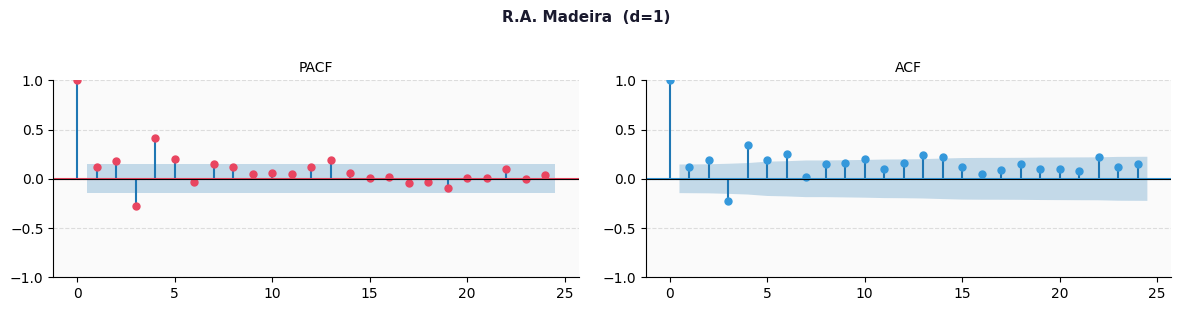

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for col in df.columns:
    series = df[col].diff().dropna()  # d=2 for all

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    fig.patch.set_facecolor('white')

    plot_pacf(series, ax=axes[0], lags=24, color='#e94560')
    plot_acf(series, ax=axes[1], lags=24, color='#3498db')

    axes[0].set_title(f'PACF', fontsize=10)
    axes[1].set_title(f'ACF', fontsize=10)

    for ax in axes:
        ax.set_facecolor('#fafafa')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.axhline(y=0, color='black', linewidth=0.8)

    plt.suptitle(f'{short_names[col]}  (d=1)', fontsize=11,
                 fontweight='bold', color='#1a1a2e', y=1.02)
    plt.tight_layout()
    plt.savefig(f'acf_pacf_{col.replace(" ", "_").replace("/", "")}.png',
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()

In [10]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

candidates = [(0,2,0), (0,2,1), (0,2,2), (1,2,0), (1,2,1), (1,2,2), (2,2,0), (2,2,1), (2,2,2)]

# ─────────────────────────────────────────────
# FIT ALL MODELS
# ─────────────────────────────────────────────
results = {}
for col in df.columns:
    region_aic = {}
    best_aic = float('inf')
    best_model = None
    for order in candidates:
        try:
            model = ARIMA(df[col], order=order).fit()
            region_aic[order] = model.aic
            if model.aic < best_aic:
                best_aic = model.aic
                best_model = order
        except:
            region_aic[order] = float('nan')
    results[col] = {'aic': region_aic, 'best': best_model, 'best_aic': best_aic}

# ─────────────────────────────────────────────
# PRINT TABLE
# ─────────────────────────────────────────────
col_w = 10  # width for each AIC column

header_models = ''.join([f"{str(o):<{col_w}}" for o in candidates])
print("=" * (32 + col_w * len(candidates) + 15))
print(f"{'Region':<30}  {header_models}  {'Best model'}")
print("-" * (32 + col_w * len(candidates) + 15))

for col in df.columns:
    aic_vals = results[col]['aic']
    best = results[col]['best']
    best_aic = results[col]['best_aic']

    row_vals = ''
    for order in candidates:
        val = aic_vals[order]
        cell = f"{val:.1f}" if not pd.isna(val) else "—"
        # Bold the best with an asterisk
        if order == best:
            cell = f"{cell}*"
        row_vals += f"{cell:<{col_w}}"

    print(f"{short_names[col]:<30}  {row_vals}  ARIMA{best}")

print("=" * (32 + col_w * len(candidates) + 15))
print("* Lowest AIC per region")
print("\nLag length selected using AIC. Model estimated by Maximum Likelihood.")

Region                          (0, 2, 0) (0, 2, 1) (0, 2, 2) (1, 2, 0) (1, 2, 1) (1, 2, 2) (2, 2, 0) (2, 2, 1) (2, 2, 2)   Best model
-----------------------------------------------------------------------------------------------------------------------------------------
Portugal                        1284.1    1243.4    1237.4    1259.0    1254.3    1235.9    1260.8    1235.5    1226.7*     ARIMA(2, 2, 2)
Norte                           1280.2    1226.0    1219.6    1259.0    1218.3*   1220.3    1261.0    1220.1    1218.7      ARIMA(1, 2, 1)
Centro                          1330.0    1290.4    1275.5    1317.3    1313.2    1273.8    1319.2    1273.1    1270.5*     ARIMA(2, 2, 2)
Oeste e Vale do Tejo            1433.3    1344.3    1345.4    1383.6    1345.1    1347.3    1385.5    1345.7    1340.5*     ARIMA(2, 2, 2)
Grande Lisboa                   1574.9    1508.1    1508.2    1531.2    1507.3    1510.5    1533.2    1506.7    1498.3*     ARIMA(2, 2, 2)
Península de Setúbal            

In [11]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

candidates = [(0,2,0), (0,2,1), (0,2,2), (1,2,0), (1,2,1), (1,2,2), (2,2,0), (2,2,1), (2,2,2)]

# ─────────────────────────────────────────────
# FIT ALL MODELS & COMPUTE AIC/BIC
# ─────────────────────────────────────────────
results = {}
for col in df.columns:
    region_aic = {}
    best_aic = float('inf')
    best_bic = float('inf')
    
    best_model_aic = None
    best_model_bic = None
    
    for order in candidates:
        try:
            model = ARIMA(df[col], order=order).fit()
            region_aic[order] = model.aic
            
            # Track best AIC configuration
            if model.aic < best_aic:
                best_aic = model.aic
                best_model_aic = order
                
            # Track best BIC configuration
            if model.bic < best_bic:
                best_bic = model.bic
                best_model_bic = order
        except:
            region_aic[order] = float('nan')
            
    results[col] = {
        'aic': region_aic, 
        'best_aic': best_model_aic,
        'best_bic': best_model_bic
    }

# ─────────────────────────────────────────────
# PRINT CONSOLIDATED COMPARISON TABLE
# ─────────────────────────────────────────────
col_w = 11  # Width for each individual AIC cell
header_models = ''.join([f"{str(o):<{col_w}}" for o in candidates])

# Dynamically size the visual dividers to avoid line-wrapping strings
table_width = 32 + (col_w * len(candidates)) + 30
print("=" * table_width)
print(f"{'Region':<30}  {header_models}  {'Best AIC':<15} {'Best BIC'}")
print("-" * table_width)

for col in df.columns:
    aic_vals = results[col]['aic']
    best_aic = results[col]['best_aic']
    best_bic = results[col]['best_bic']

    row_vals = ''
    for order in candidates:
        val = aic_vals[order]
        cell = f"{val:.1f}" if not pd.isna(val) else "—"
        
        # Flag the cell that represents the absolute lowest AIC value
        if order == best_aic:
            cell = f"{cell}*"
        row_vals += f"{cell:<{col_w}}"

    # Format output strings to explicitly flag the structural differences
    aic_str = f"ARIMA{best_aic}"
    bic_str = f"ARIMA{best_bic}"
    print(f"{short_names[col]:<30}  {row_vals}  {aic_str:<15} {bic_str}")

print("=" * table_width)
print("* Lowest AIC per region")

Region                          (0, 2, 0)  (0, 2, 1)  (0, 2, 2)  (1, 2, 0)  (1, 2, 1)  (1, 2, 2)  (2, 2, 0)  (2, 2, 1)  (2, 2, 2)    Best AIC        Best BIC
-----------------------------------------------------------------------------------------------------------------------------------------------------------------
Portugal                        1284.1     1243.4     1237.4     1259.0     1254.3     1235.9     1260.8     1235.5     1226.7*      ARIMA(2, 2, 2)  ARIMA(2, 2, 2)
Norte                           1280.2     1226.0     1219.6     1259.0     1218.3*    1220.3     1261.0     1220.1     1218.7       ARIMA(1, 2, 1)  ARIMA(1, 2, 1)
Centro                          1330.0     1290.4     1275.5     1317.3     1313.2     1273.8     1319.2     1273.1     1270.5*      ARIMA(2, 2, 2)  ARIMA(0, 2, 2)
Oeste e Vale do Tejo            1433.3     1344.3     1345.4     1383.6     1345.1     1347.3     1385.5     1345.7     1340.5*      ARIMA(2, 2, 2)  ARIMA(0, 2, 1)
Grande Lisboa           

Region                         Model           AIC          BIC
-----------------------------------------------------------------
Portugal                       ARIMA(2,2,2)   1226.7       1242.7
Norte                          ARIMA(2,2,2)   1218.7       1234.7
Centro                         ARIMA(2,2,2)   1270.5       1286.4
Oeste e Vale do Tejo           ARIMA(2,2,2)   1340.5       1356.5
Grande Lisboa                  ARIMA(2,2,2)   1498.3       1514.3
Península de Setúbal           ARIMA(2,2,2)   1323.1       1339.1
Alentejo                       ARIMA(2,2,2)   1525.2       1541.2
Algarve                        ARIMA(2,2,2)   1622.7       1638.7
R.A. Açores                    ARIMA(2,2,2)   1554.4       1570.4
R.A. Madeira                   ARIMA(2,2,2)   1650.8       1666.8


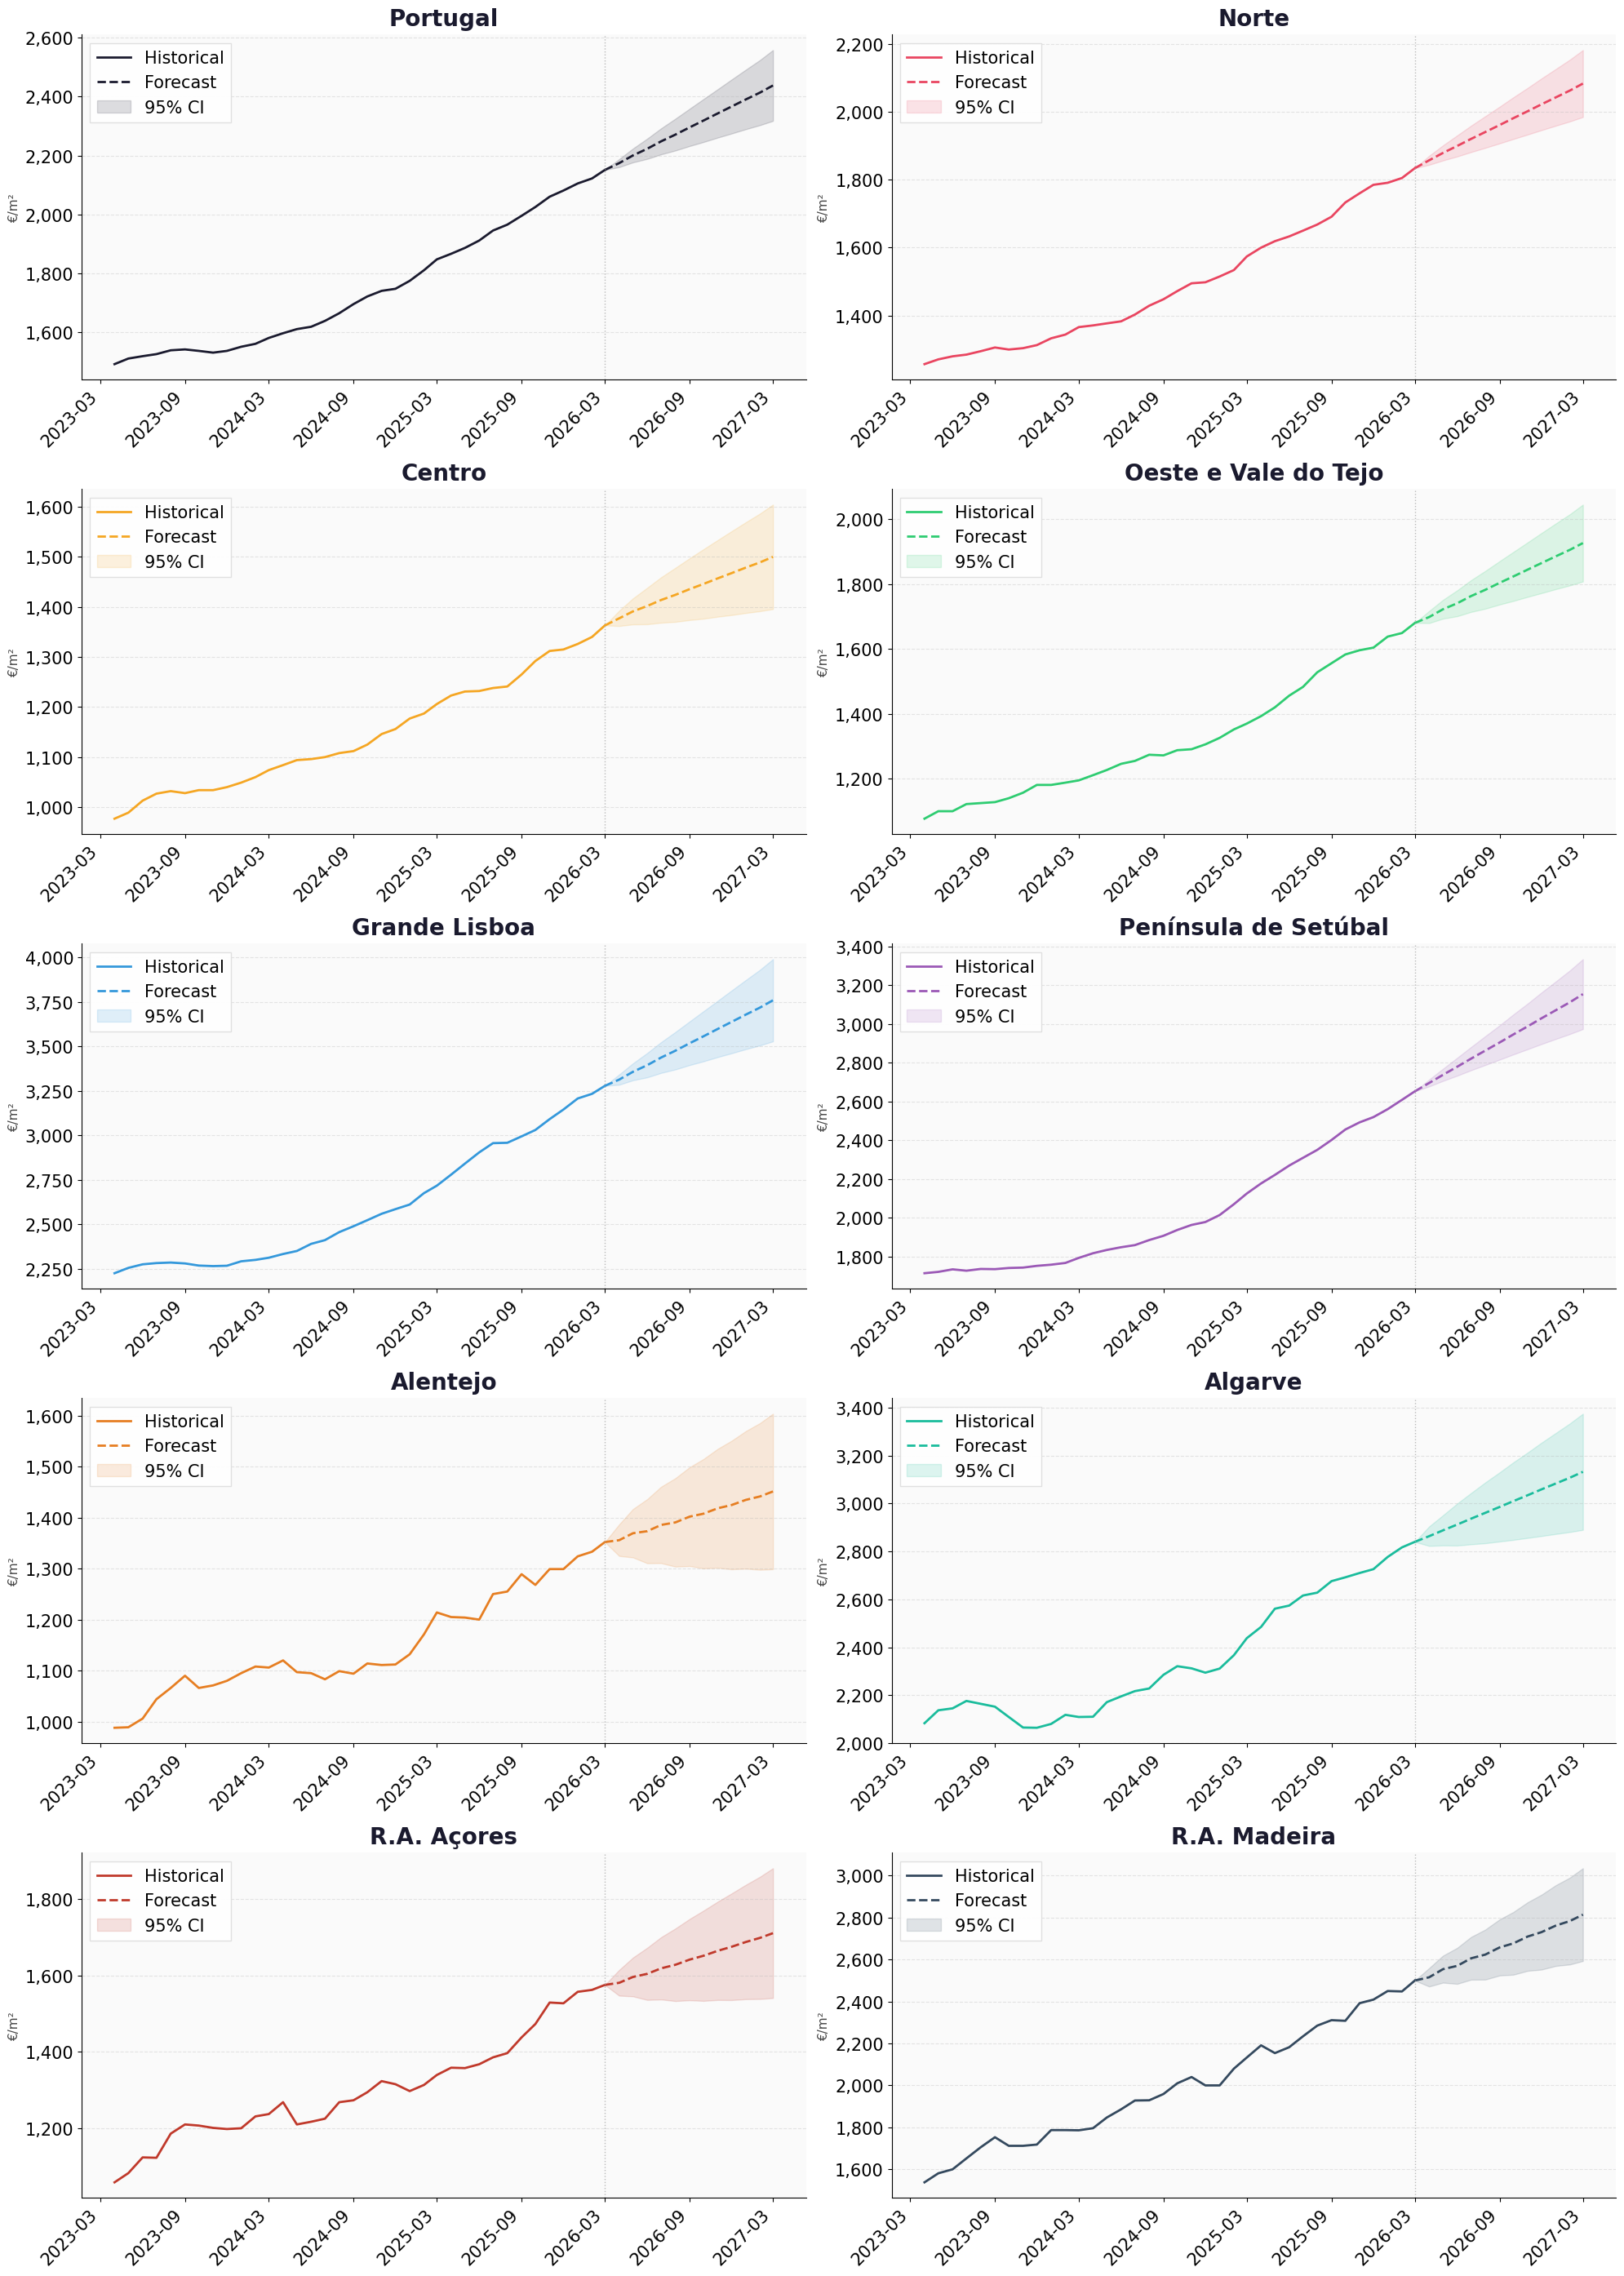


FORECAST TABLE — ARIMA(2,2,2) — CURRENT + NEXT 12 MONTHS (€/m²)
         Portugal  Norte  Centro  Oeste e Vale do Tejo  Grande Lisboa  Península de Setúbal  Alentejo  Algarve  R.A. Açores  R.A. Madeira
Month                                                                                                                                    
2026-03      2151   1834    1363                  1680           3278                  2653      1352     2840         1575          2500
2026-04      2174   1857    1377                  1698           3313                  2696      1356     2864         1580          2515
2026-05      2200   1879    1391                  1722           3357                  2738      1369     2888         1596          2554
2026-06      2223   1899    1402                  1741           3394                  2780      1373     2912         1604          2570
2026-07      2248   1920    1414                  1763           3437                  2821      1386     2

In [13]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# FIT ARIMA(2,2,2) FOR ALL REGIONS
# ─────────────────────────────────────────────
fitted_models = {}

print(f"{'Region':<30} {'Model':<15} {'AIC':<12} {'BIC'}")
print("-" * 65)

for col in df.columns:
    model = ARIMA(df[col], order=(2,2,2)).fit()
    fitted_models[col] = model
    print(f"{short_names[col]:<30} ARIMA(2,2,2)   {model.aic:<12.1f} {model.bic:.1f}")

# ─────────────────────────────────────────────
# FORECAST 12 MONTHS AHEAD
# ─────────────────────────────────────────────
forecast_steps = 12

fig, axes = plt.subplots(5, 2, figsize=(20, 28))
fig.patch.set_facecolor('white')

for i, col in enumerate(df.columns):
    ax = axes.flatten()[i]
    model = fitted_models[col]

    forecast = model.get_forecast(steps=forecast_steps)
    forecast_mean = forecast.predicted_mean
    conf_int = forecast.conf_int(alpha=0.05)

    # Include last observed point in forecast line to close the gap
    last_date = df[col].index[-1]
    last_val = df[col].iloc[-1]
    forecast_mean_plot = pd.concat([pd.Series([last_val], index=[last_date]), forecast_mean])
    conf_int_plot = pd.concat([
        pd.DataFrame([[last_val, last_val]], index=[last_date], columns=conf_int.columns),
        conf_int
    ])

    history = df[col].iloc[-36:]

    ax.plot(history.index, history,
            color=colors[col], linewidth=2.0, label='Historical')
    ax.plot(forecast_mean_plot.index, forecast_mean_plot,
            color=colors[col], linewidth=2.0, linestyle='--', label='Forecast')
    ax.fill_between(conf_int_plot.index,
                    conf_int_plot.iloc[:, 0],
                    conf_int_plot.iloc[:, 1],
                    color=colors[col], alpha=0.15, label='95% CI')

    ax.axvline(last_date, color='#aaa', linewidth=1, linestyle=':', alpha=0.8)

    ax.set_title(short_names[col], fontsize=20,
                 fontweight='bold', color='#1a1a2e', pad=8)
    ax.set_ylabel('€/m²', fontsize=11, color='#444')
    ax.set_facecolor('#fafafa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=15)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=15)

    ax.legend(fontsize=15, framealpha=0.9, edgecolor='#ddd', fancybox=False)

plt.tight_layout()
plt.savefig('forecast_all_regions.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

# ─────────────────────────────────────────────
# FORECAST VALUES TABLE — INCLUDING CURRENT MONTH
# ─────────────────────────────────────────────
print(f"\n{'='*65}")
print("FORECAST TABLE — ARIMA(2,2,2) — CURRENT + NEXT 12 MONTHS (€/m²)")
print(f"{'='*65}")

forecast_df = pd.DataFrame()

for col in df.columns:
    forecast = fitted_models[col].get_forecast(steps=forecast_steps)
    forecast_mean = forecast.predicted_mean.round(0).astype(int)

    # Add current month as first row
    current = pd.Series(
        [int(df[col].iloc[-1])],
        index=[df[col].index[-1]],
        name=short_names[col]
    )
    full_series = pd.concat([current, forecast_mean.rename(short_names[col])])
    forecast_df[short_names[col]] = full_series

# Format index as YYYY-MM
forecast_df.index = forecast_df.index.strftime('%Y-%m')
forecast_df.index.name = 'Month'

print(forecast_df.to_string())
forecast_df.to_csv('forecast_12months.csv')
print("\nForecast saved to forecast_12months.csv")

LJUNG-BOX TEST ON RESIDUALS (H0: residuals are white noise)
Region                         Lag 12 stat     Lag 12 p     Lag 24 stat     Lag 24 p     Result
----------------------------------------------------------------------
Portugal                       28.3957         0.0048       28.4860         0.2401       Autocorrelation
Norte                          28.4382         0.0048       28.4829         0.2402       Autocorrelation
Centro                         28.3614         0.0049       28.4761         0.2405       Autocorrelation
Oeste e Vale do Tejo           28.9698         0.0040       29.2547         0.2107       Autocorrelation
Grande Lisboa                  26.8509         0.0081       27.0887         0.3003       Autocorrelation
Península de Setúbal           28.2798         0.0050       28.3497         0.2456       Autocorrelation
Alentejo                       27.5220         0.0065       28.0720         0.2570       Autocorrelation
Algarve                        27.9099

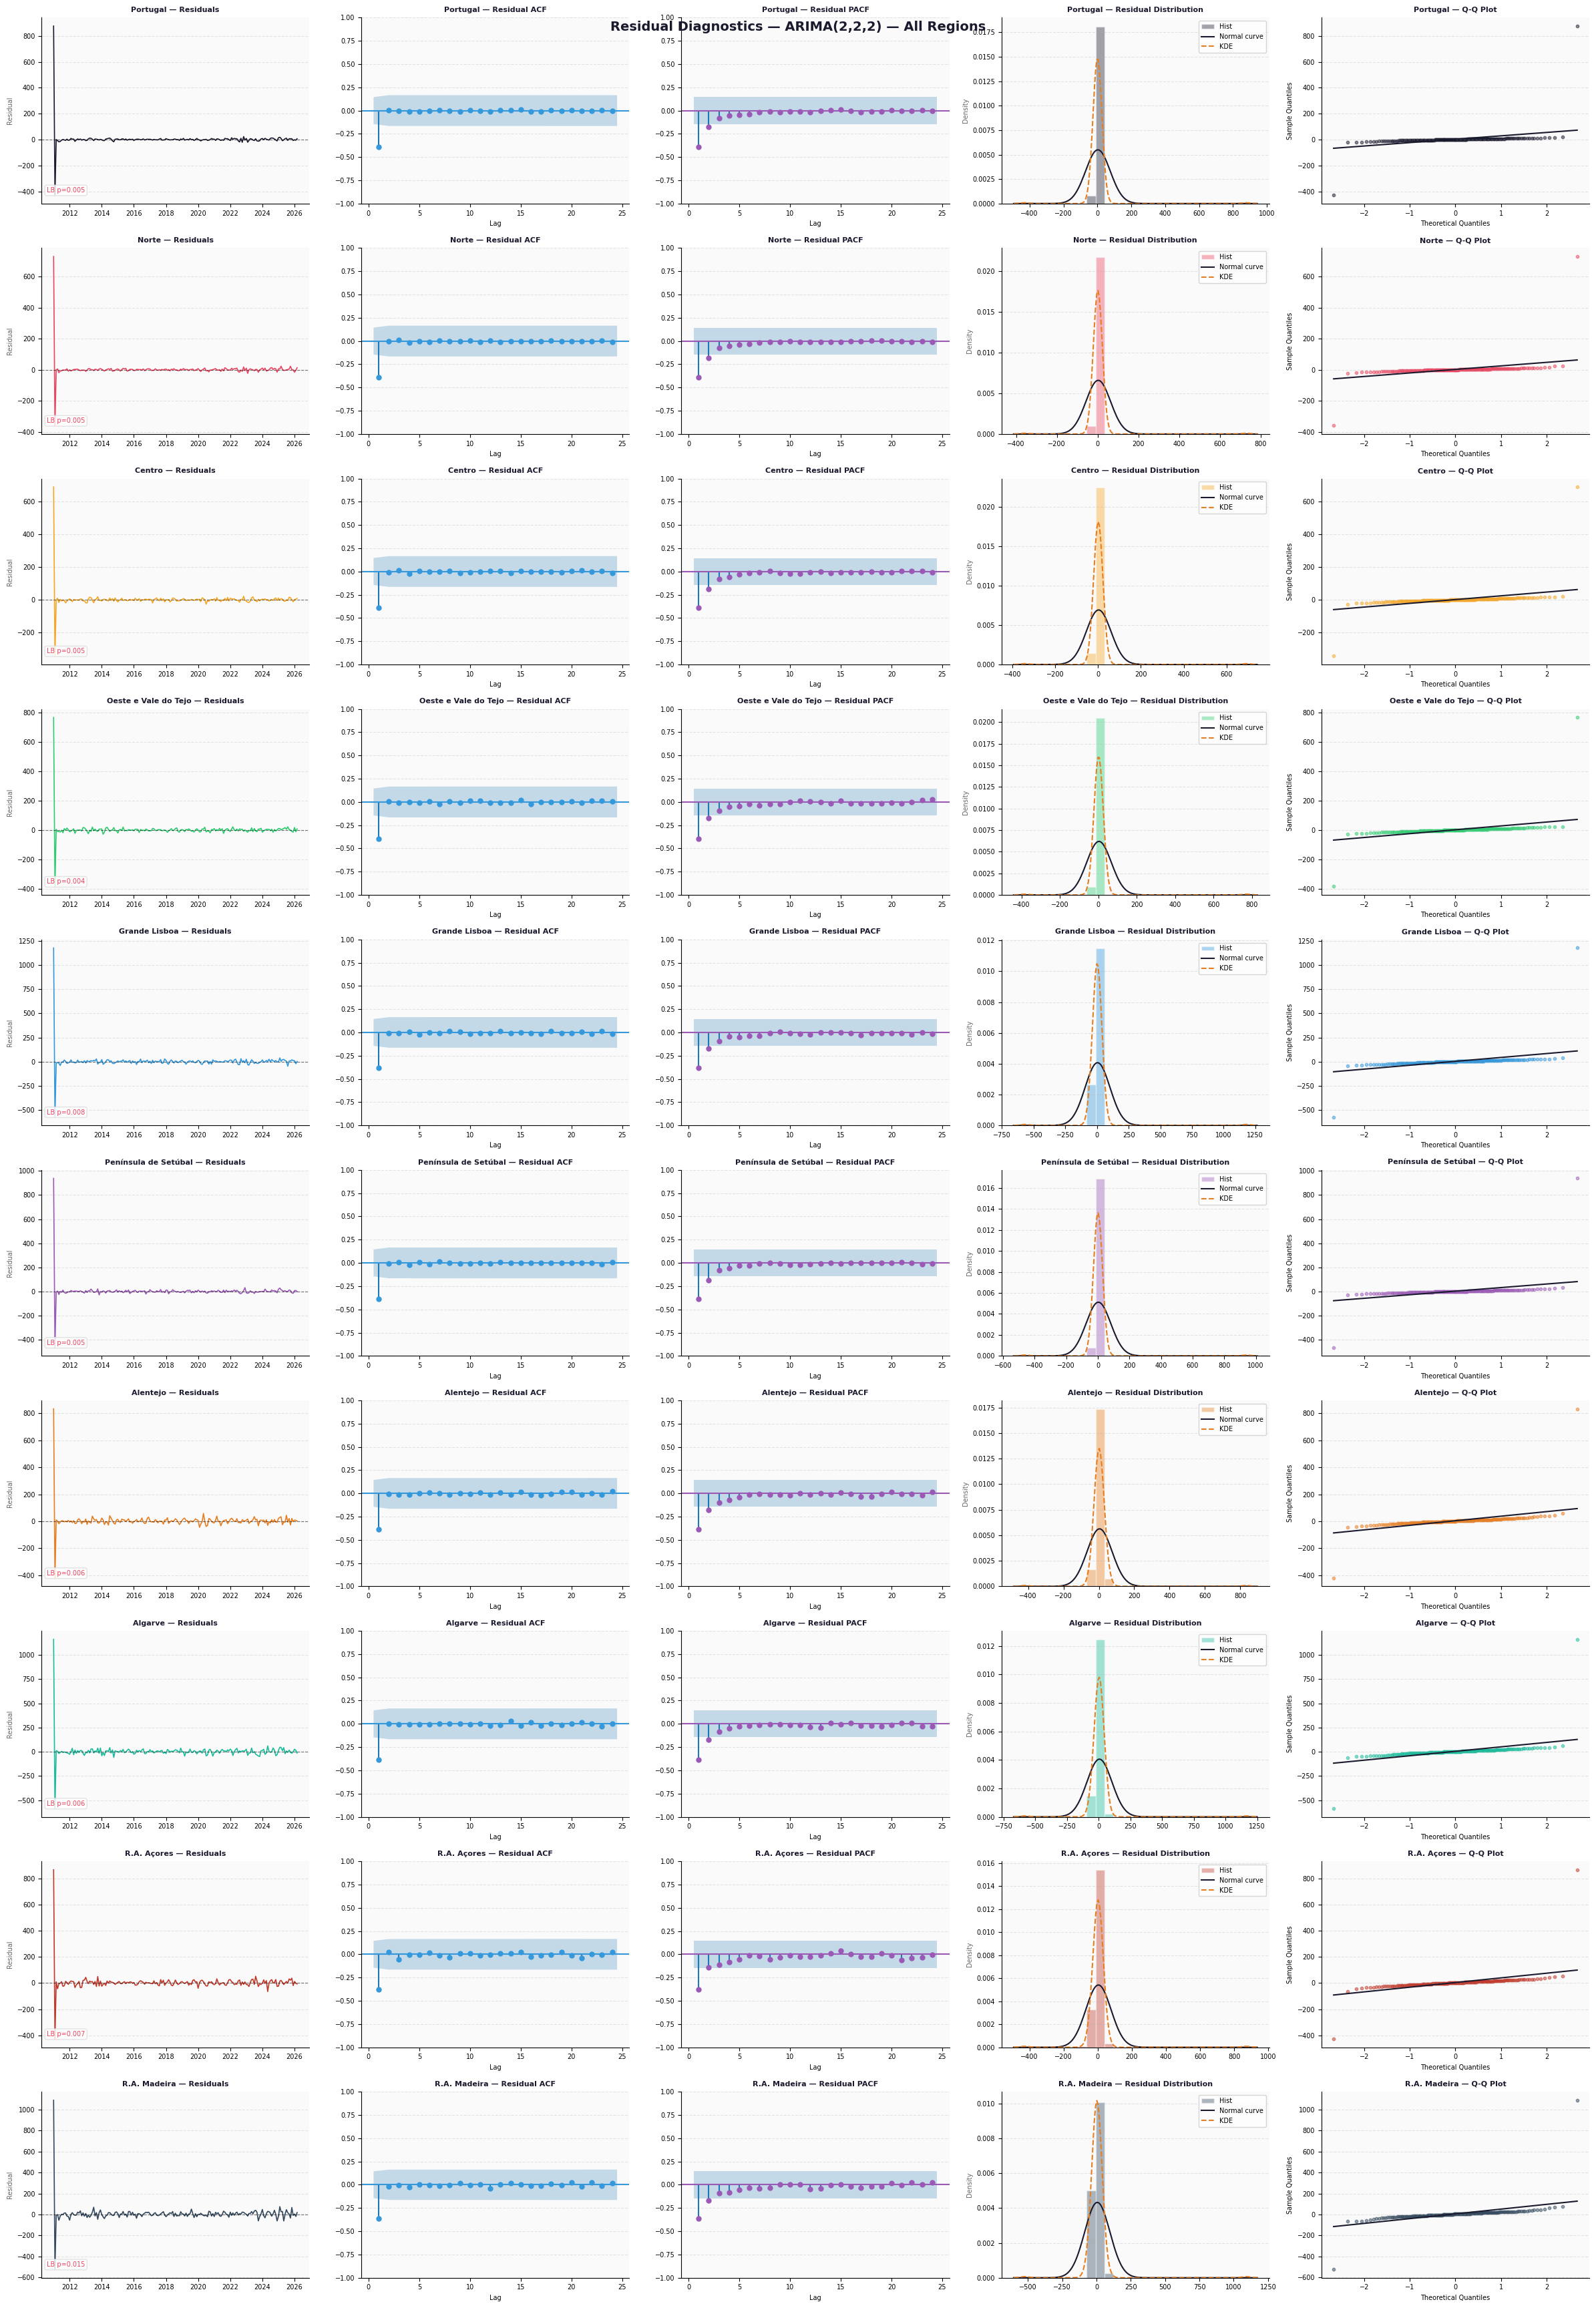


Residual diagnostics plot saved as residual_diagnostics.png


In [14]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import warnings
from statsmodels.stats.diagnostic import acorr_ljungbox
# Added plot_pacf to the imports
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# LJUNG-BOX TEST — ALL REGIONS
# ─────────────────────────────────────────────
print("=" * 70)
print("LJUNG-BOX TEST ON RESIDUALS (H0: residuals are white noise)")
print("=" * 70)
print(f"{'Region':<30} {'Lag 12 stat':<15} {'Lag 12 p':<12} {'Lag 24 stat':<15} {'Lag 24 p':<12} {'Result'}")
print("-" * 70)

lb_results = {}
for col in df.columns:
    resid = fitted_models[col].resid.dropna()
    lb12 = acorr_ljungbox(resid, lags=[12], return_df=True)
    lb24 = acorr_ljungbox(resid, lags=[24], return_df=True)

    stat12 = lb12['lb_stat'].values[0]
    p12    = lb12['lb_pvalue'].values[0]
    stat24 = lb24['lb_stat'].values[0]
    p24    = lb24['lb_pvalue'].values[0]

    # Fail if either lag is significant
    result = "✅ White noise" if (p12 > 0.05 and p24 > 0.05) else "Autocorrelation"
    lb_results[col] = {'stat12': stat12, 'p12': p12,
                       'stat24': stat24, 'p24': p24, 'result': result}
    print(f"{short_names[col]:<30} {stat12:<15.4f} {p12:<12.4f} {stat24:<15.4f} {p24:<12.4f} {result}")

print("\nH0: residuals are independently distributed (white noise).")
print("Rejection at p < 0.05 indicates remaining autocorrelation in residuals.")

# ─────────────────────────────────────────────
# RESIDUAL DIAGNOSTIC PLOTS — ALL REGIONS
# ─────────────────────────────────────────────
# Expanded layout: Now 5 plots per row to accommodate PACF
# 1) Residuals over time (Time Plot)
# 2) ACF of residuals
# 3) PACF of residuals
# 4) Histogram with KDE + Normal curve
# 5) Q-Q plot

fig, axes = plt.subplots(len(df.columns), 5,
                         figsize=(24, len(df.columns) * 3.5))
fig.patch.set_facecolor('white')

for i, col in enumerate(df.columns):
    resid = fitted_models[col].resid.dropna()

    # ── 1. Residuals over time (Time Plot) ──
    ax1 = axes[i, 0]
    ax1.plot(resid.index, resid, color=colors[col], linewidth=1.2)
    ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax1.set_title(f'{short_names[col]} — Residuals', fontsize=8,
                  fontweight='bold', color='#1a1a2e')
    ax1.set_ylabel('Residual', fontsize=7, color='#666')

    # Annotate Ljung-Box result
    p12 = lb_results[col]['p12']
    color_lb = '#2ecc71' if lb_results[col]['result'] == "White noise" else '#e94560'
    ax1.annotate(f"LB p={p12:.3f}", xy=(0.02, 0.06),
                  xycoords='axes fraction', fontsize=7,
                  color=color_lb,
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                            edgecolor='#ddd', alpha=0.8))

    # ── 2. ACF of residuals ──
    ax2 = axes[i, 1]
    plot_acf(resid, ax=ax2, lags=24, color='#3498db', zero=False)
    ax2.set_title(f'{short_names[col]} — Residual ACF', fontsize=8,
                  fontweight='bold', color='#1a1a2e')
    ax2.set_xlabel('Lag', fontsize=7)

    # ── 3. PACF of residuals (ADDED) ──
    ax3 = axes[i, 2]
    plot_pacf(resid, ax=ax3, lags=24, color='#9b59b6', zero=False)
    ax3.set_title(f'{short_names[col]} — Residual PACF', fontsize=8,
                  fontweight='bold', color='#1a1a2e')
    ax3.set_xlabel('Lag', fontsize=7)

    # ── 4. Histogram + KDE + Normal curve (UPDATED) ──
    ax4 = axes[i, 3]
    ax4.hist(resid, bins=25, color=colors[col], alpha=0.4,
              edgecolor='white', density=True, label='Hist')
    xmin, xmax = ax4.get_xlim()
    x = np.linspace(xmin, xmax, 200)
    mu, std = resid.mean(), resid.std()
    
    # Theoretical Gaussian curve
    ax4.plot(x, stats.norm.pdf(x, mu, std),
              color='#1a1a2e', linewidth=1.5, label='Normal curve')
    
    # Empirical Non-Parametric Kernel Density Estimation line (ADDED)
    kde = stats.gaussian_kde(resid)
    ax4.plot(x, kde(x), color='#e67e22', linewidth=1.5, 
              linestyle='--', label='KDE')
              
    ax4.set_title(f'{short_names[col]} — Residual Distribution', fontsize=8,
                  fontweight='bold', color='#1a1a2e')
    ax4.set_ylabel('Density', fontsize=7, color='#666')
    ax4.legend(fontsize=7)

    # ── 5. Q-Q plot ──
    ax5 = axes[i, 4]
    (osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
    ax5.scatter(osm, osr, color=colors[col], alpha=0.5, s=10)
    ax5.plot(osm, slope * np.array(osm) + intercept,
              color='#1a1a2e', linewidth=1.5)
    ax5.set_title(f'{short_names[col]} — Q-Q Plot', fontsize=8,
                  fontweight='bold', color='#1a1a2e')
    ax5.set_xlabel('Theoretical Quantiles', fontsize=7)
    ax5.set_ylabel('Sample Quantiles', fontsize=7)

    # Style all axes across the 5 subplots
    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.set_facecolor('#fafafa')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=7)

fig.suptitle('Residual Diagnostics — ARIMA(2,2,2) — All Regions',
             fontsize=14, fontweight='bold', color='#1a1a2e')
plt.tight_layout()
plt.savefig('residual_diagnostics.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("\nResidual diagnostics plot saved as residual_diagnostics.png")

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# d=1 regular orders + seasonal candidates
regular_orders  = [(0,1,1), (0,1,2), (1,1,1), (1,1,2), (2,1,1), (2,1,2)]
seasonal_orders = [(1,0,0,12), (0,0,1,12), (1,0,1,12),
                   (0,1,0,12), (1,1,0,12), (0,1,1,12)]

results_sarima_d1 = {}

for col in df.columns:
    print(f"\n{'='*95}")
    print(f"{short_names[col]}")
    print(f"{'='*95}")
    print(f"{'Order':<15} {'Seasonal':<18} {'AIC':<10} {'BIC':<10} {'LB p12':<10} {'LB p24':<10} {'Diag'}")
    print("-" * 95)

    best_aic = float('inf')
    region_results = []

    for r_order in regular_orders:
        for s_order in seasonal_orders:
            try:
                model = SARIMAX(df[col],
                                order=r_order,
                                seasonal_order=s_order).fit(disp=False)
                resid = model.resid.dropna()
                lb12 = acorr_ljungbox(resid, lags=[12],
                                      return_df=True)['lb_pvalue'].values[0]
                lb24 = acorr_ljungbox(resid, lags=[24],
                                      return_df=True)['lb_pvalue'].values[0]
                lb_ok = lb12 > 0.05 and lb24 > 0.05
                diag  = "✅ Pass" if lb_ok else "❌ Fail"

                if model.aic < best_aic:
                    best_aic = model.aic

                region_results.append({
                    'r_order': r_order, 's_order': s_order,
                    'aic': model.aic, 'bic': model.bic,
                    'lb12': lb12, 'lb24': lb24, 'lb_ok': lb_ok
                })

                print(f"{str(r_order):<15} {str(s_order):<18} {model.aic:<10.1f} "
                      f"{model.bic:<10.1f} {lb12:<10.4f} {lb24:<10.4f} {diag}")

            except:
                print(f"{str(r_order):<15} {str(s_order):<18} Failed to converge")

    # Best by AIC
    best_by_aic = min(region_results, key=lambda x: x['aic'])

    # Best passing diagnostics
    passing = [r for r in region_results if r['lb_ok']]
    best_passing = min(passing, key=lambda x: x['aic']) if passing else None

    print(f"\n→ Best AIC:           SARIMA{best_by_aic['r_order']}{best_by_aic['s_order']}"
          f"  AIC={best_by_aic['aic']:.1f}  Diag={'✅' if best_by_aic['lb_ok'] else '❌'}")
    if best_passing:
        print(f"→ Best AIC + ✅ Diag: SARIMA{best_passing['r_order']}{best_passing['s_order']}"
              f"  AIC={best_passing['aic']:.1f}")
    else:
        print(f"→ No model passed diagnostics")

    results_sarima_d1[col] = {
        'best_aic': best_by_aic,
        'best_passing': best_passing,
        'all': region_results
    }

# ─────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────
print(f"\n\n{'='*95}")
print("SUMMARY — BEST SARIMA (d=1) PER REGION")
print(f"{'='*95}")
print(f"{'Region':<30} {'Best AIC Model':<35} {'AIC':<10} {'Diag':<8} {'Best Passing':<35} {'AIC'}")
print("-" * 95)

for col in df.columns:
    ba = results_sarima_d1[col]['best_aic']
    bp = results_sarima_d1[col]['best_passing']
    ba_str = f"SARIMA{ba['r_order']}{ba['s_order']}"
    bp_str = f"SARIMA{bp['r_order']}{bp['s_order']}" if bp else "None"
    bp_aic = f"{bp['aic']:.1f}" if bp else "—"
    diag = "✅" if ba['lb_ok'] else "❌"
    print(f"{short_names[col]:<30} {ba_str:<35} {ba['aic']:<10.1f} {diag:<8} {bp_str:<35} {bp_aic}")

# Reference comparison
print(f"\n{'='*60}")
print("REFERENCE — ARIMA(2,2,2) AIC")
print(f"{'='*60}")
for col in df.columns:
    print(f"{short_names[col]:<30} AIC={fitted_models[col].aic:.1f}")


Portugal
Order           Seasonal           AIC        BIC        LB p12     LB p24     Diag
-----------------------------------------------------------------------------------------------
(0, 1, 1)       (1, 0, 0, 12)      1327.7     1337.4     1.0000     1.0000     ✅ Pass
(0, 1, 1)       (0, 0, 1, 12)      1340.8     1350.4     1.0000     1.0000     ✅ Pass
(0, 1, 1)       (1, 0, 1, 12)      1315.1     1328.0     1.0000     1.0000     ✅ Pass
(0, 1, 1)       (0, 1, 0, 12)      1265.4     1271.7     0.0012     0.1148     ❌ Fail
(0, 1, 1)       (1, 1, 0, 12)      1243.8     1253.2     0.0014     0.1277     ❌ Fail
(0, 1, 1)       (0, 1, 1, 12)      1228.9     1238.3     0.0015     0.1298     ❌ Fail
(0, 1, 2)       (1, 0, 0, 12)      1255.2     1268.0     1.0000     1.0000     ✅ Pass
(0, 1, 2)       (0, 0, 1, 12)      1255.2     1268.0     1.0000     1.0000     ✅ Pass
(0, 1, 2)       (1, 0, 1, 12)      1250.3     1266.3     1.0000     1.0000     ✅ Pass
(0, 1, 2)       (0, 1, 0, 12)      1

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# d=1 regular orders + seasonal candidates
regular_orders  = [(0,1,1), (0,1,2), (1,1,1), (1,1,2), (2,1,1), (2,1,2)]
seasonal_orders = [(1,0,0,12), (0,0,1,12), (1,0,1,12),
                   (0,1,0,12), (1,1,0,12), (0,1,1,12)]

results_sarima_d1 = {}

for col in df.columns:
    print(f"\n{'='*95}")
    print(f"{short_names[col]}")
    print(f"{'='*95}")
    print(f"{'Order':<15} {'Seasonal':<18} {'AIC':<10} {'BIC':<10} {'LB p12':<10} {'LB p24':<10} {'Diag'}")
    print("-" * 95)

    region_results = []

    for r_order in regular_orders:
        for s_order in seasonal_orders:
            try:
                model = SARIMAX(df[col],
                                order=r_order,
                                seasonal_order=s_order).fit(disp=False)
                resid = model.resid.dropna()
                lb12 = acorr_ljungbox(resid, lags=[12],
                                      return_df=True)['lb_pvalue'].values[0]
                lb24 = acorr_ljungbox(resid, lags=[24],
                                      return_df=True)['lb_pvalue'].values[0]
                lb_ok = lb12 > 0.05 and lb24 > 0.05
                diag  = "✅ Pass" if lb_ok else "❌ Fail"

                region_results.append({
                    'r_order': r_order, 's_order': s_order,
                    'aic': model.aic, 'bic': model.bic,
                    'lb12': lb12, 'lb24': lb24, 'lb_ok': lb_ok
                })

                print(f"{str(r_order):<15} {str(s_order):<18} {model.aic:<10.1f} "
                      f"{model.bic:<10.1f} {lb12:<10.4f} {lb24:<10.4f} {diag}")

            except:
                print(f"{str(r_order):<15} {str(s_order):<18} Failed to converge")

    # 1. Unconditional Optimizations (Absolute baselines)
    best_uncond_aic = min(region_results, key=lambda x: x['aic'])
    best_uncond_bic = min(region_results, key=lambda x: x['bic'])

    # Filter for candidates that successfully passed diagnostics
    passing_models = [r for r in region_results if r['lb_ok']]
    
    # 2. Conditional Optimizations (Passing models only)
    best_passing_aic = min(passing_models, key=lambda x: x['aic']) if passing_models else None
    best_passing_bic = min(passing_models, key=lambda x: x['bic']) if passing_models else None

    # Print region console diagnostic log
    print(f"\n→ Best Unconditional AIC: SARIMA{best_uncond_aic['r_order']}{best_uncond_aic['s_order']} (AIC={best_uncond_aic['aic']:.1f}, Diag={'✅' if best_uncond_aic['lb_ok'] else '❌'})")
    print(f"→ Best Unconditional BIC: SARIMA{best_uncond_bic['r_order']}{best_uncond_bic['s_order']} (BIC={best_uncond_bic['bic']:.1f}, Diag={'✅' if best_uncond_bic['lb_ok'] else '❌'})")
    if best_passing_aic:
        print(f"→ Best Passing AIC Model: SARIMA{best_passing_aic['r_order']}{best_passing_aic['s_order']} (AIC={best_passing_aic['aic']:.1f})")
    if best_passing_bic:
        print(f"→ Best Passing BIC Model: SARIMA{best_passing_bic['r_order']}{best_passing_bic['s_order']} (BIC={best_passing_bic['bic']:.1f})")

    results_sarima_d1[col] = {
        'best_uncond_aic': best_uncond_aic,
        'best_uncond_bic': best_uncond_bic,
        'best_passing_aic': best_passing_aic,
        'best_passing_bic': best_passing_bic,
        'all': region_results
    }

# ─────────────────────────────────────────────
# COMPREHENSIVE SELECTION SUMMARY TABLE
# ─────────────────────────────────────────────
# Set column formatting widths
w_name = 24
w_mod  = 20
w_val  = 8
w_dg   = 6

# Construct header layout
header = (f"{'Region':<{w_name}} "
          f"{'Uncond AIC':<{w_mod}} {'AIC':<{w_val}} {'Diag':<{w_dg}} "
          f"{'Uncond BIC':<{w_mod}} {'BIC':<{w_val}} {'Diag':<{w_dg}} "
          f"{'Passing AIC':<{w_mod}} {'AIC':<{w_val}} "
          f"{'Passing BIC':<{w_mod}} {'BIC'}")

table_width = len(header) + 5
print(f"\n\n{'='*table_width}")
print("SUMMARY — MODEL OPTIMIZATION FRAMEWORK PER REGION")
print(f"{'='*table_width}")
print(header)
print("-" * table_width)

for col in df.columns:
    r_res = results_sarima_d1[col]
    ua = r_res['best_uncond_aic']
    ub = r_res['best_uncond_bic']
    pa = r_res['best_passing_aic']
    pb = r_res['best_passing_bic']
    
    # Helper to convert layout tuple representations to standard string notations (p,d,q)(P,D,Q)
    fmt_str = lambda x: f"({x['r_order'][0]},{x['r_order'][1]},{x['r_order'][2]})({x['s_order'][0]},{x['s_order'][1]},{x['s_order'][2]})" if x else "None"
    
    # Format strings and metrics
    ua_mod = fmt_str(ua)
    ua_dg  = "✅" if ua['lb_ok'] else "❌"
    
    ub_mod = fmt_str(ub)
    ub_dg  = "✅" if ub['lb_ok'] else "❌"
    
    pa_mod = fmt_str(pa)
    pa_val = f"{pa['aic']:.1f}" if pa else "—"
    
    pb_mod = fmt_str(pb)
    pb_val = f"{pb['bic']:.1f}" if pb else "—"

    print(f"{short_names[col]:<{w_name}} "
          f"{ua_mod:<{w_mod}} {ua['aic']:<{w_val}.1f} {ua_dg:<{w_dg}} "
          f"{ub_mod:<{w_mod}} {ub['bic']:<{w_val}.1f} {ub_dg:<{w_dg}} "
          f"{pa_mod:<{w_mod}} {pa_val:<{w_val}} "
          f"{pb_mod:<{w_mod}} {pb_val}")

print("=" * table_width)
print("Note: Models indexed as (p,d,q)(P,D,Q) with s=12 implied. White noise status validated via Ljung-Box test criteria.")


Portugal
Order           Seasonal           AIC        BIC        LB p12     LB p24     Diag
-----------------------------------------------------------------------------------------------
(0, 1, 1)       (1, 0, 0, 12)      1327.7     1337.4     1.0000     1.0000     ✅ Pass
(0, 1, 1)       (0, 0, 1, 12)      1340.8     1350.4     1.0000     1.0000     ✅ Pass
(0, 1, 1)       (1, 0, 1, 12)      1315.1     1328.0     1.0000     1.0000     ✅ Pass
(0, 1, 1)       (0, 1, 0, 12)      1265.4     1271.7     0.0012     0.1148     ❌ Fail
(0, 1, 1)       (1, 1, 0, 12)      1243.8     1253.2     0.0014     0.1277     ❌ Fail
(0, 1, 1)       (0, 1, 1, 12)      1228.9     1238.3     0.0015     0.1298     ❌ Fail
(0, 1, 2)       (1, 0, 0, 12)      1255.2     1268.0     1.0000     1.0000     ✅ Pass
(0, 1, 2)       (0, 0, 1, 12)      1255.2     1268.0     1.0000     1.0000     ✅ Pass
(0, 1, 2)       (1, 0, 1, 12)      1250.3     1266.3     1.0000     1.0000     ✅ Pass
(0, 1, 2)       (0, 1, 0, 12)      1

Region                         Model                                    AIC          BIC
------------------------------------------------------------------------------------------
Portugal                       SARIMA(1, 1, 2)(0, 0, 1, 12)             1248.7       1264.7
Norte                          SARIMA(1, 1, 2)(0, 0, 1, 12)             1231.5       1247.5
Centro                         SARIMA(1, 1, 2)(0, 0, 1, 12)             1264.7       1280.8
Oeste e Vale do Tejo           SARIMA(1, 1, 1)(0, 0, 1, 12)             1353.4       1366.2
Grande Lisboa                  SARIMA(2, 1, 1)(1, 0, 1, 12)             1518.6       1537.9
Península de Setúbal           SARIMA(1, 1, 2)(0, 0, 1, 12)             1337.1       1353.2
Alentejo                       SARIMA(2, 1, 2)(1, 0, 0, 12)             1512.5       1531.7
Algarve                        SARIMA(2, 1, 2)(1, 0, 1, 12)             1620.8       1643.2
R.A. Açores                    SARIMA(2, 1, 2)(0, 0, 1, 12)             1552.4      

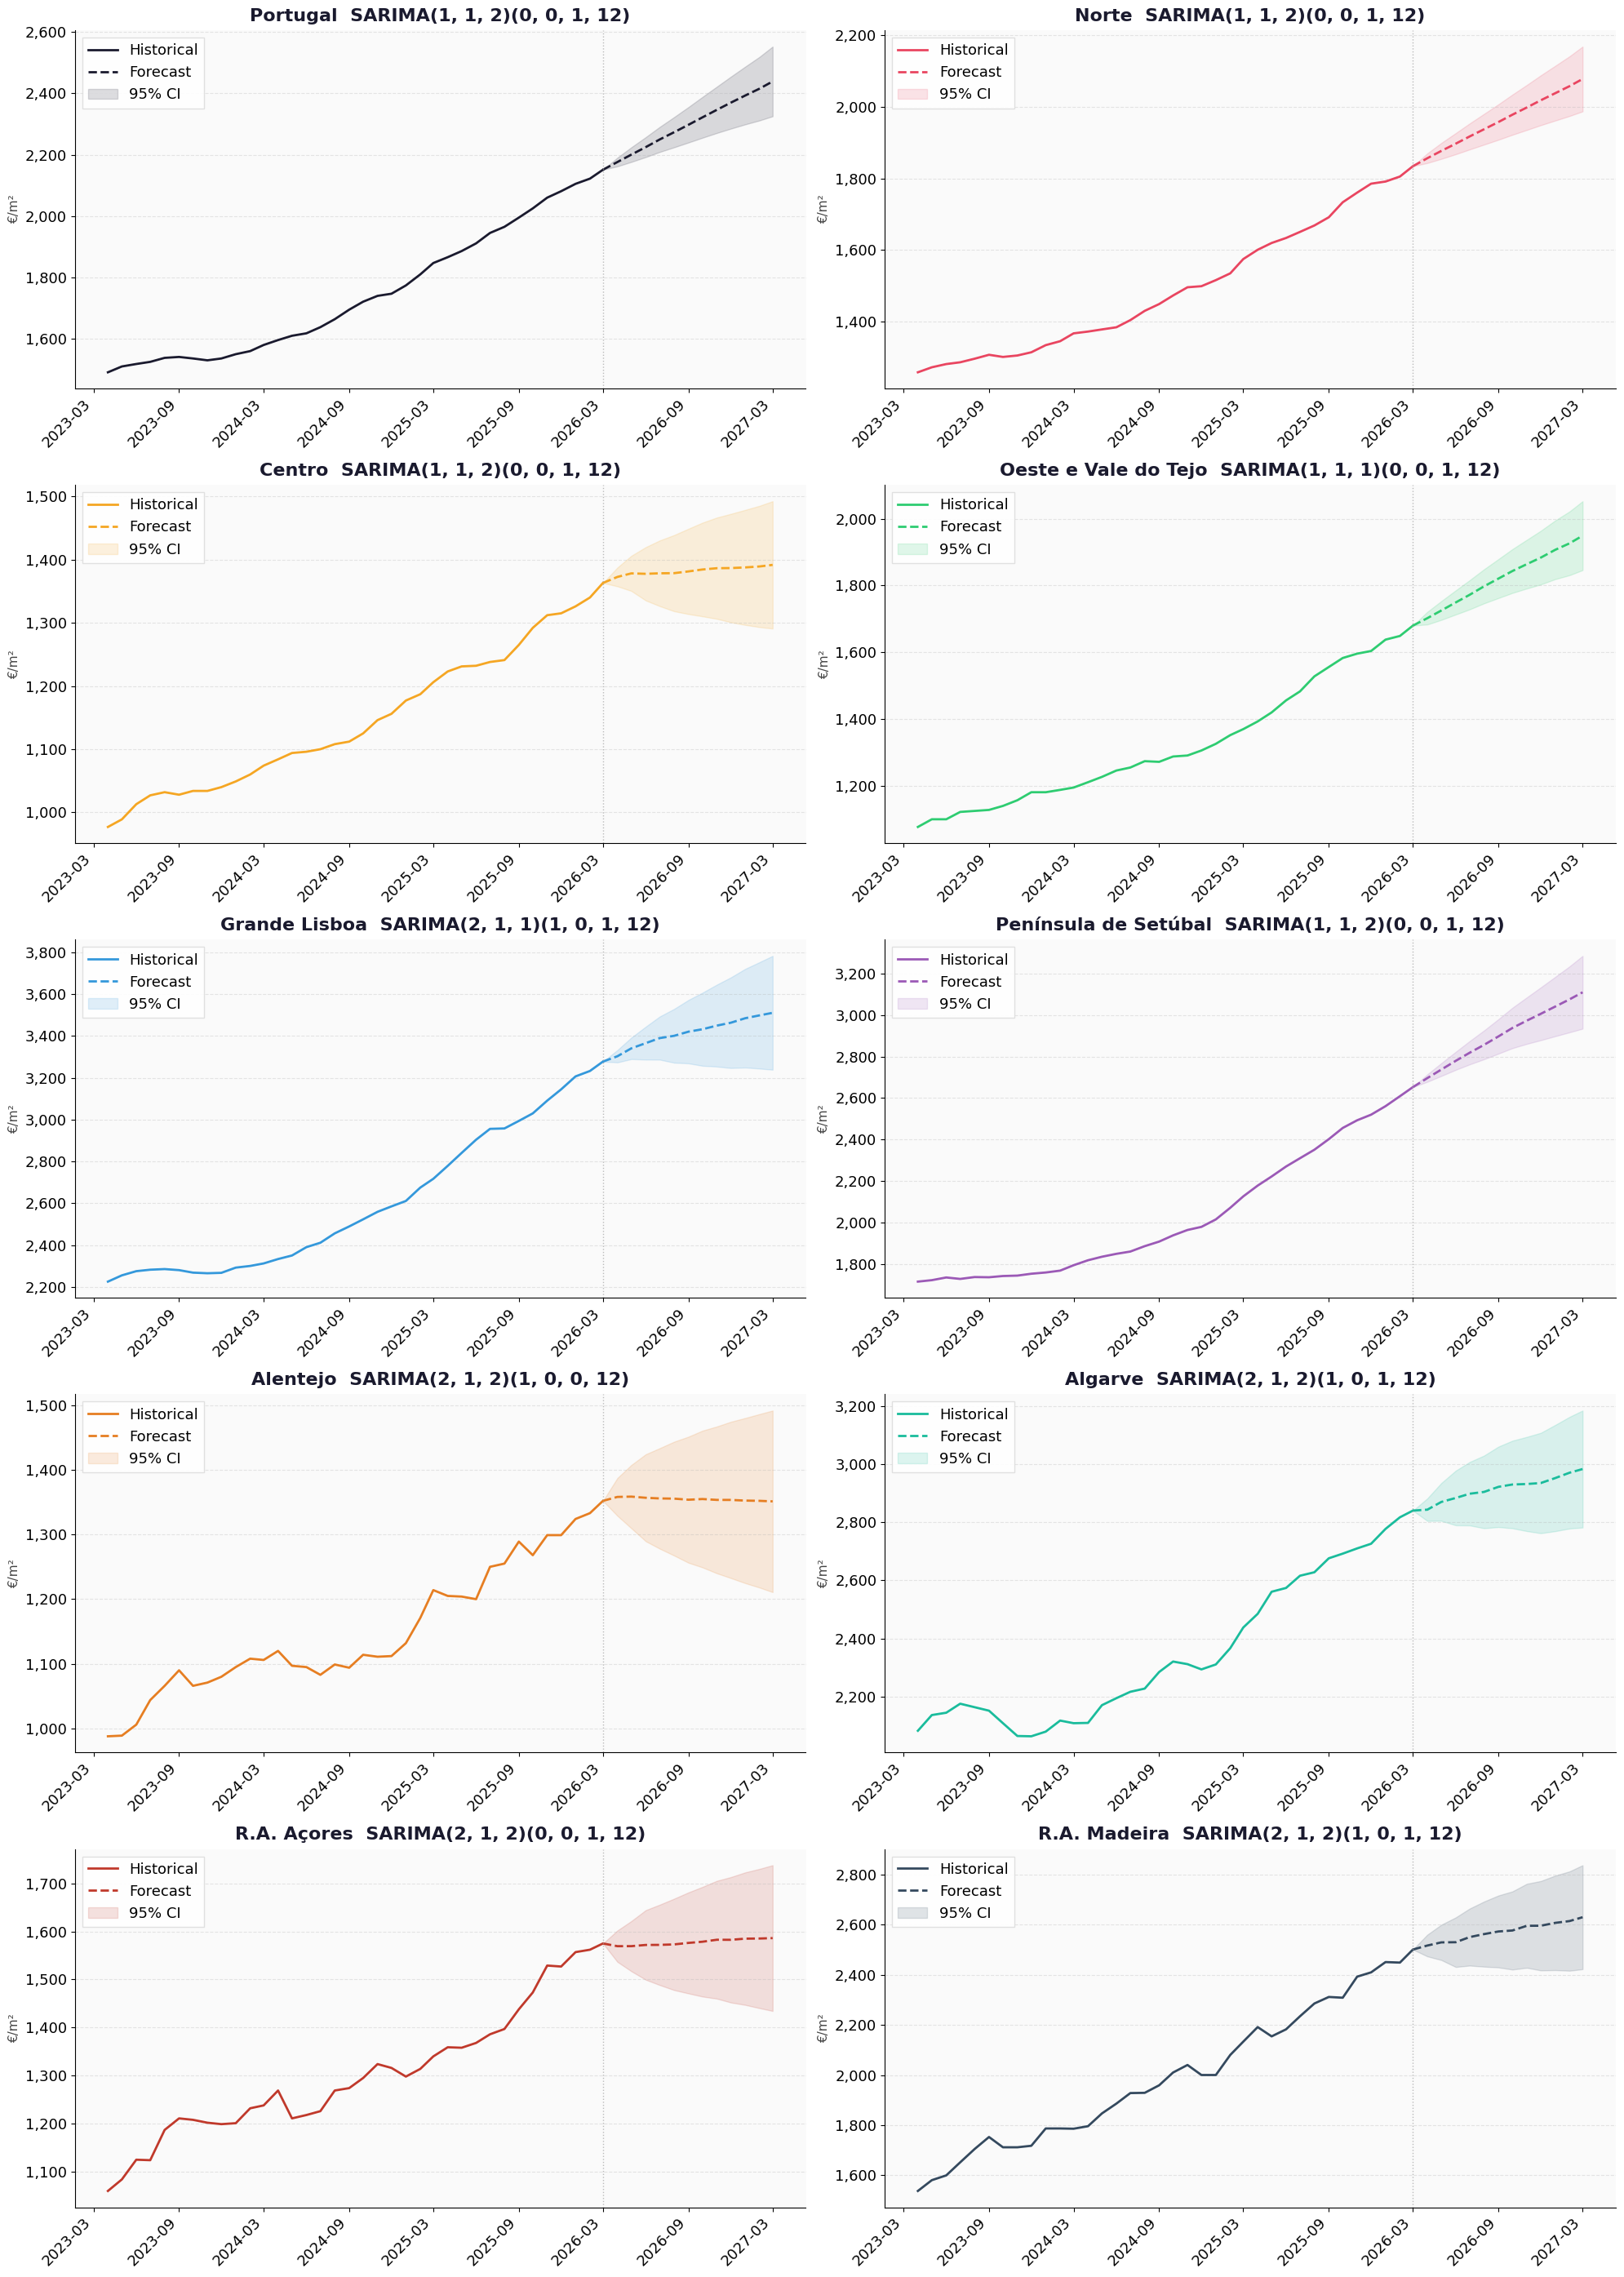


FORECAST TABLE — SARIMA (d=1, best passing) — CURRENT + NEXT 12 MONTHS (€/m²)
         Portugal  Norte  Centro  Oeste e Vale do Tejo  Grande Lisboa  Península de Setúbal  Alentejo  Algarve  R.A. Açores  R.A. Madeira
Month                                                                                                                                    
2026-03      2151   1834    1363                  1680           3278                  2653      1352     2840         1575          2500
2026-04      2176   1856    1373                  1702           3303                  2696      1358     2843         1569          2516
2026-05      2200   1877    1378                  1725           3341                  2737      1359     2870         1569          2528
2026-06      2225   1897    1377                  1749           3366                  2780      1357     2883         1572          2529
2026-07      2250   1917    1378                  1772           3390                  2819  

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# BEST PASSING MODELS FROM RESULTS TABLE
# ─────────────────────────────────────────────
best_passing_specs = {
    'Portugal':                     {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Norte':                        {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Centro':                       {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Oeste e Vale do Tejo':         {'r_order': (1,1,1), 's_order': (0,0,1,12)},
    'Grande Lisboa':                {'r_order': (2,1,1), 's_order': (1,0,1,12)},
    'Península de Setúbal':         {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Alentejo':                     {'r_order': (2,1,2), 's_order': (1,0,0,12)},
    'Algarve':                      {'r_order': (2,1,2), 's_order': (1,0,1,12)},
    'Região Autónoma dos Açores':   {'r_order': (2,1,2), 's_order': (0,0,1,12)},
    'Região Autónoma da Madeira':   {'r_order': (2,1,2), 's_order': (1,0,1,12)},
}

# ─────────────────────────────────────────────
# FIT MODELS
# ─────────────────────────────────────────────
best_passing_models = {}

print(f"{'Region':<30} {'Model':<40} {'AIC':<12} {'BIC'}")
print("-" * 90)

for col in df.columns:
    spec    = best_passing_specs[col]
    r_order = spec['r_order']
    s_order = spec['s_order']

    model = SARIMAX(df[col],
                    order=r_order,
                    seasonal_order=s_order).fit(disp=False)

    best_passing_models[col] = {
        'model':   model,
        'r_order': r_order,
        's_order': s_order,
    }

    model_str = f"SARIMA{r_order}{s_order}"
    print(f"{short_names[col]:<30} {model_str:<40} {model.aic:<12.1f} {model.bic:.1f}")

# ─────────────────────────────────────────────
# FORECAST 12 MONTHS AHEAD
# ─────────────────────────────────────────────
forecast_steps = 12

fig, axes = plt.subplots(5, 2, figsize=(20, 28))
fig.patch.set_facecolor('white')

for i, col in enumerate(df.columns):
    ax    = axes.flatten()[i]
    model = best_passing_models[col]['model']

    forecast      = model.get_forecast(steps=forecast_steps)
    forecast_mean = forecast.predicted_mean
    conf_int      = forecast.conf_int(alpha=0.05)

    # Connect last observed point to forecast line
    last_date = df[col].index[-1]
    last_val  = df[col].iloc[-1]
    forecast_mean_plot = pd.concat([
        pd.Series([last_val], index=[last_date]),
        forecast_mean
    ])
    conf_int_plot = pd.concat([
        pd.DataFrame([[last_val, last_val]], index=[last_date],
                     columns=conf_int.columns),
        conf_int
    ])

    history = df[col].iloc[-36:]

    ax.plot(history.index, history,
            color=colors[col], linewidth=2.0, label='Historical')
    ax.plot(forecast_mean_plot.index, forecast_mean_plot,
            color=colors[col], linewidth=2.0, linestyle='--', label='Forecast')
    ax.fill_between(conf_int_plot.index,
                    conf_int_plot.iloc[:, 0],
                    conf_int_plot.iloc[:, 1],
                    color=colors[col], alpha=0.15, label='95% CI')

    ax.axvline(last_date, color='#aaa', linewidth=1, linestyle=':', alpha=0.8)

    r_str = str(best_passing_models[col]['r_order'])
    s_str = str(best_passing_models[col]['s_order'])
    ax.set_title(f"{short_names[col]}  SARIMA{r_str}{s_str}",
                 fontsize=16, fontweight='bold', color='#1a1a2e', pad=8)
    ax.set_ylabel('€/m²', fontsize=11, color='#444')
    ax.set_facecolor('#fafafa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=13)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=13)
    ax.legend(fontsize=13, framealpha=0.9, edgecolor='#ddd', fancybox=False)

plt.tight_layout()
plt.savefig('forecast_sarima_best_passing.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

# ─────────────────────────────────────────────
# FORECAST VALUES TABLE
# ─────────────────────────────────────────────
print(f"\n{'='*65}")
print("FORECAST TABLE — SARIMA (d=1, best passing) — CURRENT + NEXT 12 MONTHS (€/m²)")
print(f"{'='*65}")

forecast_df = pd.DataFrame()

for col in df.columns:
    model         = best_passing_models[col]['model']
    forecast_mean = model.get_forecast(steps=forecast_steps).predicted_mean.round(0).astype(int)

    current = pd.Series(
        [int(df[col].iloc[-1])],
        index=[df[col].index[-1]],
        name=short_names[col]
    )
    full_series = pd.concat([current, forecast_mean.rename(short_names[col])])
    forecast_df[short_names[col]] = full_series

forecast_df.index = forecast_df.index.strftime('%Y-%m')
forecast_df.index.name = 'Month'

print(forecast_df.to_string())
forecast_df.to_csv('forecast_sarima_best_passing_12months.csv')
print("\nForecast saved to forecast_sarima_best_passing_12months.csv")

# ─────────────────────────────────────────────
# AIC COMPARISON — SARIMA vs ARIMA(2,2,2)
# ─────────────────────────────────────────────
print(f"\n{'='*80}")
print("AIC COMPARISON — SARIMA(d=1, best passing) vs ARIMA(2,2,2) — FULL SAMPLE")
print(f"{'='*80}")
print(f"{'Region':<30} {'ARIMA(2,2,2)':<15} {'SARIMA':<15} {'Δ AIC':<12} {'Winner'}")
print("-" * 80)

for col in df.columns:
    arima_aic  = fitted_models[col].aic
    sarima_aic = best_passing_models[col]['model'].aic
    diff       = sarima_aic - arima_aic
    winner     = "SARIMA ✅" if diff < -2 else "ARIMA" if diff > 2 else "Equivalent"
    print(f"{short_names[col]:<30} {arima_aic:<15.1f} {sarima_aic:<15.1f} {diff:<12.1f} {winner}")

LJUNG-BOX TEST ON RESIDUALS — SARIMA (d=1, best passing)
Region                         Lag 12 stat     Lag 12 p     Lag 24 stat     Lag 24 p     Result
----------------------------------------------------------------------
Portugal                       0.2478          1.0000       0.3527          1.0000       White noise
Norte                          0.2268          1.0000       0.3510          1.0000       White noise
Centro                         0.2630          1.0000       0.5566          1.0000       White noise
Oeste e Vale do Tejo           0.4368          1.0000       0.8339          1.0000       White noise
Grande Lisboa                  0.4260          1.0000       0.7370          1.0000       White noise
Península de Setúbal           0.3225          1.0000       0.4182          1.0000       White noise
Alentejo                       0.2218          1.0000       0.7061          1.0000       White noise
Algarve                        0.3356          1.0000       1.1353   

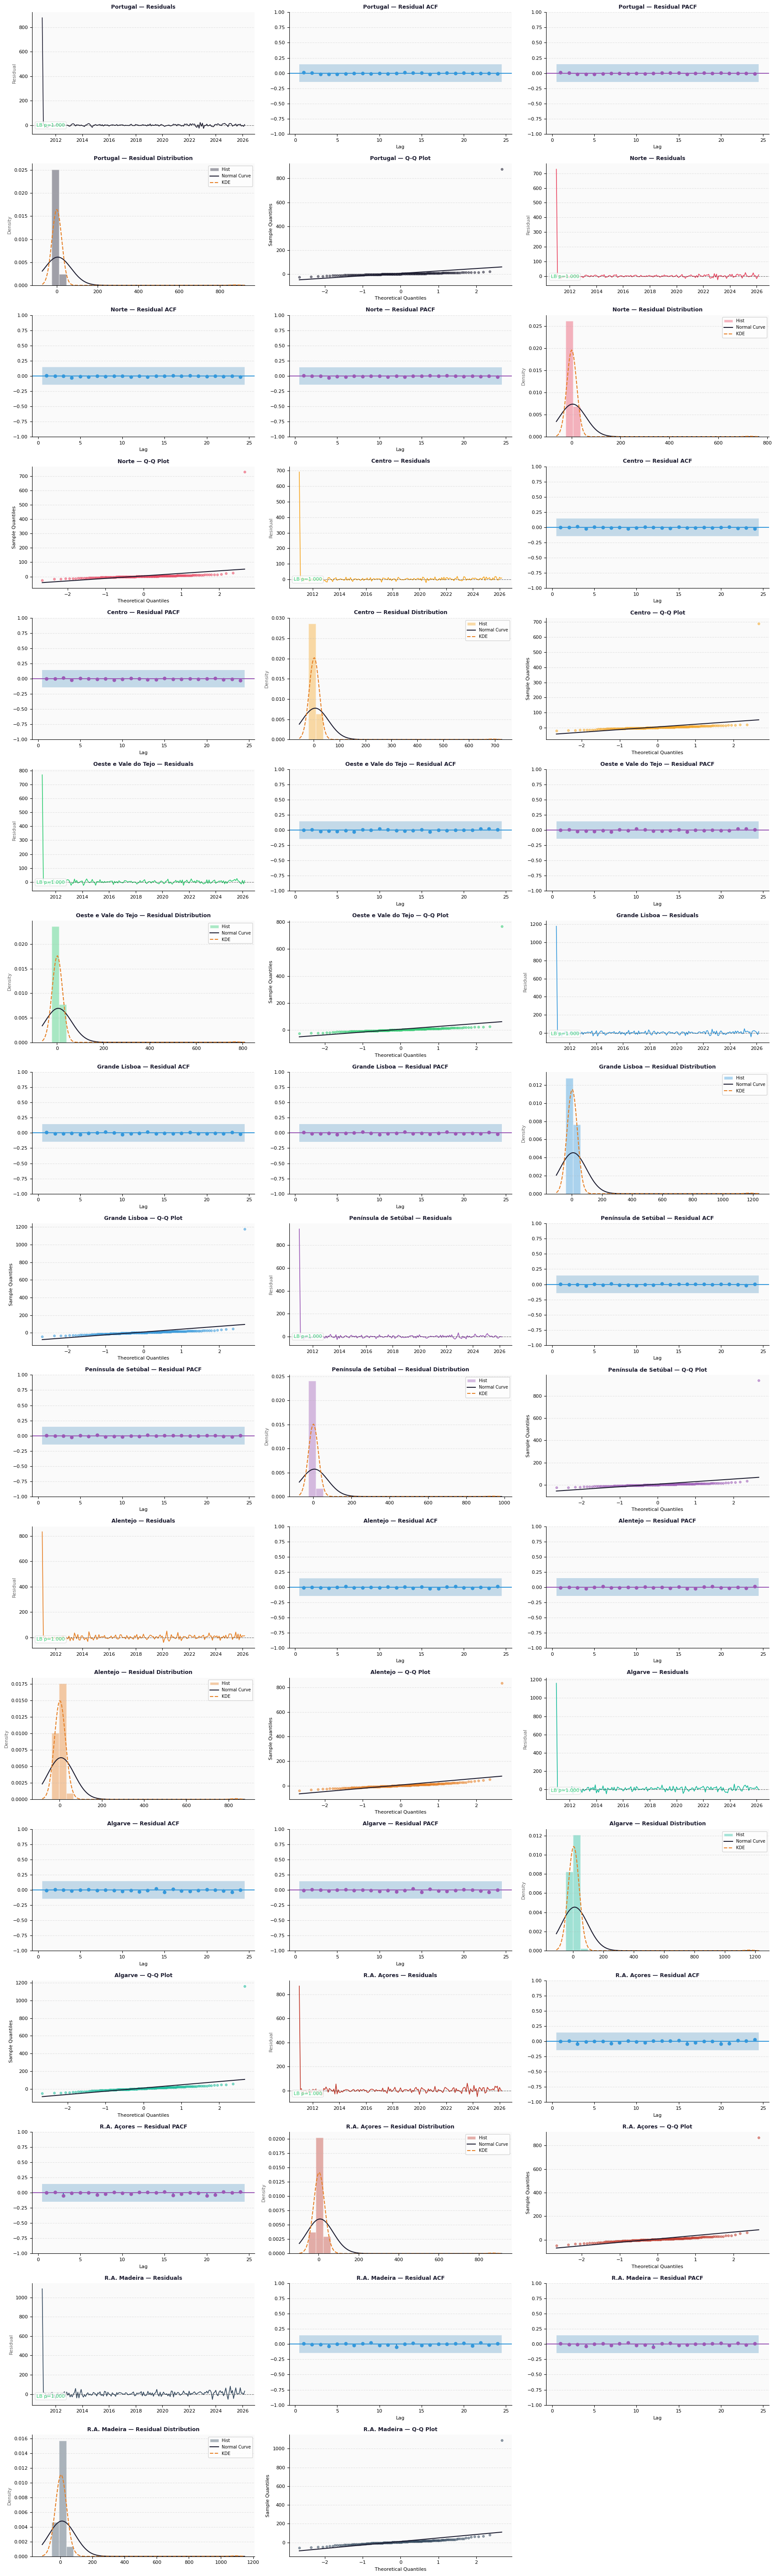


Residual diagnostics saved as residual_diagnostics_sarima.png


In [18]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import warnings
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# LJUNG-BOX TEST — ALL REGIONS
# ─────────────────────────────────────────────
print("=" * 70)
print("LJUNG-BOX TEST ON RESIDUALS — SARIMA (d=1, best passing)")
print("=" * 70)
print(f"{'Region':<30} {'Lag 12 stat':<15} {'Lag 12 p':<12} {'Lag 24 stat':<15} {'Lag 24 p':<12} {'Result'}")
print("-" * 70)

lb_results_sarima = {}
for col in df.columns:
    resid = best_passing_models[col]['model'].resid.dropna()  # ← changed
    lb12 = acorr_ljungbox(resid, lags=[12], return_df=True)
    lb24 = acorr_ljungbox(resid, lags=[24], return_df=True)

    stat12 = lb12['lb_stat'].values[0]
    p12    = lb12['lb_pvalue'].values[0]
    stat24 = lb24['lb_stat'].values[0]
    p24    = lb24['lb_pvalue'].values[0]

    result = "White noise" if (p12 > 0.05 and p24 > 0.05) else "Autocorrelation"
    lb_results_sarima[col] = {'stat12': stat12, 'p12': p12,
                               'stat24': stat24, 'p24': p24, 'result': result}
    print(f"{short_names[col]:<30} {stat12:<15.4f} {p12:<12.4f} {stat24:<15.4f} {p24:<12.4f} {result}")

print("\nH0: residuals are independently distributed (white noise).")
print("Rejection at p < 0.05 indicates remaining autocorrelation in residuals.")

# ─────────────────────────────────────────────
# RESIDUAL DIAGNOSTIC PLOTS — ALL REGIONS (3 PLOTS PER ROW)
# ─────────────────────────────────────────────
# 10 regions * 5 plots each = 50 total plots. At 3 plots per row, we need 17 rows.
plots_per_region = 5
total_plots = len(df.columns) * plots_per_region
ncols = 3
nrows = int(np.ceil(total_plots / ncols)) # 17 rows

# Increase figsize height to match the vertical expansion (17 rows * 3.5 = ~60)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
fig.patch.set_facecolor('white')

# Flatten axes for straightforward linear indexing
axes_flat = axes.flatten()

plot_idx = 0  # Counter to track active subplot position

for i, col in enumerate(df.columns):
    resid = best_passing_models[col]['model'].resid.dropna()

    # ── 1. Residuals over time ──
    ax1 = axes_flat[plot_idx]
    plot_idx += 1
    ax1.plot(resid.index, resid, color=colors[col], linewidth=1.2)
    ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax1.set_title(f'{short_names[col]} — Residuals', fontsize=9,
                  fontweight='bold', color='#1a1a2e')
    ax1.set_ylabel('Residual', fontsize=8, color='#666')

    p12 = lb_results_sarima[col]['p12']
    color_lb = '#2ecc71' if lb_results_sarima[col]['result'] == "White noise" else '#e94560'
    ax1.annotate(f"LB p={p12:.3f}", xy=(0.02, 0.06),
                  xycoords='axes fraction', fontsize=8,
                  color=color_lb,
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                            edgecolor='#ddd', alpha=0.8))

    # ── 2. ACF of residuals ──
    ax2 = axes_flat[plot_idx]
    plot_idx += 1
    plot_acf(resid, ax=ax2, lags=24, color='#3498db', zero=False)
    ax2.set_title(f'{short_names[col]} — Residual ACF', fontsize=9,
                  fontweight='bold', color='#1a1a2e')
    ax2.set_xlabel('Lag', fontsize=8)

    # ── 3. PACF of residuals ──
    ax3 = axes_flat[plot_idx]
    plot_idx += 1
    plot_pacf(resid, ax=ax3, lags=24, color='#9b59b6', zero=False)
    ax3.set_title(f'{short_names[col]} — Residual PACF', fontsize=9,
                  fontweight='bold', color='#1a1a2e')
    ax3.set_xlabel('Lag', fontsize=8)

    # ── 4. Histogram + KDE + Normal curve ──
    ax4 = axes_flat[plot_idx]
    plot_idx += 1
    ax4.hist(resid, bins=25, color=colors[col], alpha=0.4,
             edgecolor='white', density=True, label='Hist')
    xmin, xmax = ax4.get_xlim()
    x = np.linspace(xmin, xmax, 200)
    mu, std = resid.mean(), resid.std()
    ax4.plot(x, stats.norm.pdf(x, mu, std),
             color='#1a1a2e', linewidth=1.5, label='Normal Curve')
    kde = stats.gaussian_kde(resid)
    ax4.plot(x, kde(x), color='#e67e22', linewidth=1.5,
             linestyle='--', label='KDE')
    ax4.set_title(f'{short_names[col]} — Residual Distribution', fontsize=9,
                  fontweight='bold', color='#1a1a2e')
    ax4.set_ylabel('Density', fontsize=8, color='#666')
    ax4.legend(fontsize=7)

    # ── 5. Q-Q plot ──
    ax5 = axes_flat[plot_idx]
    plot_idx += 1
    (osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
    ax5.scatter(osm, osr, color=colors[col], alpha=0.5, s=12)
    ax5.plot(osm, slope * np.array(osm) + intercept,
             color='#1a1a2e', linewidth=1.5)
    ax5.set_title(f'{short_names[col]} — Q-Q Plot', fontsize=9,
                  fontweight='bold', color='#1a1a2e')
    ax5.set_xlabel('Theoretical Quantiles', fontsize=8)
    ax5.set_ylabel('Sample Quantiles', fontsize=8)

    # Apply general styling to the 5 processed subplots
    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.set_facecolor('#fafafa')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=8)

# ── Clean up unused subplots ──
# Because 50 total plots don't perfectly divide by 3 columns, the 17th row 
# will have 1 remaining unused canvas blank spot. We hide it here:
for idx in range(plot_idx, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.savefig('residual_diagnostics_sarima.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("\nResidual diagnostics saved as residual_diagnostics_sarima.png")

In [19]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# LOAD TARGET
# ─────────────────────────────────────────────
df = pd.read_csv('avaliacao_bancaria_total.csv',
                 index_col='date', parse_dates=True, encoding='latin-1').astype(float)
df = df.drop(columns=['Continente'], errors='ignore')

regions = df.columns.tolist()

# ─────────────────────────────────────────────
# LOAD INFLATION (monthly — no interpolation needed)
# ─────────────────────────────────────────────
inflation = pd.read_csv('inflation.csv',
                        index_col='date', parse_dates=True, encoding='latin-1').astype(float)
inflation = inflation[regions]  # keep only matching regions
inflation = inflation['2011-01-01':]

print(f"Inflation:    {inflation.index.min().strftime('%Y-%m')} to {inflation.index.max().strftime('%Y-%m')} — {len(inflation)} months — MONTHLY")
print(f"  NaNs per region:\n{inflation.isna().sum()}\n")

# ─────────────────────────────────────────────
# LOAD MORTGAGE (monthly, national → apply to all regions)
# ─────────────────────────────────────────────
mortgage_raw = pd.read_csv('mortgage_interest_rate.csv',
                           index_col='date', parse_dates=True, encoding='latin-1')
mortgage_raw = mortgage_raw['2011-01-01':]

# Replicate national rate across all regions
mortgage = pd.DataFrame(index=mortgage_raw.index)
for reg in regions:
    mortgage[reg] = mortgage_raw['Portugal']

print(f"Mortgage:     {mortgage.index.min().strftime('%Y-%m')} to {mortgage.index.max().strftime('%Y-%m')} — {len(mortgage)} months — MONTHLY (national rate applied to all regions)")

# ─────────────────────────────────────────────
# LOAD NEW HOUSES (quarterly → interpolate to monthly)
# ─────────────────────────────────────────────
new_houses_q = pd.read_csv('nr_new_houses.csv',
                            index_col='date', parse_dates=True, encoding='latin-1').astype(float)
new_houses_q = new_houses_q[regions]
new_houses_q = new_houses_q['2011-01-01':]

# Resample to monthly frequency then interpolate linearly between quarters
# This creates Feb and Mar values between Jan (Q1) and Apr (Q2) etc.
new_houses = new_houses_q.resample('MS').asfreq()
new_houses = new_houses.interpolate(method='linear')

print(f"New Houses:   {new_houses_q.index.min().strftime('%Y-%m')} to {new_houses_q.index.max().strftime('%Y-%m')} — {len(new_houses_q)} quarters → {len(new_houses)} months after interpolation — QUARTERLY→MONTHLY")
print(f"  NaNs per region:\n{new_houses.isna().sum()}\n")

# ─────────────────────────────────────────────
# LOAD UNEMPLOYMENT (quarterly → interpolate to monthly)
# ─────────────────────────────────────────────
unemploy_q = pd.read_csv('unemployment_rate.csv',
                          index_col='date', parse_dates=True, encoding='latin-1').astype(float)
unemploy_q = unemploy_q[regions]
unemploy_q = unemploy_q['2011-01-01':]

# Same interpolation as new houses
unemploy = unemploy_q.resample('MS').asfreq()
unemploy = unemploy.interpolate(method='linear')

print(f"Unemployment: {unemploy_q.index.min().strftime('%Y-%m')} to {unemploy_q.index.max().strftime('%Y-%m')} — {len(unemploy_q)} quarters → {len(unemploy)} months after interpolation — QUARTERLY→MONTHLY")
print(f"  NaNs per region:\n{unemploy.isna().sum()}\n")

# ─────────────────────────────────────────────
# SUMMARY — COMMON SAMPLE
# ─────────────────────────────────────────────
end_date = min(
    new_houses.index.max(),
    unemploy.index.max(),
    inflation.index.max(),
    mortgage.index.max(),
    df.index.max()
)

print(f"{'='*55}")
print(f"COMMON SAMPLE END DATE: {end_date.strftime('%Y-%m')}")
print(f"{'='*55}")
print(f"{'Variable':<20} {'Start':<12} {'End':<12} {'Freq'}")
print("-" * 55)
print(f"{'Target (price)':<20} {'2011-01':<12} {df.index.max().strftime('%Y-%m'):<12} Monthly")
print(f"{'Inflation':<20} {'2011-01':<12} {inflation.index.max().strftime('%Y-%m'):<12} Monthly")
print(f"{'Mortgage':<20} {'2011-01':<12} {mortgage.index.max().strftime('%Y-%m'):<12} Monthly")
print(f"{'New Houses':<20} {new_houses_q.index.min().strftime('%Y-%m'):<12} {new_houses_q.index.max().strftime('%Y-%m'):<12} Quarterly→Monthly")
print(f"{'Unemployment':<20} {unemploy_q.index.min().strftime('%Y-%m'):<12} {unemploy_q.index.max().strftime('%Y-%m'):<12} Quarterly→Monthly")

Inflation:    2011-01 to 2026-04 — 184 months — MONTHLY
  NaNs per region:
Portugal                        0
Norte                           0
Centro                          0
Oeste e Vale do Tejo          179
Grande Lisboa                   0
Península de Setúbal          179
Alentejo                        0
Algarve                         0
Região Autónoma dos Açores      0
Região Autónoma da Madeira      0
dtype: int64

Mortgage:     2011-01 to 2026-03 — 183 months — MONTHLY (national rate applied to all regions)
New Houses:   2011-01 to 2025-10 — 60 quarters → 178 months after interpolation — QUARTERLY→MONTHLY
  NaNs per region:
Portugal                      0
Norte                         0
Centro                        0
Oeste e Vale do Tejo          0
Grande Lisboa                 0
Península de Setúbal          0
Alentejo                      0
Algarve                       0
Região Autónoma dos Açores    0
Região Autónoma da Madeira    0
dtype: int64

Unemployment: 2011-01 t

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# GRID SEARCH PARAMETERS
# ─────────────────────────────────────────────
regular_orders  = [(0,1,1), (0,1,2), (1,1,1), (1,1,2), (2,1,1), (2,1,2)]
seasonal_orders = [(0,0,1,12), (1,0,0,12), (1,0,1,12),
                   (0,1,1,12), (1,1,0,12), (1,1,1,12)]

# Regions with incomplete inflation — use only 3 exog variables
no_inflation = ['Oeste e Vale do Tejo', 'Península de Setúbal']

sarimax_models  = {}
sarimax_results = {}

for col in df.columns:

    # ── Build exog ──
    if col in no_inflation:
        exog = pd.DataFrame({
            'mortgage':     mortgage[col],
            'new_houses':   new_houses[col],
            'unemployment': unemploy[col]
        })
        print(f"\n{short_names[col]} — using 3 exog variables (inflation excluded)")
    else:
        exog = pd.DataFrame({
            'inflation':    inflation[col],
            'mortgage':     mortgage[col],
            'new_houses':   new_houses[col],
            'unemployment': unemploy[col]
        })
        print(f"\n{short_names[col]} — using 4 exog variables")

    # ── Align on common dates ──
    y      = df[col]
    common = y.index.intersection(exog.index)
    common = common[common <= end_date]

    y_fit    = y.loc[common]
    exog_fit = exog.loc[common]

    valid    = y_fit.notna() & exog_fit.notna().all(axis=1)
    y_fit    = y_fit[valid]
    exog_fit = exog_fit[valid]

    if len(y_fit) < 30:
        print(f"  Insufficient data ({len(y_fit)} obs) — skipped")
        continue

    print(f"  Sample: {y_fit.index.min().strftime('%Y-%m')} to "
          f"{y_fit.index.max().strftime('%Y-%m')} — {len(y_fit)} obs")
    print(f"  {'Order':<15} {'Seasonal':<18} {'AIC':<10} {'BIC':<10} "
          f"{'LB p12':<10} {'LB p24':<10} {'Diag'}")
    print(f"  {'-'*80}")

    region_results = []
    best_aic       = float('inf')

    for r_order in regular_orders:
        for s_order in seasonal_orders:
            try:
                model = SARIMAX(y_fit,
                                exog=exog_fit,
                                order=r_order,
                                seasonal_order=s_order).fit(disp=False)

                resid = model.resid.dropna()
                lb12  = acorr_ljungbox(resid, lags=[12],
                                       return_df=True)['lb_pvalue'].values[0]
                lb24  = acorr_ljungbox(resid, lags=[24],
                                       return_df=True)['lb_pvalue'].values[0]
                lb_ok = lb12 > 0.05 and lb24 > 0.05
                diag  = "✅" if lb_ok else "❌"

                if model.aic < best_aic:
                    best_aic = model.aic

                region_results.append({
                    'r_order': r_order, 's_order': s_order,
                    'aic': model.aic, 'bic': model.bic,
                    'lb12': lb12, 'lb24': lb24,
                    'lb_ok': lb_ok, 'model': model
                })

                print(f"  {str(r_order):<15} {str(s_order):<18} "
                      f"{model.aic:<10.1f} {model.bic:<10.1f} "
                      f"{lb12:<10.4f} {lb24:<10.4f} {diag}")

            except:
                print(f"  {str(r_order):<15} {str(s_order):<18} Failed")

    # ── Select best models ──
    best_by_aic = min(region_results, key=lambda x: x['aic'])
    passing     = [r for r in region_results if r['lb_ok']]
    best_passing = min(passing, key=lambda x: x['aic']) if passing else None

    print(f"\n  → Best AIC:           SARIMAX{best_by_aic['r_order']}"
          f"{best_by_aic['s_order']}  AIC={best_by_aic['aic']:.1f}  "
          f"Diag={'✅' if best_by_aic['lb_ok'] else '❌'}")

    if best_passing:
        print(f"  → Best AIC + ✅ Diag: SARIMAX{best_passing['r_order']}"
              f"{best_passing['s_order']}  AIC={best_passing['aic']:.1f}")
    else:
        print(f"  → No model passed diagnostics")

    sarimax_results[col] = {
        'best_aic':     best_by_aic,
        'best_passing': best_passing,
        'all':          region_results,
        'y':            y_fit,
        'exog':         exog_fit
    }

# ─────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────
print(f"\n\n{'='*100}")
print("SUMMARY — BEST SARIMAX PER REGION")
print(f"{'='*100}")
print(f"{'Region':<30} {'Best AIC Model':<35} {'AIC':<10} {'Diag':<8} "
      f"{'Best Passing':<35} {'AIC'}")
print("-" * 100)

for col in sarimax_results:
    ba  = sarimax_results[col]['best_aic']
    bp  = sarimax_results[col]['best_passing']
    ba_str = f"SARIMAX{ba['r_order']}{ba['s_order']}"
    bp_str = f"SARIMAX{bp['r_order']}{bp['s_order']}" if bp else "None"
    bp_aic = f"{bp['aic']:.1f}" if bp else "—"
    diag   = "✅" if ba['lb_ok'] else "❌"
    print(f"{short_names[col]:<30} {ba_str:<35} {ba['aic']:<10.1f} "
          f"{diag:<8} {bp_str:<35} {bp_aic}")

# ─────────────────────────────────────────────
# STORE FINAL MODELS
# Choose best passing if available, otherwise best AIC
# ─────────────────────────────────────────────
print(f"\n\n{'='*70}")
print("FINAL SELECTED MODELS")
print(f"{'='*70}")
print(f"{'Region':<30} {'Model':<35} {'AIC':<10} {'Diag':<8} {'Exog'}")
print("-" * 70)

for col in sarimax_results:
    bp = sarimax_results[col]['best_passing']
    ba = sarimax_results[col]['best_aic']

    selected = bp if bp else ba
    exog_vars = "inflation, mortgage, new_houses, unemployment" \
                if col not in no_inflation else "mortgage, new_houses, unemployment"
    diag = "✅" if selected['lb_ok'] else "❌"

    sarimax_models[col] = {
        'model':   selected['model'],
        'y':       sarimax_results[col]['y'],
        'exog':    sarimax_results[col]['exog'],
        'r_order': selected['r_order'],
        's_order': selected['s_order'],
        'aic':     selected['aic'],
        'diag':    diag
    }

    # Convert tuples to strings before formatting
    r_str = str(selected['r_order'])
    s_str = str(selected['s_order'])
    model_str = f"SARIMAX{r_str}{s_str}"

    print(f"{short_names[col]:<30} {model_str:<40} "
          f"{selected['aic']:<10.1f} {diag:<8} {exog_vars}")


Portugal — using 4 exog variables
  Sample: 2011-01 to 2025-10 — 178 obs
  Order           Seasonal           AIC        BIC        LB p12     LB p24     Diag
  --------------------------------------------------------------------------------
  (0, 1, 1)       (0, 0, 1, 12)      1306.1     1328.4     1.0000     1.0000     ✅
  (0, 1, 1)       (1, 0, 0, 12)      1292.4     1314.6     1.0000     1.0000     ✅
  (0, 1, 1)       (1, 0, 1, 12)      1283.6     1309.0     1.0000     1.0000     ✅
  (0, 1, 1)       (0, 1, 1, 12)      1192.6     1214.3     0.0020     0.1512     ❌
  (0, 1, 1)       (1, 1, 0, 12)      1201.4     1223.1     0.0019     0.1476     ❌
  (0, 1, 1)       (1, 1, 1, 12)      1194.8     1219.6     0.0019     0.1504     ❌
  (0, 1, 2)       (0, 0, 1, 12)      1230.0     1255.4     1.0000     1.0000     ✅
  (0, 1, 2)       (1, 0, 0, 12)      1226.9     1252.3     1.0000     1.0000     ✅
  (0, 1, 2)       (1, 0, 1, 12)      1227.7     1256.3     1.0000     1.0000     ✅
  (0, 1, 2

In [21]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# GRID SEARCH PARAMETERS
# ─────────────────────────────────────────────
regular_orders  = [(0,1,1), (0,1,2), (1,1,1), (1,1,2), (2,1,1), (2,1,2)]
seasonal_orders = [(0,0,1,12), (1,0,0,12), (1,0,1,12),
                   (0,1,1,12), (1,1,0,12), (1,1,1,12)]

# Regions with incomplete inflation — use only 3 exog variables
no_inflation = ['Oeste e Vale do Tejo', 'Península de Setúbal']

sarimax_models  = {}
sarimax_results = {}

for col in df.columns:

    # ── Build exog ──
    if col in no_inflation:
        exog = pd.DataFrame({
            'mortgage':     mortgage[col],
            'new_houses':   new_houses[col],
            'unemployment': unemploy[col]
        })
        print(f"\n{short_names[col]} — using 3 exog variables (inflation excluded)")
    else:
        exog = pd.DataFrame({
            'inflation':    inflation[col],
            'mortgage':     mortgage[col],
            'new_houses':   new_houses[col],
            'unemployment': unemploy[col]
        })
        print(f"\n{short_names[col]} — using 4 exog variables")

    # ── Align on common dates ──
    y      = df[col]
    common = y.index.intersection(exog.index)
    common = common[common <= end_date]

    y_fit    = y.loc[common]
    exog_fit = exog.loc[common]

    valid    = y_fit.notna() & exog_fit.notna().all(axis=1)
    y_fit    = y_fit[valid]
    exog_fit = exog_fit[valid]

    if len(y_fit) < 30:
        print(f"  Insufficient data ({len(y_fit)} obs) — skipped")
        continue

    print(f"  Sample: {y_fit.index.min().strftime('%Y-%m')} to "
          f"{y_fit.index.max().strftime('%Y-%m')} — {len(y_fit)} obs")
    print(f"  {'Order':<15} {'Seasonal':<18} {'AIC':<10} {'BIC':<10} "
          f"{'LB p12':<10} {'LB p24':<10} {'Diag'}")
    print(f"  {'-'*80}")

    region_results = []

    for r_order in regular_orders:
        for s_order in seasonal_orders:
            try:
                model = SARIMAX(y_fit,
                                exog=exog_fit,
                                order=r_order,
                                seasonal_order=s_order).fit(disp=False)

                resid = model.resid.dropna()
                lb12  = acorr_ljungbox(resid, lags=[12],
                                       return_df=True)['lb_pvalue'].values[0]
                lb24  = acorr_ljungbox(resid, lags=[24],
                                       return_df=True)['lb_pvalue'].values[0]
                lb_ok = lb12 > 0.05 and lb24 > 0.05
                diag  = "✅" if lb_ok else "❌"

                region_results.append({
                    'r_order': r_order, 's_order': s_order,
                    'aic': model.aic, 'bic': model.bic,
                    'lb12': lb12, 'lb24': lb24,
                    'lb_ok': lb_ok, 'model': model
                })

                print(f"  {str(r_order):<15} {str(s_order):<18} "
                      f"{model.aic:<10.1f} {model.bic:<10.1f} "
                      f"{lb12:<10.4f} {lb24:<10.4f} {diag}")

            except:
                print(f"  {str(r_order):<15} {str(s_order):<18} Failed")

    # ── Select best models ──
    best_by_aic = min(region_results, key=lambda x: x['aic'])
    best_by_bic = min(region_results, key=lambda x: x['bic'])
    
    passing     = [r for r in region_results if r['lb_ok']]
    best_passing_aic = min(passing, key=lambda x: x['aic']) if passing else None
    best_passing_bic = min(passing, key=lambda x: x['bic']) if passing else None

    print(f"\n  → Best Uncond AIC: SARIMAX{best_by_aic['r_order']}{best_by_aic['s_order']}  AIC={best_by_aic['aic']:.1f}  Diag={'✅' if best_by_aic['lb_ok'] else '❌'}")
    print(f"  → Best Uncond BIC: SARIMAX{best_by_bic['r_order']}{best_by_bic['s_order']}  BIC={best_by_bic['bic']:.1f}  Diag={'✅' if best_by_bic['lb_ok'] else '❌'}")

    if best_passing_aic:
        print(f"  → Best Passing AIC: SARIMAX{best_passing_aic['r_order']}{best_passing_aic['s_order']}  AIC={best_passing_aic['aic']:.1f}")
    if best_passing_bic:
        print(f"  → Best Passing BIC: SARIMAX{best_passing_bic['r_order']}{best_passing_bic['s_order']}  BIC={best_passing_bic['bic']:.1f}")
    if not passing:
        print(f"  → No model passed diagnostics")

    sarimax_results[col] = {
        'best_uncond_aic': best_by_aic,
        'best_uncond_bic': best_by_bic,
        'best_passing_aic': best_passing_aic,
        'best_passing_bic': best_passing_bic,
        'all':           region_results,
        'y':             y_fit,
        'exog':          exog_fit
    }

# ─────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────
w_name = 24
w_mod  = 20
w_val  = 8
w_dg   = 6

header = (f"{'Region':<{w_name}} "
          f"{'Uncond AIC':<{w_mod}} {'AIC':<{w_val}} {'Diag':<{w_dg}} "
          f"{'Uncond BIC':<{w_mod}} {'BIC':<{w_val}} {'Diag':<{w_dg}} "
          f"{'Passing AIC':<{w_mod}} {'AIC':<{w_val}} "
          f"{'Passing BIC':<{w_mod}} {'BIC'}")

table_width = len(header) + 4
print(f"\n\n{'='*table_width}")
print("SUMMARY — MODEL OPTIMIZATION FRAMEWORK PER REGION")
print(f"{'='*table_width}")
print(header)
print("-" * table_width)

for col in sarimax_results:
    r_res = sarimax_results[col]
    ua = r_res['best_uncond_aic']
    ub = r_res['best_uncond_bic']
    pa = r_res['best_passing_aic']
    pb = r_res['best_passing_bic']
    
    fmt_str = lambda x: f"({x['r_order'][0]},{x['r_order'][1]},{x['r_order'][2]})({x['s_order'][0]},{x['s_order'][1]},{x['s_order'][2]})" if x else "None"
    
    ua_mod = fmt_str(ua)
    ua_dg  = "✅" if ua['lb_ok'] else "❌"
    
    ub_mod = fmt_str(ub)
    ub_dg  = "✅" if ub['lb_ok'] else "❌"
    
    pa_mod = fmt_str(pa)
    pa_val = f"{pa['aic']:.1f}" if pa else "—"
    
    pb_mod = fmt_str(pb)
    pb_val = f"{pb['bic']:.1f}" if pb else "—"

    print(f"{short_names[col]:<{w_name}} "
          f"{ua_mod:<{w_mod}} {ua['aic']:<{w_val}.1f} {ua_dg:<{w_dg}} "
          f"{ub_mod:<{w_mod}} {ub['bic']:<{w_val}.1f} {ub_dg:<{w_dg}} "
          f"{pa_mod:<{w_mod}} {pa_val:<{w_val}} "
          f"{pb_mod:<{w_mod}} {pb_val}")

print("=" * table_width)

# ─────────────────────────────────────────────
# STORE FINAL MODELS
# Strategy: Prioritize Passing AIC, fallback to Uncond AIC if everything fails
# ─────────────────────────────────────────────
print(f"\n\n{'='*115}")
print("FINAL SELECTED OPERATIONAL MODELS")
print(f"{'='*115}")
print(f"{'Region':<24} {'Selected Model Type':<26} {'AIC':<10} {'BIC':<10} {'Diag':<6} {'Exog Baseline'}")
print("-" * 115)

for col in sarimax_results:
    bp_aic = sarimax_results[col]['best_passing_aic']
    bu_aic = sarimax_results[col]['best_uncond_aic']

    # Final assignment rule (can be swapped out for bp_bic if desired)
    selected = bp_aic if bp_aic else bu_aic
    
    exog_vars = "4 Vars" if col not in no_inflation else "3 Vars"
    diag_flag = "✅" if selected['lb_ok'] else "❌"
    
    sarimax_models[col] = {
        'model':   selected['model'],
        'y':       sarimax_results[col]['y'],
        'exog':    sarimax_results[col]['exog'],
        'r_order': selected['r_order'],
        's_order': selected['s_order'],
        'aic':     selected['aic'],
        'bic':     selected['bic'],
        'diag':    diag_flag
    }

    model_notation = f"({selected['r_order'][0]},{selected['r_order'][1]},{selected['r_order'][2]})({selected['s_order'][0]},{selected['s_order'][1]},{selected['s_order'][2]})"
    print(f"{short_names[col]:<24} {model_notation:<26} {selected['aic']:<10.1f} {selected['bic']:<10.1f} {diag_flag:<6} {exog_vars}")

print("=" * 115)


Portugal — using 4 exog variables
  Sample: 2011-01 to 2025-10 — 178 obs
  Order           Seasonal           AIC        BIC        LB p12     LB p24     Diag
  --------------------------------------------------------------------------------
  (0, 1, 1)       (0, 0, 1, 12)      1306.1     1328.4     1.0000     1.0000     ✅
  (0, 1, 1)       (1, 0, 0, 12)      1292.4     1314.6     1.0000     1.0000     ✅
  (0, 1, 1)       (1, 0, 1, 12)      1283.6     1309.0     1.0000     1.0000     ✅
  (0, 1, 1)       (0, 1, 1, 12)      1192.6     1214.3     0.0020     0.1512     ❌
  (0, 1, 1)       (1, 1, 0, 12)      1201.4     1223.1     0.0019     0.1476     ❌
  (0, 1, 1)       (1, 1, 1, 12)      1194.8     1219.6     0.0019     0.1504     ❌
  (0, 1, 2)       (0, 0, 1, 12)      1230.0     1255.4     1.0000     1.0000     ✅
  (0, 1, 2)       (1, 0, 0, 12)      1226.9     1252.3     1.0000     1.0000     ✅
  (0, 1, 2)       (1, 0, 1, 12)      1227.7     1256.3     1.0000     1.0000     ✅
  (0, 1, 2

In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# REFIT SARIMAX BEST PASSING MODELS (d=1, with exog)
# ─────────────────────────────────────────────
best_passing_specs = {
    'Portugal':                     {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Norte':                        {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Centro':                       {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Oeste e Vale do Tejo':         {'r_order': (1,1,1), 's_order': (0,0,1,12)},
    'Grande Lisboa':                {'r_order': (2,1,1), 's_order': (1,0,1,12)},
    'Península de Setúbal':         {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Alentejo':                     {'r_order': (2,1,2), 's_order': (1,0,0,12)},
    'Algarve':                      {'r_order': (2,1,2), 's_order': (1,0,1,12)},
    'Região Autónoma dos Açores':   {'r_order': (2,1,2), 's_order': (0,0,1,12)},
    'Região Autónoma da Madeira':   {'r_order': (2,1,2), 's_order': (1,0,1,12)},
}

no_inflation = ['Oeste e Vale do Tejo', 'Península de Setúbal']

sarimax_bp_models = {}

for col in df.columns:
    spec    = best_passing_specs[col]
    r_order = spec['r_order']
    s_order = spec['s_order']

    if col in no_inflation:
        exog = pd.DataFrame({
            'mortgage':     mortgage[col],
            'new_houses':   new_houses[col],
            'unemployment': unemploy[col]
        })
    else:
        exog = pd.DataFrame({
            'inflation':    inflation[col],
            'mortgage':     mortgage[col],
            'new_houses':   new_houses[col],
            'unemployment': unemploy[col]
        })

    y      = df[col]
    common = y.index.intersection(exog.index)
    common = common[common <= end_date]
    y_fit    = y.loc[common]
    exog_fit = exog.loc[common]
    valid    = y_fit.notna() & exog_fit.notna().all(axis=1)
    y_fit    = y_fit[valid]
    exog_fit = exog_fit[valid]

    model = SARIMAX(y_fit, exog=exog_fit,
                    order=r_order,
                    seasonal_order=s_order).fit(disp=False)

    sarimax_bp_models[col] = {
        'model':   model,
        'y':       y_fit,
        'exog':    exog_fit,
        'r_order': r_order,
        's_order': s_order,
        'aic':     model.aic
    }

print("sarimax_bp_models refitted successfully")
print(f"Regions: {list(sarimax_bp_models.keys())}")

sarimax_bp_models refitted successfully
Regions: ['Portugal', 'Norte', 'Centro', 'Oeste e Vale do Tejo', 'Grande Lisboa', 'Península de Setúbal', 'Alentejo', 'Algarve', 'Região Autónoma dos Açores', 'Região Autónoma da Madeira']



Portugal  |  178 obs  |  2011-01 to 2025-10  |  Exog: inflation, mortgage, new_houses, unemployment
Order           Seasonal           AIC        BIC        LB p12     LB p24     Diag
---------------------------------------------------------------------------
(0, 1, 1)       (0, 0, 1, 12)      1306.1     1328.4     1.0000     1.0000     ✅
(0, 1, 1)       (1, 0, 0, 12)      1292.4     1314.6     1.0000     1.0000     ✅
(0, 1, 1)       (1, 0, 1, 12)      1283.6     1309.0     1.0000     1.0000     ✅
(0, 1, 1)       (0, 1, 1, 12)      1192.6     1214.3     0.0020     0.1512     ❌
(0, 1, 1)       (1, 1, 0, 12)      1201.4     1223.1     0.0019     0.1476     ❌
(0, 1, 1)       (1, 1, 1, 12)      1194.8     1219.6     0.0019     0.1504     ❌
(0, 1, 2)       (0, 0, 1, 12)      1230.0     1255.4     1.0000     1.0000     ✅
(0, 1, 2)       (1, 0, 0, 12)      1226.9     1252.3     1.0000     1.0000     ✅
(0, 1, 2)       (1, 0, 1, 12)      1227.7     1256.3     1.0000     1.0000     ✅
(0, 1, 2) 

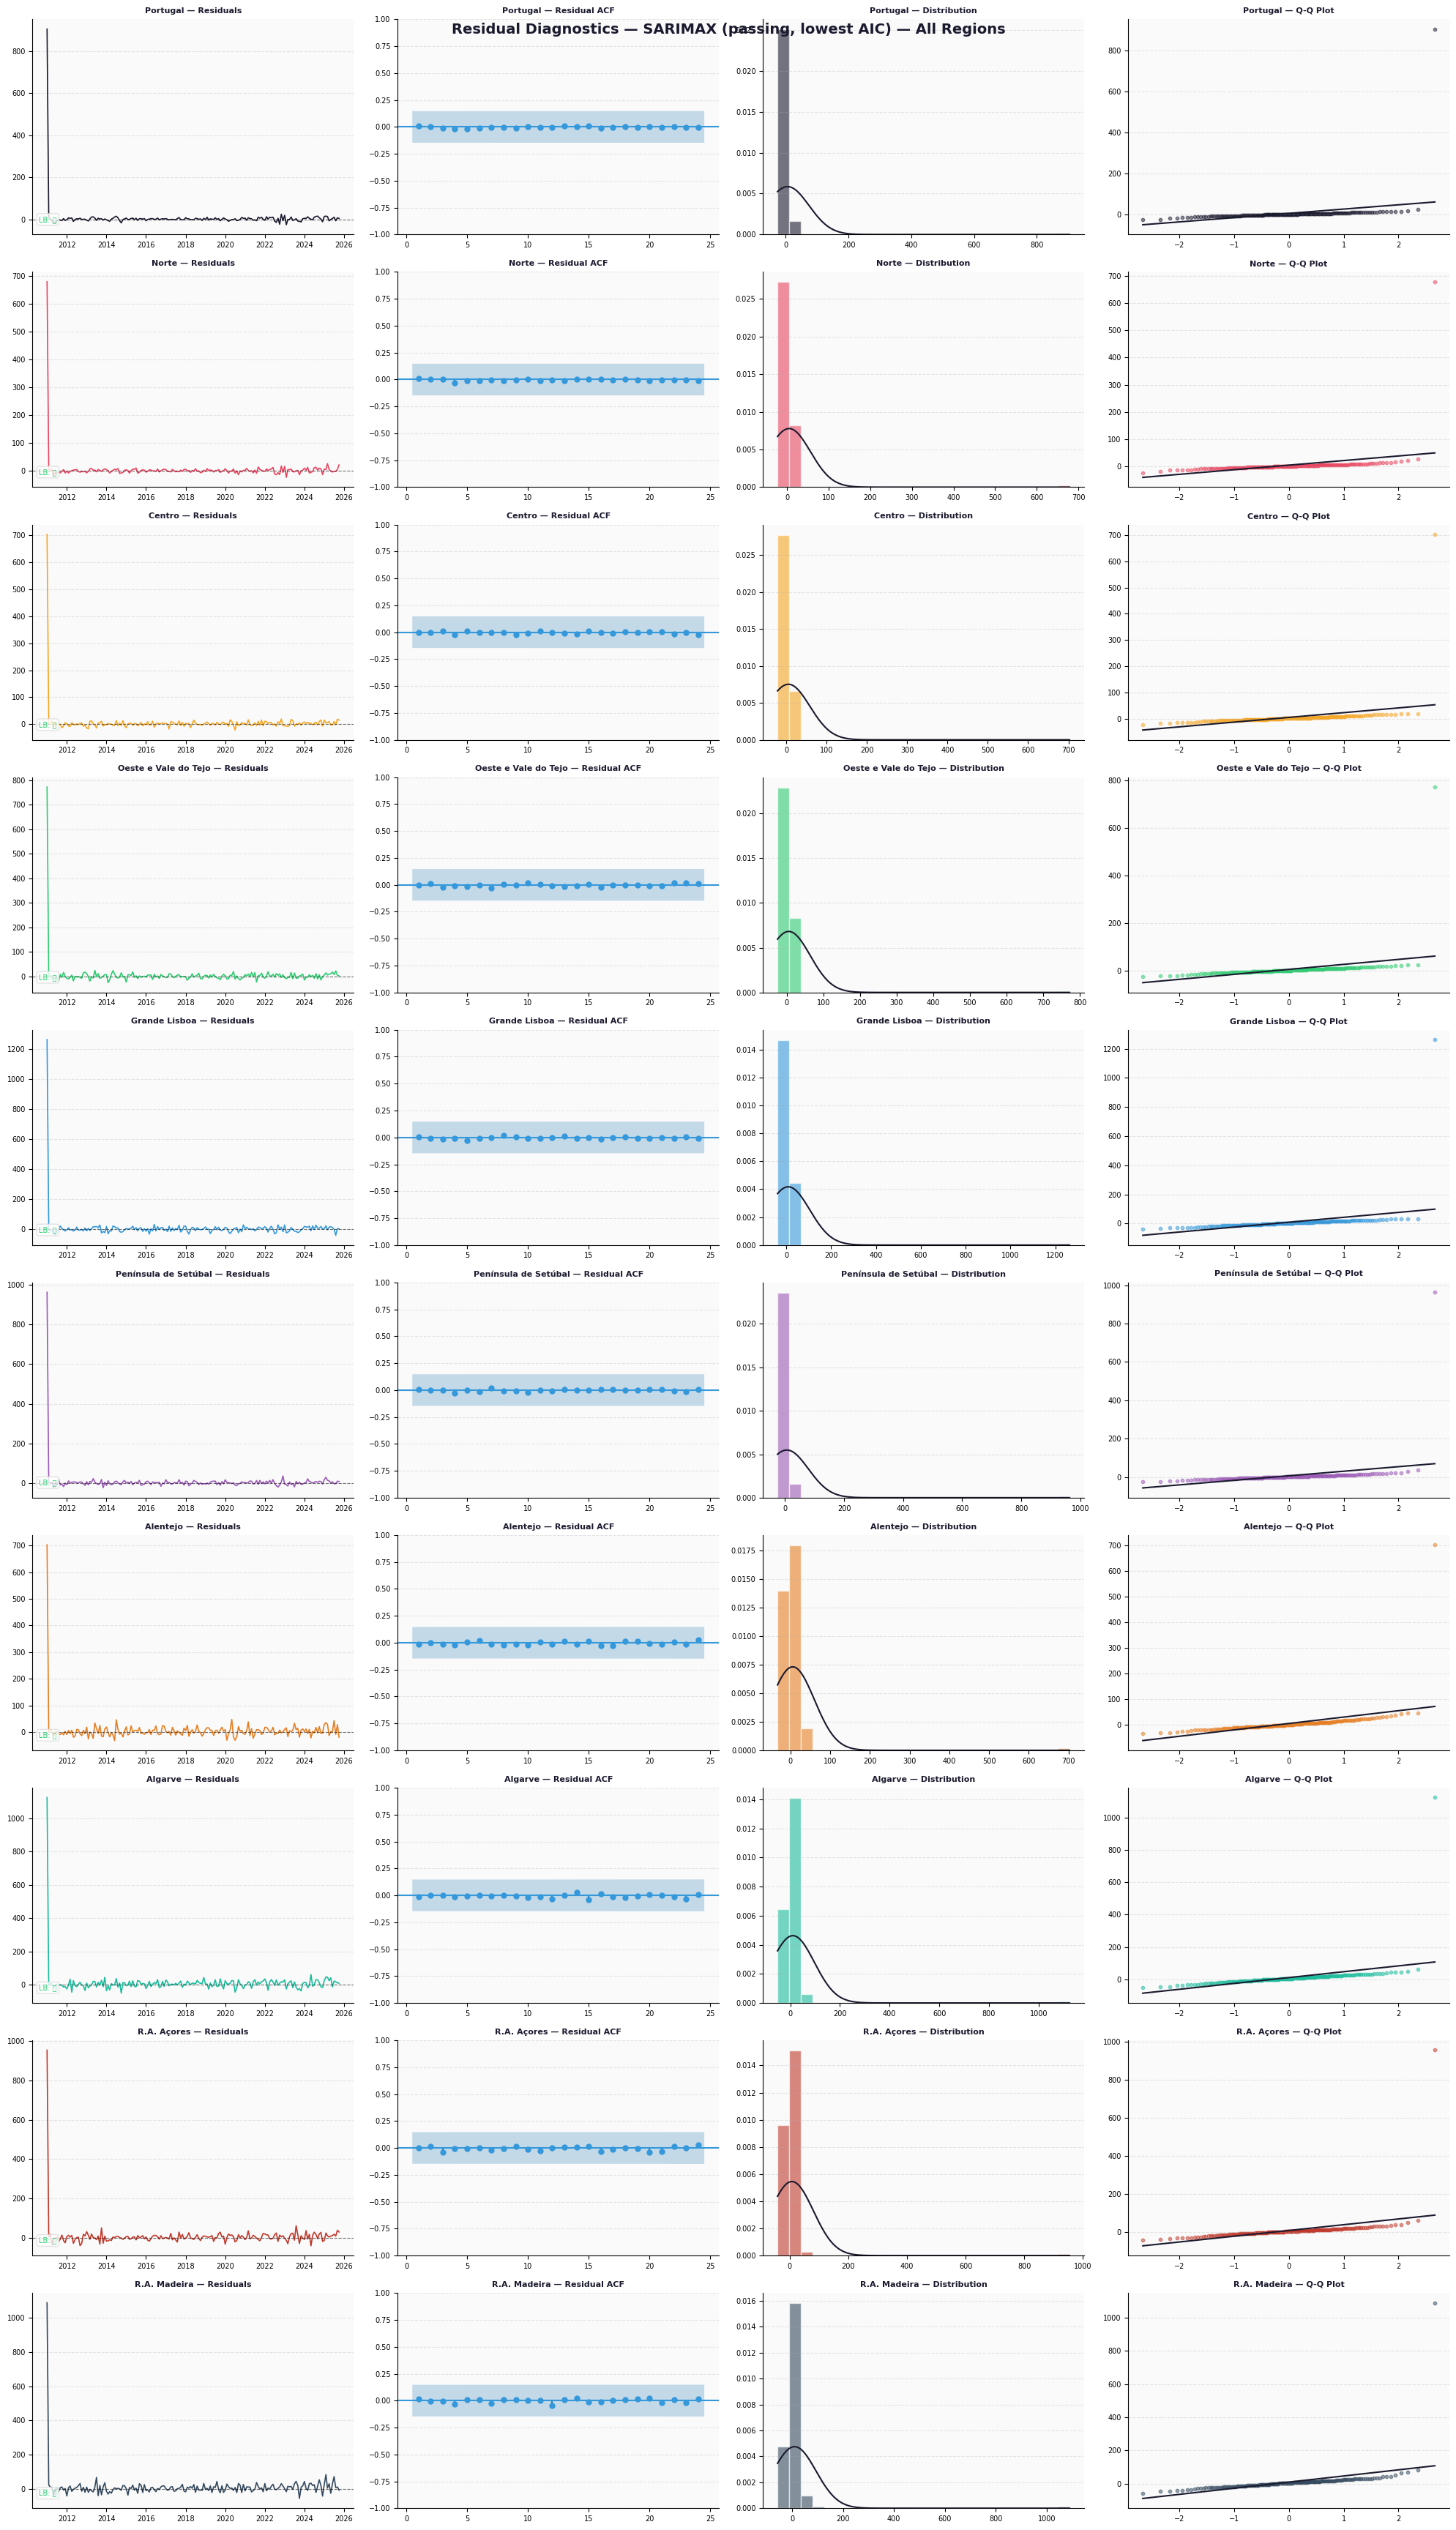

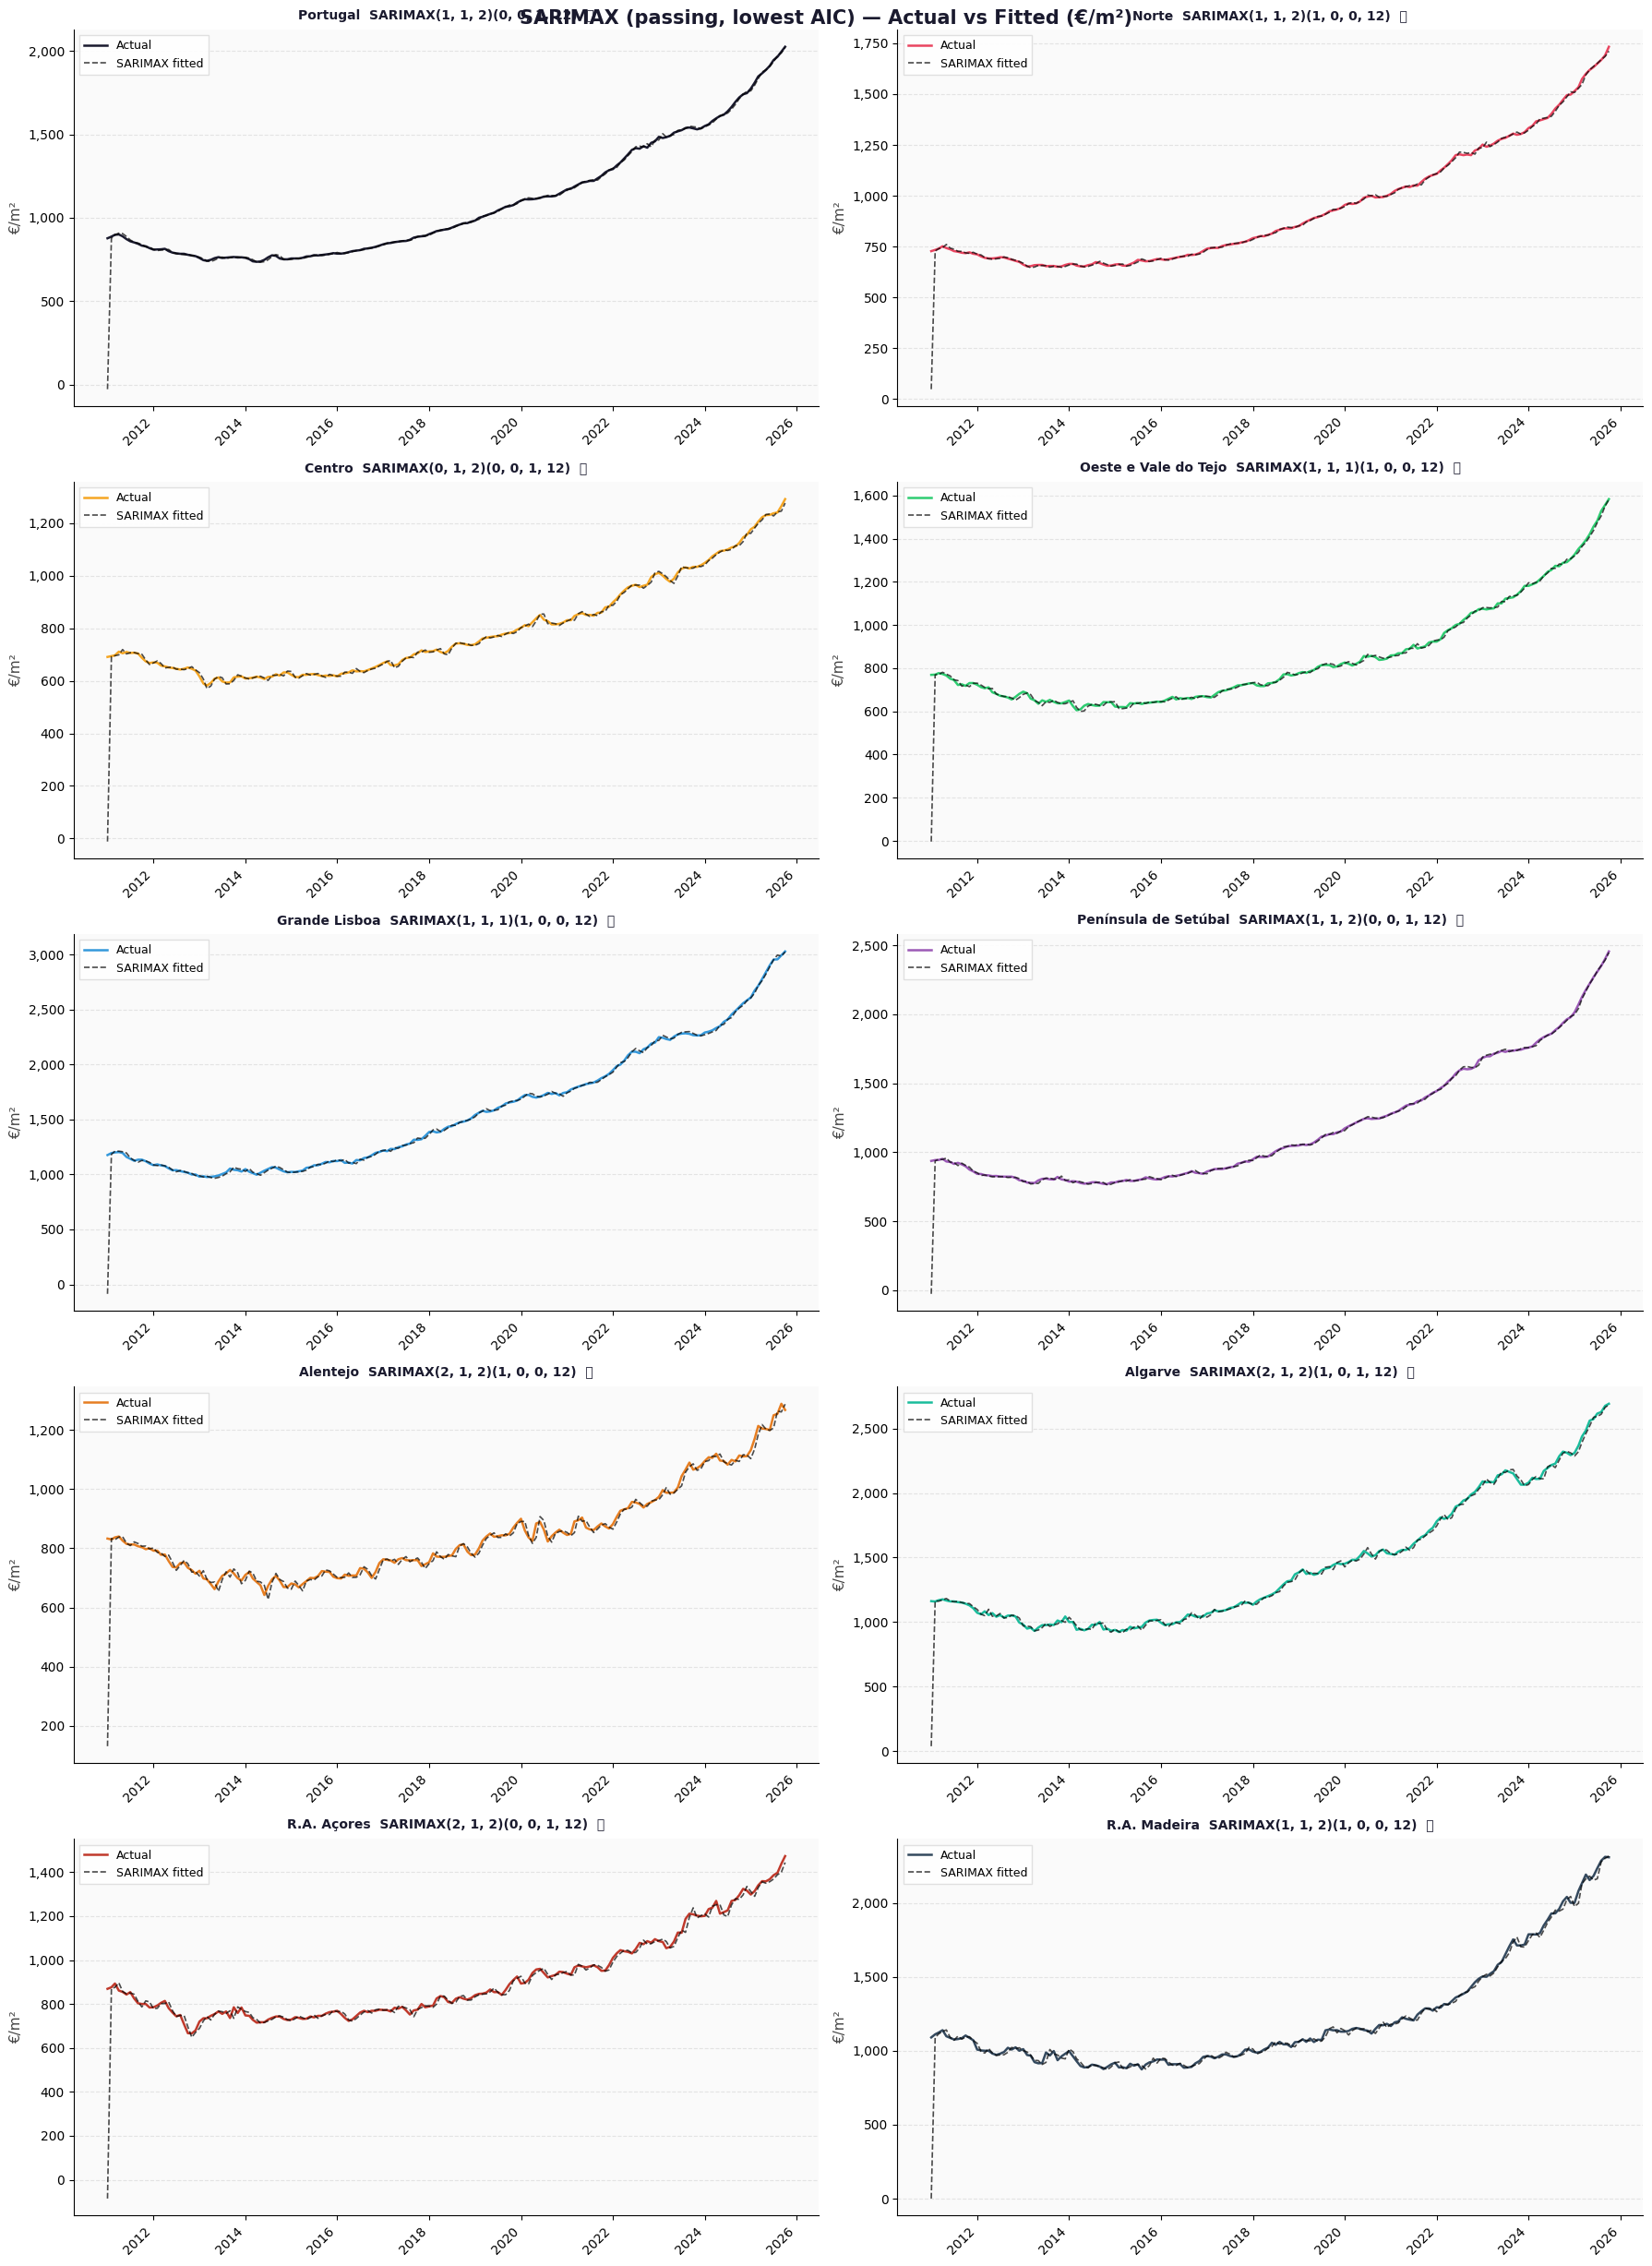

All plots saved


In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import scipy.stats as stats
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# GRID SEARCH PARAMETERS
# ─────────────────────────────────────────────
regular_orders  = [(0,1,1), (0,1,2), (1,1,1), (1,1,2), (2,1,1), (2,1,2)]
seasonal_orders = [(0,0,1,12), (1,0,0,12), (1,0,1,12),
                   (0,1,1,12), (1,1,0,12), (1,1,1,12)]

no_inflation = ['Oeste e Vale do Tejo', 'Península de Setúbal']

sarimax_passing_models  = {}
sarimax_passing_results = {}

# ─────────────────────────────────────────────
# GRID SEARCH
# ─────────────────────────────────────────────
for col in df.columns:

    if col in no_inflation:
        exog = pd.DataFrame({
            'mortgage':     mortgage[col],
            'new_houses':   new_houses[col],
            'unemployment': unemploy[col]
        })
        exog_label = "mortgage, new_houses, unemployment"
    else:
        exog = pd.DataFrame({
            'inflation':    inflation[col],
            'mortgage':     mortgage[col],
            'new_houses':   new_houses[col],
            'unemployment': unemploy[col]
        })
        exog_label = "inflation, mortgage, new_houses, unemployment"

    y      = df[col]
    common = y.index.intersection(exog.index)
    common = common[common <= end_date]

    y_fit    = y.loc[common]
    exog_fit = exog.loc[common]

    valid    = y_fit.notna() & exog_fit.notna().all(axis=1)
    y_fit    = y_fit[valid]
    exog_fit = exog_fit[valid]

    if len(y_fit) < 30:
        print(f"{short_names[col]}: Insufficient data — skipped")
        continue

    print(f"\n{'='*95}")
    print(f"{short_names[col]}  |  {len(y_fit)} obs  |  "
          f"{y_fit.index.min().strftime('%Y-%m')} to "
          f"{y_fit.index.max().strftime('%Y-%m')}  |  Exog: {exog_label}")
    print(f"{'='*95}")
    print(f"{'Order':<15} {'Seasonal':<18} {'AIC':<10} {'BIC':<10} "
          f"{'LB p12':<10} {'LB p24':<10} {'Diag'}")
    print("-" * 75)

    region_results = []

    for r_order in regular_orders:
        for s_order in seasonal_orders:
            try:
                model = SARIMAX(y_fit,
                                exog=exog_fit,
                                order=r_order,
                                seasonal_order=s_order).fit(disp=False)

                resid = model.resid.dropna()
                lb12  = acorr_ljungbox(resid, lags=[12],
                                       return_df=True)['lb_pvalue'].values[0]
                lb24  = acorr_ljungbox(resid, lags=[24],
                                       return_df=True)['lb_pvalue'].values[0]
                lb_ok = lb12 > 0.05 and lb24 > 0.05
                diag  = "✅" if lb_ok else "❌"

                region_results.append({
                    'r_order': r_order, 's_order': s_order,
                    'aic': model.aic, 'bic': model.bic,
                    'lb12': lb12, 'lb24': lb24,
                    'lb_ok': lb_ok, 'model': model
                })

                print(f"{str(r_order):<15} {str(s_order):<18} "
                      f"{model.aic:<10.1f} {model.bic:<10.1f} "
                      f"{lb12:<10.4f} {lb24:<10.4f} {diag}")
            except:
                print(f"{str(r_order):<15} {str(s_order):<18} Failed")

    # ── Only keep models that pass diagnostics ──
    passing = [r for r in region_results if r['lb_ok']]

    if passing:
        best_passing = min(passing, key=lambda x: x['aic'])
        print(f"\n→ Best passing: SARIMAX{best_passing['r_order']}"
              f"{best_passing['s_order']}  AIC={best_passing['aic']:.1f}  ✅")

        sarimax_passing_results[col] = {
            'best_passing': best_passing,
            'all_passing':  passing,
            'y':            y_fit,
            'exog':         exog_fit,
            'exog_label':   exog_label
        }

        sarimax_passing_models[col] = {
            'model':      best_passing['model'],
            'y':          y_fit,
            'exog':       exog_fit,
            'r_order':    best_passing['r_order'],
            's_order':    best_passing['s_order'],
            'aic':        best_passing['aic'],
            'diag':       '✅',
            'exog_label': exog_label
        }
    else:
        print(f"\n→ No model passed diagnostics for {short_names[col]} — region excluded")

# ─────────────────────────────────────────────
# SUMMARY — PASSING MODELS ONLY
# ─────────────────────────────────────────────
print(f"\n\n{'='*100}")
print("SUMMARY — SARIMAX MODELS PASSING DIAGNOSTICS (lowest AIC per region)")
print(f"{'='*100}")
print(f"{'Region':<30} {'Model':<40} {'AIC':<10} {'Diag':<8} {'Exog'}")
print("-" * 100)

for col in sarimax_passing_models:
    r_str     = str(sarimax_passing_models[col]['r_order'])
    s_str     = str(sarimax_passing_models[col]['s_order'])
    model_str = f"SARIMAX{r_str}{s_str}"
    print(f"{short_names[col]:<30} {model_str:<40} "
          f"{sarimax_passing_models[col]['aic']:<10.1f} "
          f"{sarimax_passing_models[col]['diag']:<8} "
          f"{sarimax_passing_models[col]['exog_label']}")

if len(sarimax_passing_models) < len(df.columns):
    excluded = [short_names[c] for c in df.columns if c not in sarimax_passing_models]
    print(f"\n⚠️  Excluded (no passing model found): {', '.join(excluded)}")

# ─────────────────────────────────────────────
# FAIR AIC COMPARISON — SAME SAMPLE
# ─────────────────────────────────────────────
print(f"\n\n{'='*85}")
print("FAIR AIC COMPARISON — SARIMAX(passing) vs ARIMA(2,2,2) — SAME SAMPLE")
print(f"{'='*85}")
print(f"{'Region':<30} {'Obs':<8} {'ARIMA':<12} {'SARIMAX':<12} {'Δ AIC':<12} {'Winner'}")
print("-" * 85)

arima_same_sample = {}

for col in sarimax_passing_models:
    y_fit     = sarimax_passing_models[col]['y']
    arima_m   = ARIMA(y_fit, order=(2,2,2)).fit()
    arima_aic = arima_m.aic
    arima_same_sample[col] = arima_m

    sarimax_aic = sarimax_passing_models[col]['aic']
    diff        = sarimax_aic - arima_aic
    winner      = "SARIMAX ✅" if diff < -2 else "ARIMA" if diff > 2 else "Equivalent"

    print(f"{short_names[col]:<30} {len(y_fit):<8} {arima_aic:<12.1f} "
          f"{sarimax_aic:<12.1f} {diff:<12.1f} {winner}")

# ─────────────────────────────────────────────
# FORECAST ACCURACY — SAME HOLDOUT
# ─────────────────────────────────────────────
holdout = 12

print(f"\n\n{'='*95}")
print(f"FORECAST ACCURACY — SARIMAX(passing) vs ARIMA(2,2,2) — {holdout}-MONTH HOLDOUT")
print(f"{'='*95}")
print(f"{'Region':<30} {'ARIMA MAE':>11} {'SARIMAX MAE':>13} "
      f"{'ARIMA RMSE':>12} {'SARIMAX RMSE':>14} "
      f"{'ARIMA MAPE':>12} {'SARIMAX MAPE':>14} {'Better'}")
print("-" * 95)

accuracy_passing = {}

for col in sarimax_passing_models:
    y_full    = sarimax_passing_models[col]['y']
    exog_full = sarimax_passing_models[col]['exog']
    r_order   = sarimax_passing_models[col]['r_order']
    s_order   = sarimax_passing_models[col]['s_order']

    y_train    = y_full.iloc[:-holdout]
    y_test     = y_full.iloc[-holdout:]
    exog_train = exog_full.iloc[:-holdout]
    exog_test  = exog_full.iloc[-holdout:]

    # ARIMA — no exog, same sample
    arima_m = ARIMA(y_train, order=(2,2,2)).fit()
    arima_f = arima_m.forecast(steps=holdout)

    # SARIMAX — with exog, passing model
    sarimax_m = SARIMAX(y_train,
                        exog=exog_train,
                        order=r_order,
                        seasonal_order=s_order).fit(disp=False)
    sarimax_f = sarimax_m.forecast(steps=holdout, exog=exog_test)

    arima_mae    = mean_absolute_error(y_test, arima_f)
    sarimax_mae  = mean_absolute_error(y_test, sarimax_f)
    arima_rmse   = np.sqrt(np.mean((y_test - arima_f)**2))
    sarimax_rmse = np.sqrt(np.mean((y_test - sarimax_f)**2))
    arima_mape   = np.mean(np.abs((y_test - arima_f)   / y_test)) * 100
    sarimax_mape = np.mean(np.abs((y_test - sarimax_f) / y_test)) * 100

    better = "SARIMAX ✅" if sarimax_mape < arima_mape else "ARIMA"

    accuracy_passing[col] = {
        'arima_mae':   arima_mae,   'sarimax_mae':  sarimax_mae,
        'arima_rmse':  arima_rmse,  'sarimax_rmse': sarimax_rmse,
        'arima_mape':  arima_mape,  'sarimax_mape': sarimax_mape,
        'better':      better
    }

    print(f"{short_names[col]:<30} {arima_mae:>11.1f} {sarimax_mae:>13.1f} "
          f"{arima_rmse:>12.1f} {sarimax_rmse:>14.1f} "
          f"{arima_mape:>12.2f}% {sarimax_mape:>14.2f}% {better}")

# ─────────────────────────────────────────────
# COEFFICIENT TABLE WITH SIGNIFICANCE
# ─────────────────────────────────────────────
print(f"\n\n{'='*100}")
print("SARIMAX (passing) EXOGENOUS COEFFICIENTS WITH SIGNIFICANCE")
print(f"{'='*100}")
print(f"{'Region':<30} {'Variable':<15} {'Coef':<12} {'Std Err':<12} {'p-value':<12} {'Significance'}")
print("-" * 100)

for col in sarimax_passing_models:
    model  = sarimax_passing_models[col]['model']
    params = model.params
    pvals  = model.pvalues
    bse    = model.bse

    exog_vars = ['inflation', 'mortgage', 'new_houses', 'unemployment'] \
                if col not in no_inflation else \
                ['mortgage', 'new_houses', 'unemployment']

    for var in exog_vars:
        coef = params.get(var, np.nan)
        se   = bse.get(var, np.nan)
        pval = pvals.get(var, np.nan)
        sig  = '***' if pval < 0.01 else '**' if pval < 0.05 \
               else '*' if pval < 0.1 else ''
        print(f"{short_names[col]:<30} {var:<15} {coef:<12.4f} "
              f"{se:<12.4f} {pval:<12.4f} {sig}")
    print()

# ─────────────────────────────────────────────
# RESIDUAL DIAGNOSTICS PLOT
# ─────────────────────────────────────────────
n     = len(sarimax_passing_models)
fig, axes = plt.subplots(n, 4, figsize=(20, n * 3.5))
fig.patch.set_facecolor('white')

# Handle case where only 1 region passes
if n == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(sarimax_passing_models):
    resid = sarimax_passing_models[col]['model'].resid.dropna()

    ax1 = axes[i, 0]
    ax1.plot(resid.index, resid, color=colors[col], linewidth=1.2)
    ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax1.set_title(f'{short_names[col]} — Residuals', fontsize=8,
                  fontweight='bold', color='#1a1a2e')
    ax1.annotate("LB: ✅", xy=(0.02, 0.06), xycoords='axes fraction',
                 fontsize=7, color='#2ecc71',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='#ddd', alpha=0.8))

    ax2 = axes[i, 1]
    plot_acf(resid, ax=ax2, lags=24, color='#3498db', zero=False)
    ax2.set_title(f'{short_names[col]} — Residual ACF', fontsize=8,
                  fontweight='bold', color='#1a1a2e')

    ax3 = axes[i, 2]
    ax3.hist(resid, bins=25, color=colors[col], alpha=0.6,
             edgecolor='white', density=True)
    x = np.linspace(resid.min(), resid.max(), 200)
    ax3.plot(x, stats.norm.pdf(x, resid.mean(), resid.std()),
             color='#1a1a2e', linewidth=1.5)
    ax3.set_title(f'{short_names[col]} — Distribution', fontsize=8,
                  fontweight='bold', color='#1a1a2e')

    ax4 = axes[i, 3]
    (osm, osr), (slope, intercept, _) = stats.probplot(resid, dist='norm')
    ax4.scatter(osm, osr, color=colors[col], alpha=0.5, s=10)
    ax4.plot(osm, slope * np.array(osm) + intercept,
             color='#1a1a2e', linewidth=1.5)
    ax4.set_title(f'{short_names[col]} — Q-Q Plot', fontsize=8,
                  fontweight='bold', color='#1a1a2e')

    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_facecolor('#fafafa')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=7)

fig.suptitle('Residual Diagnostics — SARIMAX (passing, lowest AIC) — All Regions',
             fontsize=14, fontweight='bold', color='#1a1a2e')
plt.tight_layout()
plt.savefig('sarimax_passing_diagnostics.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

# ─────────────────────────────────────────────
# FITTED VALUES PLOT
# ─────────────────────────────────────────────
nrows = (n + 1) // 2

fig, axes = plt.subplots(nrows, 2, figsize=(18, nrows * 5))
fig.patch.set_facecolor('white')

if nrows == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(sarimax_passing_models):
    ax     = axes.flatten()[i]
    y_fit  = sarimax_passing_models[col]['y']
    fitted = sarimax_passing_models[col]['model'].fittedvalues

    ax.plot(y_fit.index, y_fit,
            color=colors[col], linewidth=1.8, label='Actual')
    ax.plot(fitted.index, fitted,
            color='black', linewidth=1.2, linestyle='--',
            alpha=0.7, label='SARIMAX fitted')

    r_str = str(sarimax_passing_models[col]['r_order'])
    s_str = str(sarimax_passing_models[col]['s_order'])
    ax.set_title(f"{short_names[col]}  SARIMAX{r_str}{s_str}  ✅",
                 fontsize=10, fontweight='bold', color='#1a1a2e', pad=8)
    ax.set_ylabel('€/m²', fontsize=11, color='#444')
    ax.set_facecolor('#fafafa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=10)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(fontsize=9, framealpha=0.9, edgecolor='#ddd', fancybox=False)

for j in range(i + 1, nrows * 2):
    axes.flatten()[j].set_visible(False)

fig.suptitle('SARIMAX (passing, lowest AIC) — Actual vs Fitted (€/m²)',
             fontsize=15, fontweight='bold', color='#1a1a2e')
plt.tight_layout()
plt.savefig('sarimax_passing_fitted.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("All plots saved")

Region                         Model                                         Type       AIC          BIC
---------------------------------------------------------------------------------------------------------


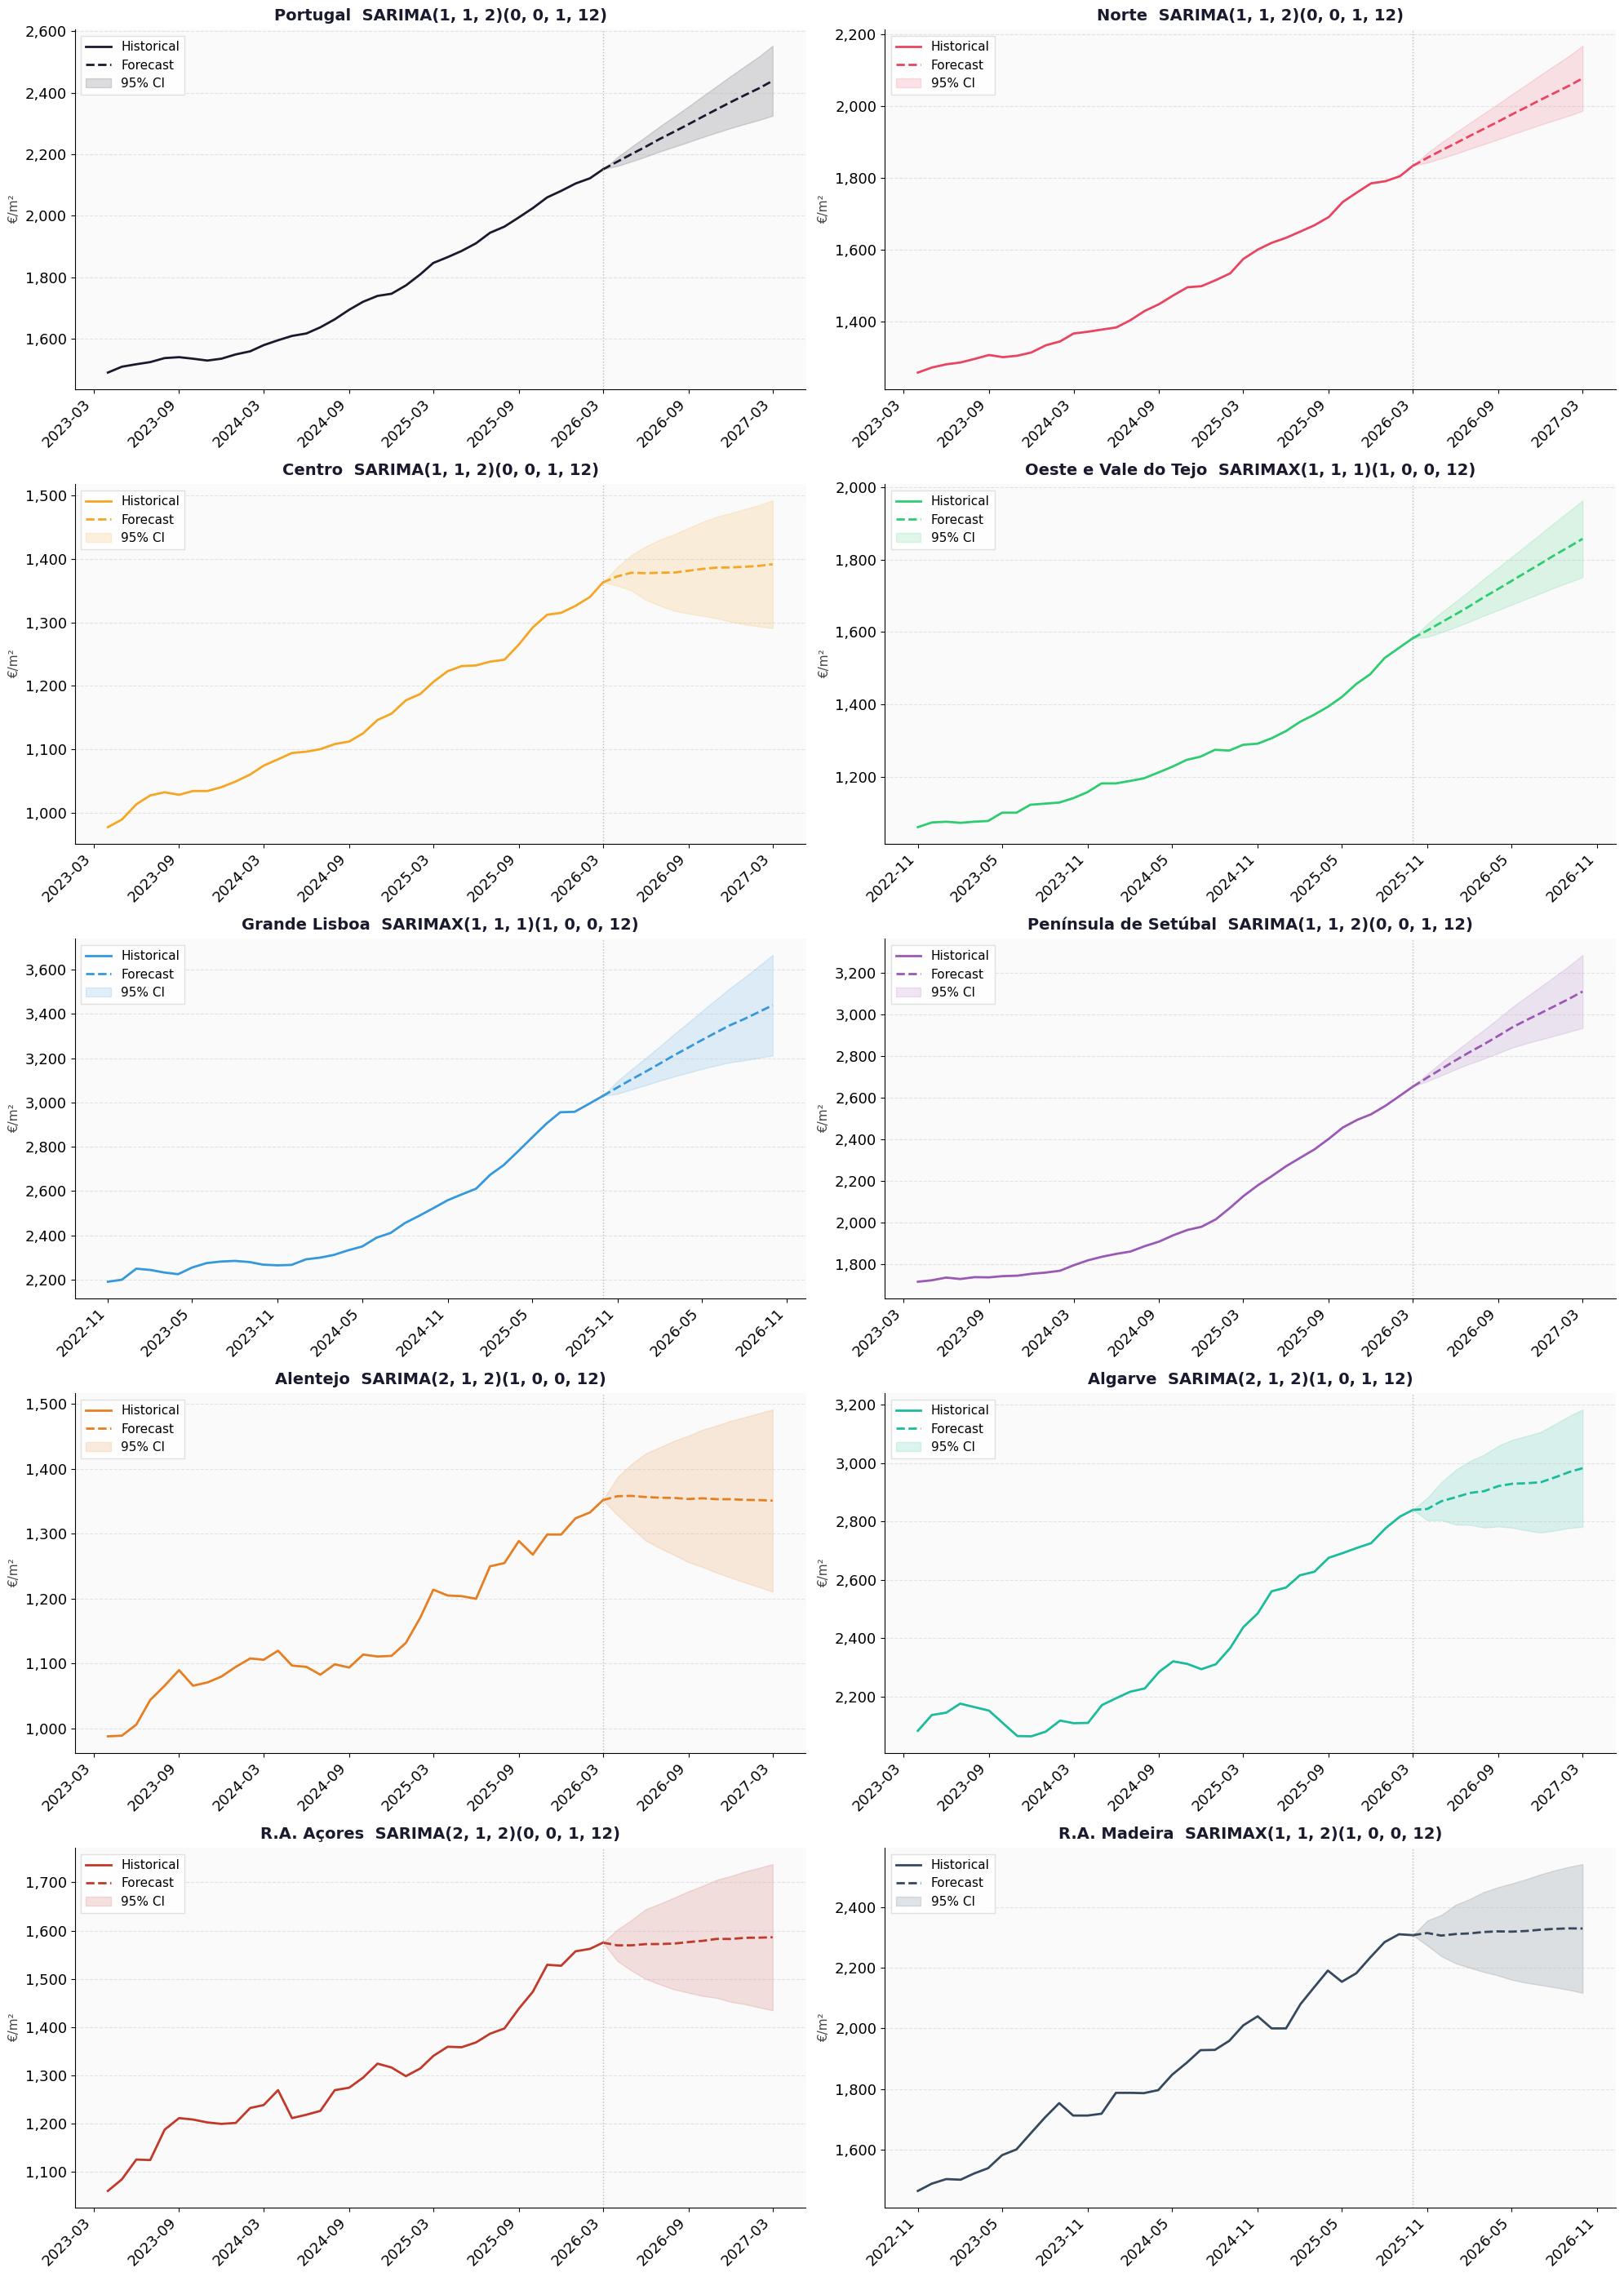


SARIMA FORECAST — APRIL 2026 TO MARCH 2027 (€/m²)
         Portugal  Norte  Centro  Península de Setúbal  Alentejo  Algarve  R.A. Açores
Month                                                                                 
2026-03      2151   1834    1363                  2653      1352     2840         1575
2026-04      2176   1856    1373                  2696      1358     2843         1569
2026-05      2200   1877    1378                  2737      1359     2870         1569
2026-06      2225   1897    1377                  2780      1357     2883         1572
2026-07      2250   1917    1378                  2819      1356     2898         1572
2026-08      2273   1937    1379                  2857      1355     2904         1573
2026-09      2297   1958    1381                  2897      1354     2922         1576
2026-10      2322   1978    1384                  2938      1355     2930         1579
2026-11      2346   1998    1386                  2973      1353     2931      

In [24]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# FINAL MODEL SPECS
# ─────────────────────────────────────────────
sarima_specs = {
    'Portugal':                     {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Norte':                        {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Centro':                       {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Península de Setúbal':         {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Alentejo':                     {'r_order': (2,1,2), 's_order': (1,0,0,12)},
    'Algarve':                      {'r_order': (2,1,2), 's_order': (1,0,1,12)},
    'Região Autónoma dos Açores':   {'r_order': (2,1,2), 's_order': (0,0,1,12)},
}

sarimax_specs = {
    'Oeste e Vale do Tejo':       {'r_order': (1,1,1), 's_order': (1,0,0,12)},
    'Grande Lisboa':              {'r_order': (1,1,1), 's_order': (1,0,0,12)},
    'Região Autónoma da Madeira': {'r_order': (1,1,2), 's_order': (1,0,0,12)},
}

no_inflation  = ['Oeste e Vale do Tejo', 'Península de Setúbal']
forecast_steps = 12  # 12 months ahead for both

# ─────────────────────────────────────────────
# FIT ALL FINAL MODELS
# ─────────────────────────────────────────────
final_models = {}

print(f"{'Region':<30} {'Model':<45} {'Type':<10} {'AIC':<12} {'BIC'}")
print("-" * 105)

for col, spec in sarima_specs.items():
    model = SARIMAX(df[col],
                    order=spec['r_order'],
                    seasonal_order=spec['s_order']).fit(disp=False)
    final_models[col] = {
        'model': model, 'r_order': spec['r_order'],
        's_order': spec['s_order'], 'type': 'SARIMA',
        'has_exog': False, 'y': df[col]
    }
    

for col, spec in sarimax_specs.items():
    if col in no_inflation:
        exog = pd.DataFrame({
            'mortgage':     mortgage[col],
            'new_houses':   new_houses[col],
            'unemployment': unemploy[col]
        })
    else:
        exog = pd.DataFrame({
            'inflation':    inflation[col],
            'mortgage':     mortgage[col],
            'new_houses':   new_houses[col],
            'unemployment': unemploy[col]
        })

    y      = df[col]
    common = y.index.intersection(exog.index)
    common = common[common <= end_date]
    y_fit    = y.loc[common]
    exog_fit = exog.loc[common]
    valid    = y_fit.notna() & exog_fit.notna().all(axis=1)
    y_fit    = y_fit[valid]
    exog_fit = exog_fit[valid]

    model = SARIMAX(y_fit, exog=exog_fit,
                    order=spec['r_order'],
                    seasonal_order=spec['s_order']).fit(disp=False)
    final_models[col] = {
        'model': model, 'r_order': spec['r_order'],
        's_order': spec['s_order'], 'type': 'SARIMAX',
        'has_exog': True, 'y': y_fit, 'exog': exog_fit
    }
    

# ─────────────────────────────────────────────
# FORECAST AND PLOT
# ─────────────────────────────────────────────
fig, axes = plt.subplots(5, 2, figsize=(20, 28))
fig.patch.set_facecolor('white')

sarima_forecast_df  = pd.DataFrame()
sarimax_forecast_df = pd.DataFrame()

for i, col in enumerate(df.columns):
    ax    = axes.flatten()[i]
    entry = final_models[col]
    model = entry['model']
    y     = entry['y']

    last_date = y.index[-1]
    last_val  = y.iloc[-1]

    if entry['has_exog']:
        # ── SARIMAX: forecast 12 months from end of its sample (Oct 2025) ──
        last_exog_values = entry['exog'].iloc[-1]
        future_dates = pd.date_range(
            start=last_date + pd.DateOffset(months=1),
            periods=forecast_steps,
            freq='MS'
        )
        future_exog = pd.DataFrame(
            [last_exog_values.values] * forecast_steps,
            index=future_dates,
            columns=entry['exog'].columns
        )
        forecast_obj  = model.get_forecast(steps=forecast_steps,
                                           exog=future_exog)
        forecast_mean = forecast_obj.predicted_mean
        conf_int      = forecast_obj.conf_int(alpha=0.05)
        forecast_mean.index = future_dates
        conf_int.index      = future_dates

    else:
        # ── SARIMA: forecast 12 months from end of full series (Mar 2026) ──
        forecast_obj  = model.get_forecast(steps=forecast_steps)
        forecast_mean = forecast_obj.predicted_mean
        conf_int      = forecast_obj.conf_int(alpha=0.05)
        future_dates  = pd.date_range(
            start=last_date + pd.DateOffset(months=1),
            periods=forecast_steps,
            freq='MS'
        )
        forecast_mean.index = future_dates
        conf_int.index      = future_dates

    # Connect last observed point to forecast
    forecast_mean_plot = pd.concat([
        pd.Series([last_val], index=[last_date]),
        forecast_mean
    ])
    conf_int_plot = pd.concat([
        pd.DataFrame([[last_val, last_val]], index=[last_date],
                     columns=conf_int.columns),
        conf_int
    ])

    history = y.iloc[-36:]

    ax.plot(history.index, history,
            color=colors[col], linewidth=2.0, label='Historical')
    ax.plot(forecast_mean_plot.index, forecast_mean_plot,
            color=colors[col], linewidth=2.0, linestyle='--', label='Forecast')
    ax.fill_between(conf_int_plot.index,
                    conf_int_plot.iloc[:, 0],
                    conf_int_plot.iloc[:, 1],
                    color=colors[col], alpha=0.15, label='95% CI')

    ax.axvline(last_date, color='#aaa', linewidth=1, linestyle=':', alpha=0.8)

    r_str      = str(entry['r_order'])
    s_str      = str(entry['s_order'])
    model_type = entry['type']
    ax.set_title(f"{short_names[col]}  {model_type}{r_str}{s_str}",
                 fontsize=14, fontweight='bold', color='#1a1a2e', pad=8)
    ax.set_ylabel('€/m²', fontsize=11, color='#444')
    ax.set_facecolor('#fafafa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=13)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=13)
    ax.legend(fontsize=11, framealpha=0.9, edgecolor='#ddd', fancybox=False)

    # ── Build forecast tables ──
    current = pd.Series([int(last_val)], index=[last_date],
                        name=short_names[col])
    forecast_rounded = pd.Series(
        forecast_mean.values,
        index=future_dates
    ).round(0).astype(int).rename(short_names[col])
    full_series = pd.concat([current, forecast_rounded])

    if entry['has_exog']:
        sarimax_forecast_df[short_names[col]] = full_series
    else:
        sarima_forecast_df[short_names[col]] = full_series

plt.tight_layout()
plt.savefig('forecast_final_mixed.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

# ─────────────────────────────────────────────
# FORECAST TABLES — SEPARATE FOR CLARITY
# ─────────────────────────────────────────────
sarima_forecast_df.index  = sarima_forecast_df.index.strftime('%Y-%m')
sarimax_forecast_df.index = sarimax_forecast_df.index.strftime('%Y-%m')
sarima_forecast_df.index.name  = 'Month'
sarimax_forecast_df.index.name = 'Month'

print(f"\n{'='*80}")
print("SARIMA FORECAST — APRIL 2026 TO MARCH 2027 (€/m²)")
print(f"{'='*80}")
print(sarima_forecast_df.to_string())

print(f"\n{'='*80}")
print("SARIMAX FORECAST — NOVEMBER 2025 TO OCTOBER 2026 (€/m²)")
print(f"{'='*80}")
print(sarimax_forecast_df.to_string())

sarima_forecast_df.to_csv('forecast_sarima_final.csv')
sarimax_forecast_df.to_csv('forecast_sarimax_final.csv')
print("\nForecasts saved")

# ─────────────────────────────────────────────
# MODEL SUMMARY
# ─────────────────────────────────────────────
print(f"\n{'='*80}")
print("FINAL MODEL SUMMARY")
print(f"{'='*80}")
print(f"{'Region':<30} {'Type':<10} {'Model':<40} {'AIC':<12} {'Forecast period'}")
print("-" * 90)

for col in df.columns:
    entry     = final_models[col]
    model_str = f"{entry['type']}{entry['r_order']}{entry['s_order']}"
    period    = "Apr 2026 – Mar 2027" if not entry['has_exog'] \
                else "Nov 2025 – Oct 2026"
    print(f"{short_names[col]:<30} {entry['type']:<10} {model_str:<40} "
          f"{entry['model'].aic:<12.1f} {period}")

Region                         Model                                         Type       AIC          BIC
---------------------------------------------------------------------------------------------------------
Portugal                       SARIMA(1, 1, 2)(0, 0, 1, 12)             SARIMA     1248.7       1264.7
Norte                          SARIMA(1, 1, 2)(0, 0, 1, 12)             SARIMA     1231.5       1247.5
Centro                         SARIMA(1, 1, 2)(0, 0, 1, 12)             SARIMA     1264.7       1280.8
Península de Setúbal           SARIMA(1, 1, 2)(0, 0, 1, 12)             SARIMA     1337.1       1353.2
Alentejo                       SARIMA(2, 1, 2)(1, 0, 0, 12)             SARIMA     1512.5       1531.7
Algarve                        SARIMA(2, 1, 2)(1, 0, 1, 12)             SARIMA     1620.8       1643.2
R.A. Açores                    SARIMA(2, 1, 2)(0, 0, 1, 12)             SARIMA     1552.4       1571.6
Oeste e Vale do Tejo           SARIMAX(1, 1, 1)(1, 0, 0, 12)        

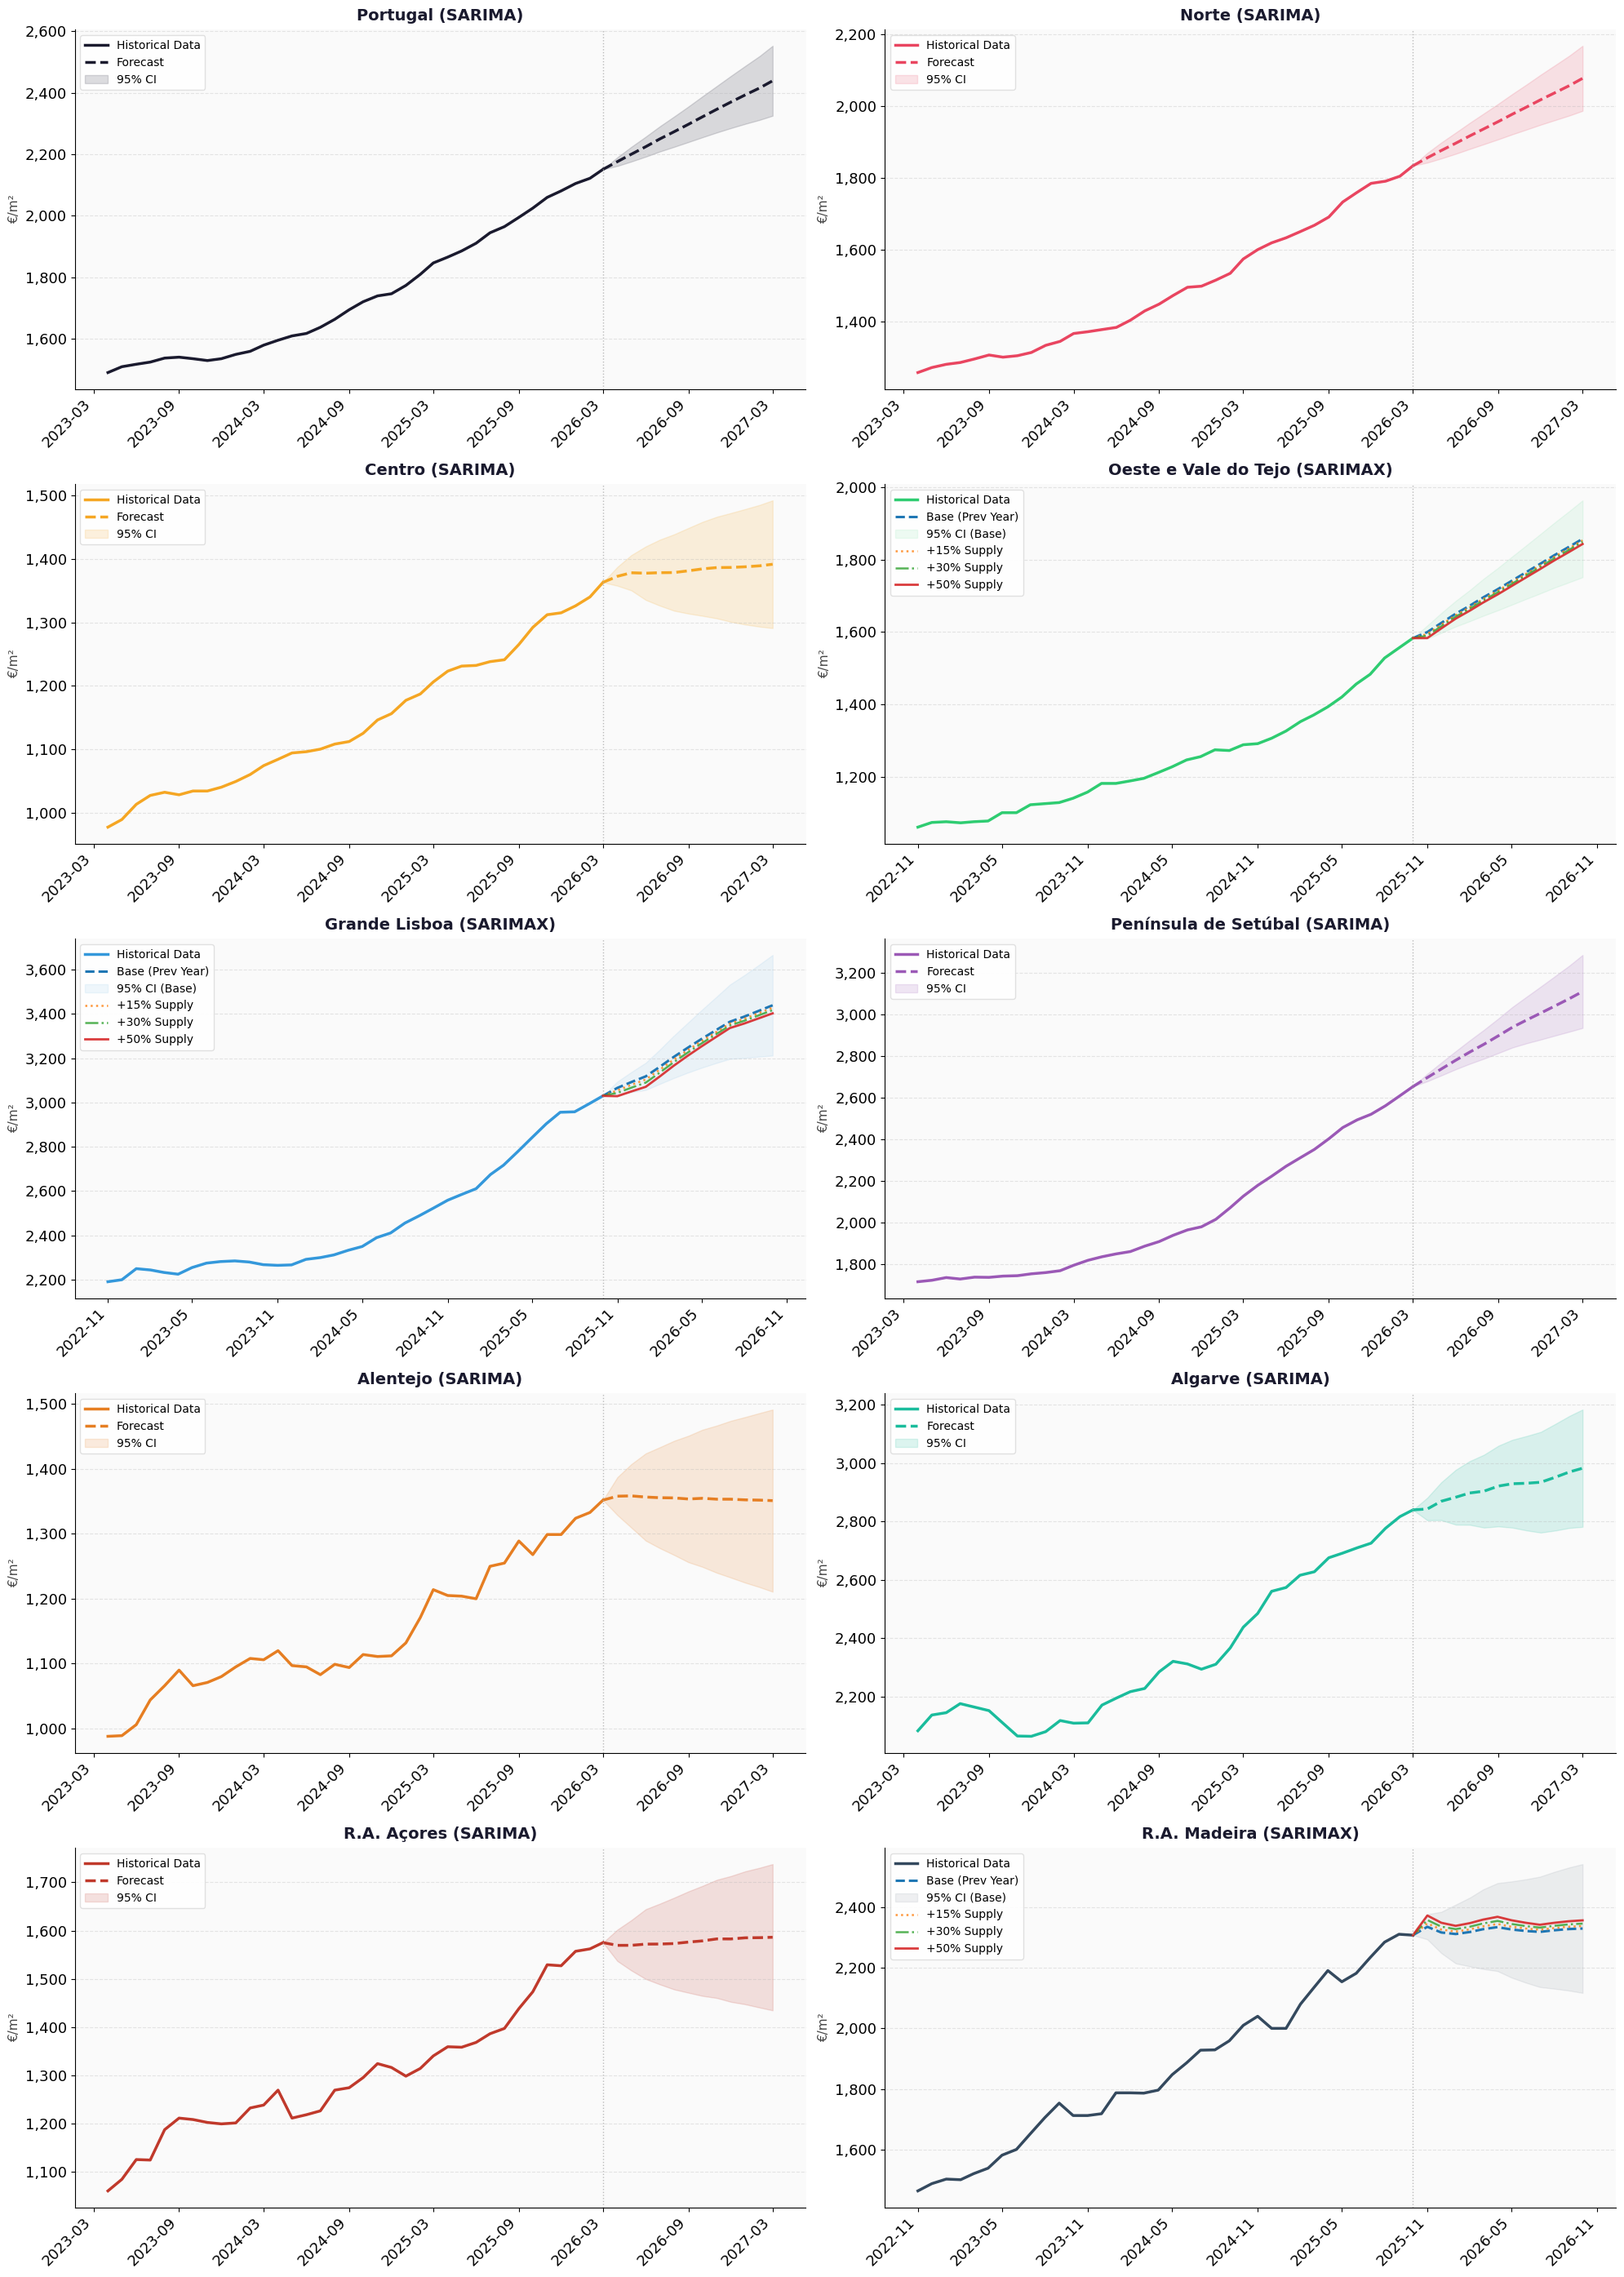


SARIMA FORECAST STANDARDS (€/m²)
         Portugal  Norte  Centro  Península de Setúbal  Alentejo  Algarve  R.A. Açores
2026-03      2151   1834    1363                  2653      1352     2840         1575
2026-04      2176   1856    1373                  2696      1358     2843         1569
2026-05      2200   1877    1378                  2737      1359     2870         1569
2026-06      2225   1897    1377                  2780      1357     2883         1572
2026-07      2250   1917    1378                  2819      1356     2898         1572
2026-08      2273   1937    1379                  2857      1355     2904         1573
2026-09      2297   1958    1381                  2897      1354     2922         1576
2026-10      2322   1978    1384                  2938      1355     2930         1579
2026-11      2346   1998    1386                  2973      1353     2931         1583
2026-12      2369   2018    1387                  3006      1353     2935         1583
2027-01  

In [28]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# FINAL MODEL SPECS
# ─────────────────────────────────────────────
sarima_specs = {
    'Portugal':                     {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Norte':                        {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Centro':                       {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Península de Setúbal':         {'r_order': (1,1,2), 's_order': (0,0,1,12)},
    'Alentejo':                     {'r_order': (2,1,2), 's_order': (1,0,0,12)},
    'Algarve':                      {'r_order': (2,1,2), 's_order': (1,0,1,12)},
    'Região Autónoma dos Açores':   {'r_order': (2,1,2), 's_order': (0,0,1,12)},
}

sarimax_specs = {
    'Oeste e Vale do Tejo':       {'r_order': (1,1,1), 's_order': (1,0,0,12)},
    'Grande Lisboa':              {'r_order': (1,1,1), 's_order': (1,0,0,12)},
    'Região Autónoma da Madeira': {'r_order': (1,1,2), 's_order': (1,0,0,12)},
}

no_inflation  = ['Oeste e Vale do Tejo', 'Península de Setúbal']
forecast_steps = 12  # 12 months ahead for both

# Scenarios definition for SARIMAX models
scenarios = {
    'Base (Prev Year)': 1.0,
    '+15% Supply': 1.15,
    '+30% Supply': 1.30,
    '+50% Supply': 1.50
}

# ─────────────────────────────────────────────
# FIT ALL FINAL MODELS
# ─────────────────────────────────────────────
final_models = {}

print(f"{'Region':<30} {'Model':<45} {'Type':<10} {'AIC':<12} {'BIC'}")
print("-" * 105)

for col, spec in sarima_specs.items():
    model = SARIMAX(df[col],
                    order=spec['r_order'],
                    seasonal_order=spec['s_order']).fit(disp=False)
    final_models[col] = {
        'model': model, 'r_order': spec['r_order'],
        's_order': spec['s_order'], 'type': 'SARIMA',
        'has_exog': False, 'y': df[col]
    }
    print(f"{short_names[col]:<30} SARIMA{spec['r_order']}{str(spec['s_order']):<25} {'SARIMA':<10} {model.aic:<12.1f} {model.bic:.1f}")

for col, spec in sarimax_specs.items():
    if col in no_inflation:
        exog = pd.DataFrame({
            'mortgage':     mortgage[col],
            'new_houses':   new_houses[col],
            'unemployment': unemploy[col]
        })
    else:
        exog = pd.DataFrame({
            'inflation':    inflation[col],
            'mortgage':     mortgage[col],
            'new_houses':   new_houses[col],
            'unemployment': unemploy[col]
        })

    y      = df[col]
    common = y.index.intersection(exog.index)
    common = common[common <= end_date]
    y_fit    = y.loc[common]
    exog_fit = exog.loc[common]
    valid    = y_fit.notna() & exog_fit.notna().all(axis=1)
    y_fit    = y_fit[valid]
    exog_fit = exog_fit[valid]

    model = SARIMAX(y_fit, exog=exog_fit,
                    order=spec['r_order'],
                    seasonal_order=spec['s_order']).fit(disp=False)
    final_models[col] = {
        'model': model, 'r_order': spec['r_order'],
        's_order': spec['s_order'], 'type': 'SARIX',
        'has_exog': True, 'y': y_fit, 'exog': exog_fit
    }
    print(f"{short_names[col]:<30} SARIMAX{spec['r_order']}{str(spec['s_order']):<24} {'SARIMAX':<10} {model.aic:<12.1f} {model.bic:.1f}")
    

# ─────────────────────────────────────────────
# FORECAST AND PLOT
# ─────────────────────────────────────────────
fig, axes = plt.subplots(5, 2, figsize=(20, 28))
fig.patch.set_facecolor('white')

sarima_forecast_df  = pd.DataFrame()
sarimax_forecast_df = pd.DataFrame()

for i, col in enumerate(df.columns):
    ax    = axes.flatten()[i]
    entry = final_models[col]
    model = entry['model']
    y     = entry['y']

    last_date = y.index[-1]
    last_val  = y.iloc[-1]
    
    # Historical baseline line
    history = y.iloc[-36:]
    ax.plot(history.index, history, color=colors[col], linewidth=2.5, label='Historical Data')

    if entry['has_exog']:
        # ── SARIMAX: Run scenario simulations ──
        future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')
        last_exog_values = entry['exog'].iloc[-1]
        
        # Pull the exact matching 12 months from the previous year
        prev_year_houses = entry['exog']['new_houses'].iloc[-12:].values
        
        # Design visual properties for scenarios
        styles = {
            'Base (Prev Year)': {'ls': '--', 'alpha': 1.0, 'lw': 2.2, 'marker': None},
            '+15% Supply':       {'ls': ':',  'alpha': 0.8, 'lw': 1.8, 'marker': 'o'},
            '+30% Supply':       {'ls': '-.', 'alpha': 0.8, 'lw': 1.8, 'marker': '^'},
            '+50% Supply':       {'ls': '-',  'alpha': 0.9, 'lw': 2.0, 'marker': 's'}
        }

        for sc_name, multiplier in scenarios.items():
            # Build separate future frame for each scenario
            future_exog = pd.DataFrame([last_exog_values.values] * forecast_steps, index=future_dates, columns=entry['exog'].columns)
            
            # Inject seasonal baseline modified by our targeted supply adjustment percentage
            future_exog['new_houses'] = prev_year_houses * multiplier
            
            forecast_obj  = model.get_forecast(steps=forecast_steps, exog=future_exog)
            forecast_mean = forecast_obj.predicted_mean
            forecast_mean.index = future_dates
            
            # Connect execution path cleanly to charts
            forecast_mean_plot = pd.concat([pd.Series([last_val], index=[last_date]), forecast_mean])
            
            ax.plot(forecast_mean_plot.index, forecast_mean_plot,
                    linestyle=styles[sc_name]['ls'], 
                    linewidth=styles[sc_name]['lw'],
                    alpha=styles[sc_name]['alpha'],
                    label=f'{sc_name}')
            
            # Shading confidence bands exclusively around baseline layout to ensure chart legibility
            if sc_name == 'Base (Prev Year)':
                conf_int = forecast_obj.conf_int(alpha=0.05)
                conf_int.index = future_dates
                conf_int_plot = pd.concat([pd.DataFrame([[last_val, last_val]], index=[last_date], columns=conf_int.columns), conf_int])
                ax.fill_between(conf_int_plot.index, conf_int_plot.iloc[:, 0], conf_int_plot.iloc[:, 1], color=colors[col], alpha=0.08, label='95% CI (Base)')

            # Save to summary data structures
            current = pd.Series([int(last_val)], index=[last_date], name=f"{short_names[col]} ({sc_name})")
            forecast_rounded = pd.Series(forecast_mean.values, index=future_dates).round(0).astype(int).rename(f"{short_names[col]} ({sc_name})")
            full_series = pd.concat([current, forecast_rounded])
            sarimax_forecast_df[f"{short_names[col]} ({sc_name})"] = full_series

    else:
        # ── SARIMA Baseline Models ──
        forecast_obj  = model.get_forecast(steps=forecast_steps)
        forecast_mean = forecast_obj.predicted_mean
        conf_int      = forecast_obj.conf_int(alpha=0.05)
        future_dates  = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')
        forecast_mean.index = future_dates
        conf_int.index      = future_dates

        forecast_mean_plot = pd.concat([pd.Series([last_val], index=[last_date]), forecast_mean])
        conf_int_plot = pd.concat([pd.DataFrame([[last_val, last_val]], index=[last_date], columns=conf_int.columns), conf_int])

        ax.plot(forecast_mean_plot.index, forecast_mean_plot, color=colors[col], linewidth=2.5, linestyle='--', label='Forecast')
        ax.fill_between(conf_int_plot.index, conf_int_plot.iloc[:, 0], conf_int_plot.iloc[:, 1], color=colors[col], alpha=0.15, label='95% CI')

        current = pd.Series([int(last_val)], index=[last_date], name=short_names[col])
        forecast_rounded = pd.Series(forecast_mean.values, index=future_dates).round(0).astype(int).rename(short_names[col])
        sarima_forecast_df[short_names[col]] = pd.concat([current, forecast_rounded])

    ax.axvline(last_date, color='#aaa', linewidth=1, linestyle=':', alpha=0.8)
    model_type = "SARIMAX" if entry['has_exog'] else "SARIMA"
    ax.set_title(f"{short_names[col]} ({model_type})", fontsize=14, fontweight='bold', color='#1a1a2e', pad=8)
    ax.set_ylabel('€/m²', fontsize=11, color='#444')
    ax.set_facecolor('#fafafa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=13)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=13)
    ax.legend(fontsize=10, framealpha=0.9, edgecolor='#ddd', loc='upper left')

plt.tight_layout()
plt.savefig('forecast_final_mixed.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

# ─────────────────────────────────────────────
# PRINT CLEAN TABLES
# ─────────────────────────────────────────────
sarima_forecast_df.index  = sarima_forecast_df.index.strftime('%Y-%m')
sarimax_forecast_df.index = sarimax_forecast_df.index.strftime('%Y-%m')

print(f"\n{'='*90}")
print("SARIMA FORECAST STANDARDS (€/m²)")
print(f"{'='*90}")
print(sarima_forecast_df.to_string())

# MODIFIED: Split SARIMAX outputs into individual regional tables
print(f"\n{'='*90}")
print("SARIMAX MULTI-SCENARIO HOUSING SUPPLY SHOCK TABLES BY REGION (€/m²)")
print(f"{'='*90}")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

for region_key in sarimax_specs.keys():
    region_short_name = short_names[region_key]
    
    # Grab only the columns built for this specific region
    region_columns = [col for col in sarimax_forecast_df.columns if col.startswith(region_short_name)]
    
    print(f"\n[TABLE] SCENARIO MATRIX FOR: {region_short_name.upper()}")
    print("-" * 90)
    print(sarimax_forecast_df[region_columns].to_string())
    print("-" * 90)

sarima_forecast_df.to_csv('forecast_sarima_final.csv')
sarimax_forecast_df.to_csv('forecast_sarimax_final.csv')